# co-svr ρ0*λ-svr_fps

(-9.215, -0.9650000000000001)
(2.8800000000000003, 9.92)


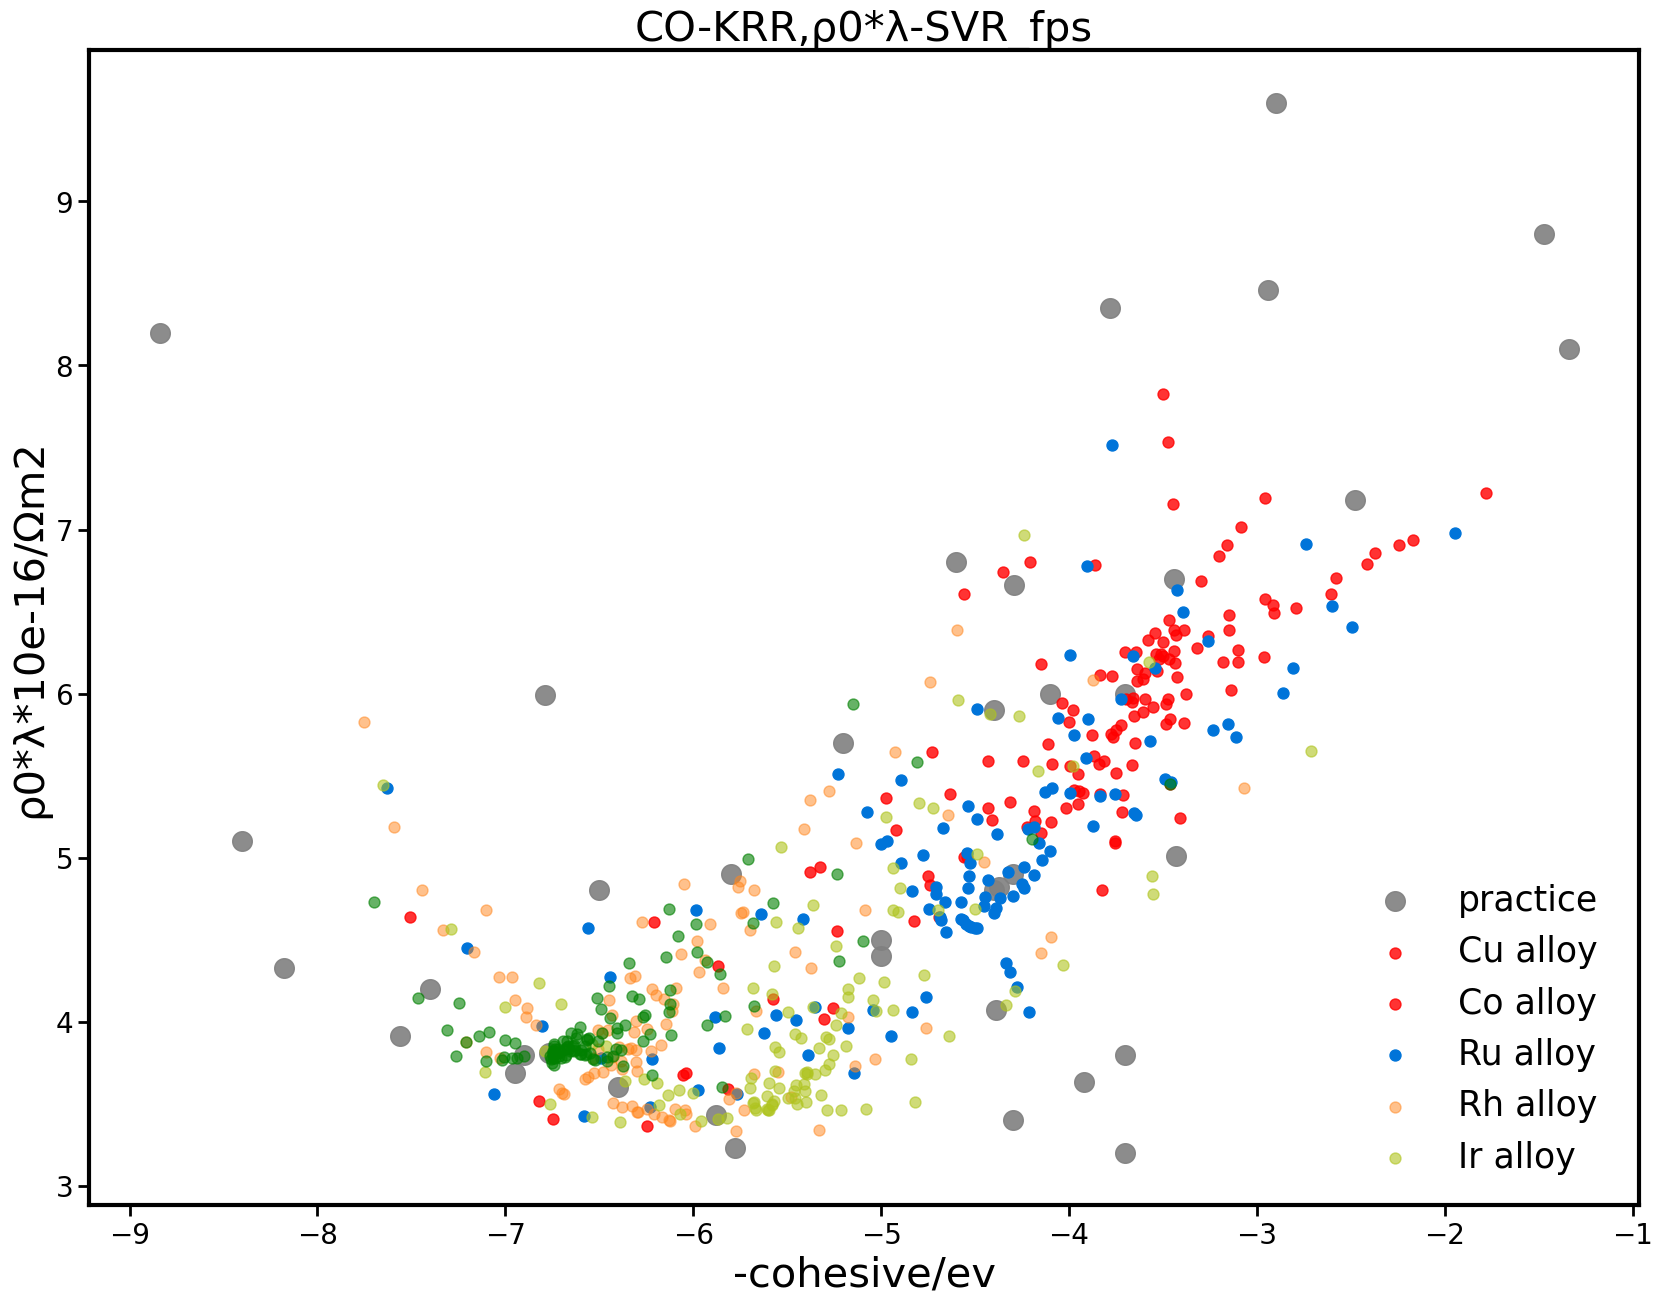

In [11]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RepeatedKFold
from sklearn.feature_selection import SelectKBest
from matplotlib.backend_bases import MouseButton
from scipy.stats import pearsonr
from modules import *
from sklearn.svm import SVR
import pandas as pd
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import modules
from matplotlib.ticker import MultipleLocator

File='../data.4/em-wt-10'
X,y= sub_data(File)
# X=X[:48,:]
# y=y[:48]
X=X[:38,:]
y=y[:38]

y=y.reshape(-1, 1)   # 将 y 的一维数组转换成2维数组
X=np.delete(X,[0,1,2,3,4,5,6],axis= 1)
x_values=X.copy()
y_values=y.copy()

df3 = pd.read_csv('pKRR-1.csv')
x_values2 = pd.read_csv('pKRR-1.csv').iloc[:, 0] 
df4 = pd.read_csv('pSVR-2.csv')  #krr_fps.3 最远点采样4个特征，4全部特征
y_values2 = pd.read_csv('pSVR-2.csv').iloc[:, 0]

# 这一块是验证集，也就是大于10的数据，和1.7的那个数据集,预测出来的效果不好
# X6=df3.iloc[38:47]
# y6=df4.iloc[38:47]

# 每一类图的大致数据划分
X1=x_values2.iloc[:135]  # [:134]
X2=x_values2.iloc[135:249]  #[134:249]
X3=x_values2.iloc[249:359]   #[249:360]
X4=x_values2.iloc[359:472]    #[360:472]
X5=x_values2.iloc[472:584]    #[472:582]
# X6=x_values2.iloc[583:]       #[582:]
# print(X6.shape)
y1=y_values2.iloc[:135]
y2=y_values2.iloc[135:249]
y3=y_values2.iloc[249:359]
y4=y_values2.iloc[359:472]
y5=y_values2.iloc[472:584]
# y6=y_values2.iloc[583:]
# print(y6.shape)

# # # 区分每一类中的最优点
# 在每一类中找到内聚能最大的3个点
# largest_1 = X1.iloc[:, 0].nlargest(8)
# largest_2 = X2.iloc[:, 0].nlargest(6)
# largest_3 = X3.iloc[:, 0].nlargest(3)
# largest_4 = X4.iloc[:, 0].nlargest(3)
# # # 区分每一类中的最优点
# # 在每一类中找到电阻最小的3个点
# smallest_1 = y1.iloc[:, 0].nsmallest(6)
# smallest_2 = y2.iloc[:, 0].nsmallest(3)
# smallest_3 = y3.iloc[:, 0].nsmallest(3)
# smallest_4 = y4.iloc[:, 0].nsmallest(3）

plt.figure(figsize=(20,15))
ax = plt.gca()  # 获取当前轴对象
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.spines['top'].set_linewidth(3)
ax.spines['right'].set_linewidth(3)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tick_params(axis='both', which='major', width=2)
plt.tick_params(axis='both', length=8)

plt.scatter(-x_values, y_values,s = 200,c='#808080', alpha=0.9)  # 绘制实验数据点

# plt.scatter(-X6, y6,s = 200,c='blue', alpha=0.8)
plt.scatter(-X1, y1,s = 250,c='r', marker='.', alpha=0.8)  # 绘制 Cu 预测数据点
# plt.scatter(-X6, y6,s = 250,c='r', marker='.', alpha=0.8)  # 绘制 Cu 预测数据点
plt.scatter(-X2, y2,s = 250,c='#0074D9', marker='.', alpha=1.0)  # 绘制 Co 预测数据点
plt.scatter(-X3, y3,s = 250,c='#FF851B', marker='.', alpha=0.5)  # 绘制 Ru 预测数据点
plt.scatter(-X4, y4,s = 250,c='#AFC41F', marker='.', alpha=0.6)  # 绘制预 Rh测数据点
plt.scatter(-X5, y5,s = 250,c='green', marker='.', alpha=0.6)    # 绘制预 IR测数据点
# plt.scatter(-3.6, 1.7,s = 200,c='black', alpha=0.9)  # 绘制实验数据点
#0074D9#FF851B#AFC41F

#筛选比较好的点的范围和标记坐标
# selected_data = pd.DataFrame({'X': x_values2, 'Y': y_values2})
# selected_data = selected_data[(selected_data['X']> 6) & (selected_data['Y'] < 4.0)] #此处可以进行调整
# selected_data.to_csv('selected_data_6-4.csv', index=True)
# print("selected data:",selected_data)



ax = plt.gca()  # 获取当前轴对象
print(ax.get_xlim())  # 获取x轴范围
print(ax.get_ylim())  # 获取y轴范围

#获取大图的坐标范围
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# 设置图表标题和坐标轴标签
plt.title('CO-KRR,ρ0*λ-SVR_fps',fontsize=30)
plt.xlabel('-cohesive/eV',fontsize=30)
plt.ylabel('ρ0*λ*10e-16/Ωm2',fontsize=30)
plt.legend(['practice','Cu alloy','Co alloy','Ru alloy','Rh alloy ','Ir alloy'],loc=0,fontsize=25,frameon=False)
# plt.axvline(x=-6.0, color='black', linestyle='--',linewidth= 2.5)  
# plt.axhline(y=4.0, color='black', linestyle='--',linewidth= 2.5) 
plt.savefig('CO-KRR,SVR_fps.png', dpi=300, bbox_inches='tight')
plt.show()


# 批量画图 ， 但是已知点的标注存在问题
import matplotlib.pyplot as plt

def plot_scatter1(x, y, title='Cu-Double target forecasting', color='r', xlabel='-cohesive/eV', ylabel='ρ0*λ*10e-16/Ωm^2', alpha='0.3',xlim=None, ylim=None):
    plt.figure(figsize=(12, 10),dpi= 300)
    ax = plt.gca()
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['top'].set_linewidth(2)
    ax.spines['right'].set_linewidth(2)

    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.tick_params(axis='both', which='major', width=2)
    plt.tick_params(axis='both', length=8)

    plt.title(title, fontsize=25)
    plt.xlabel(xlabel, fontsize=25)
    plt.ylabel(ylabel, fontsize=25)

    plt.scatter(x, y, s=200, c=color, marker='.', alpha=alpha)

    # 设置小图的坐标范围与大图相同
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    plt.show()

# plot_scatter1(-x_values, y_values,title='train scatter',color='#808080', alpha=0.9)  # 绘制实验数据点
# plot_scatter1(-X1, y1,title='Cu-Double target forecasting', color='r',  alpha=0.8)  # 绘制 Cu 预测数据点
# plot_scatter1(-X2, y2,title='Co-Double target forecasting',color='#0074D9',  alpha=1.0)  # 绘制 Co 预测数据点
# plot_scatter1(-X3, y3,title= 'Ru-Double target forecasting',color='#FF851B',  alpha=0.5)  # 绘制 Ru 预测数据点
# plot_scatter1(-X4, y4,title='Rh-Double target forecasting' ,color='#AFC41F',  alpha=0.5)  # 绘制预 Ir 测数据点
# plot_scatter1(-X5, y5,title='Ir-Double target forecasting' ,color='green',  alpha=0.5)  # 绘制预 Ir 测数据点

# 小图中标明每个的单独的元素

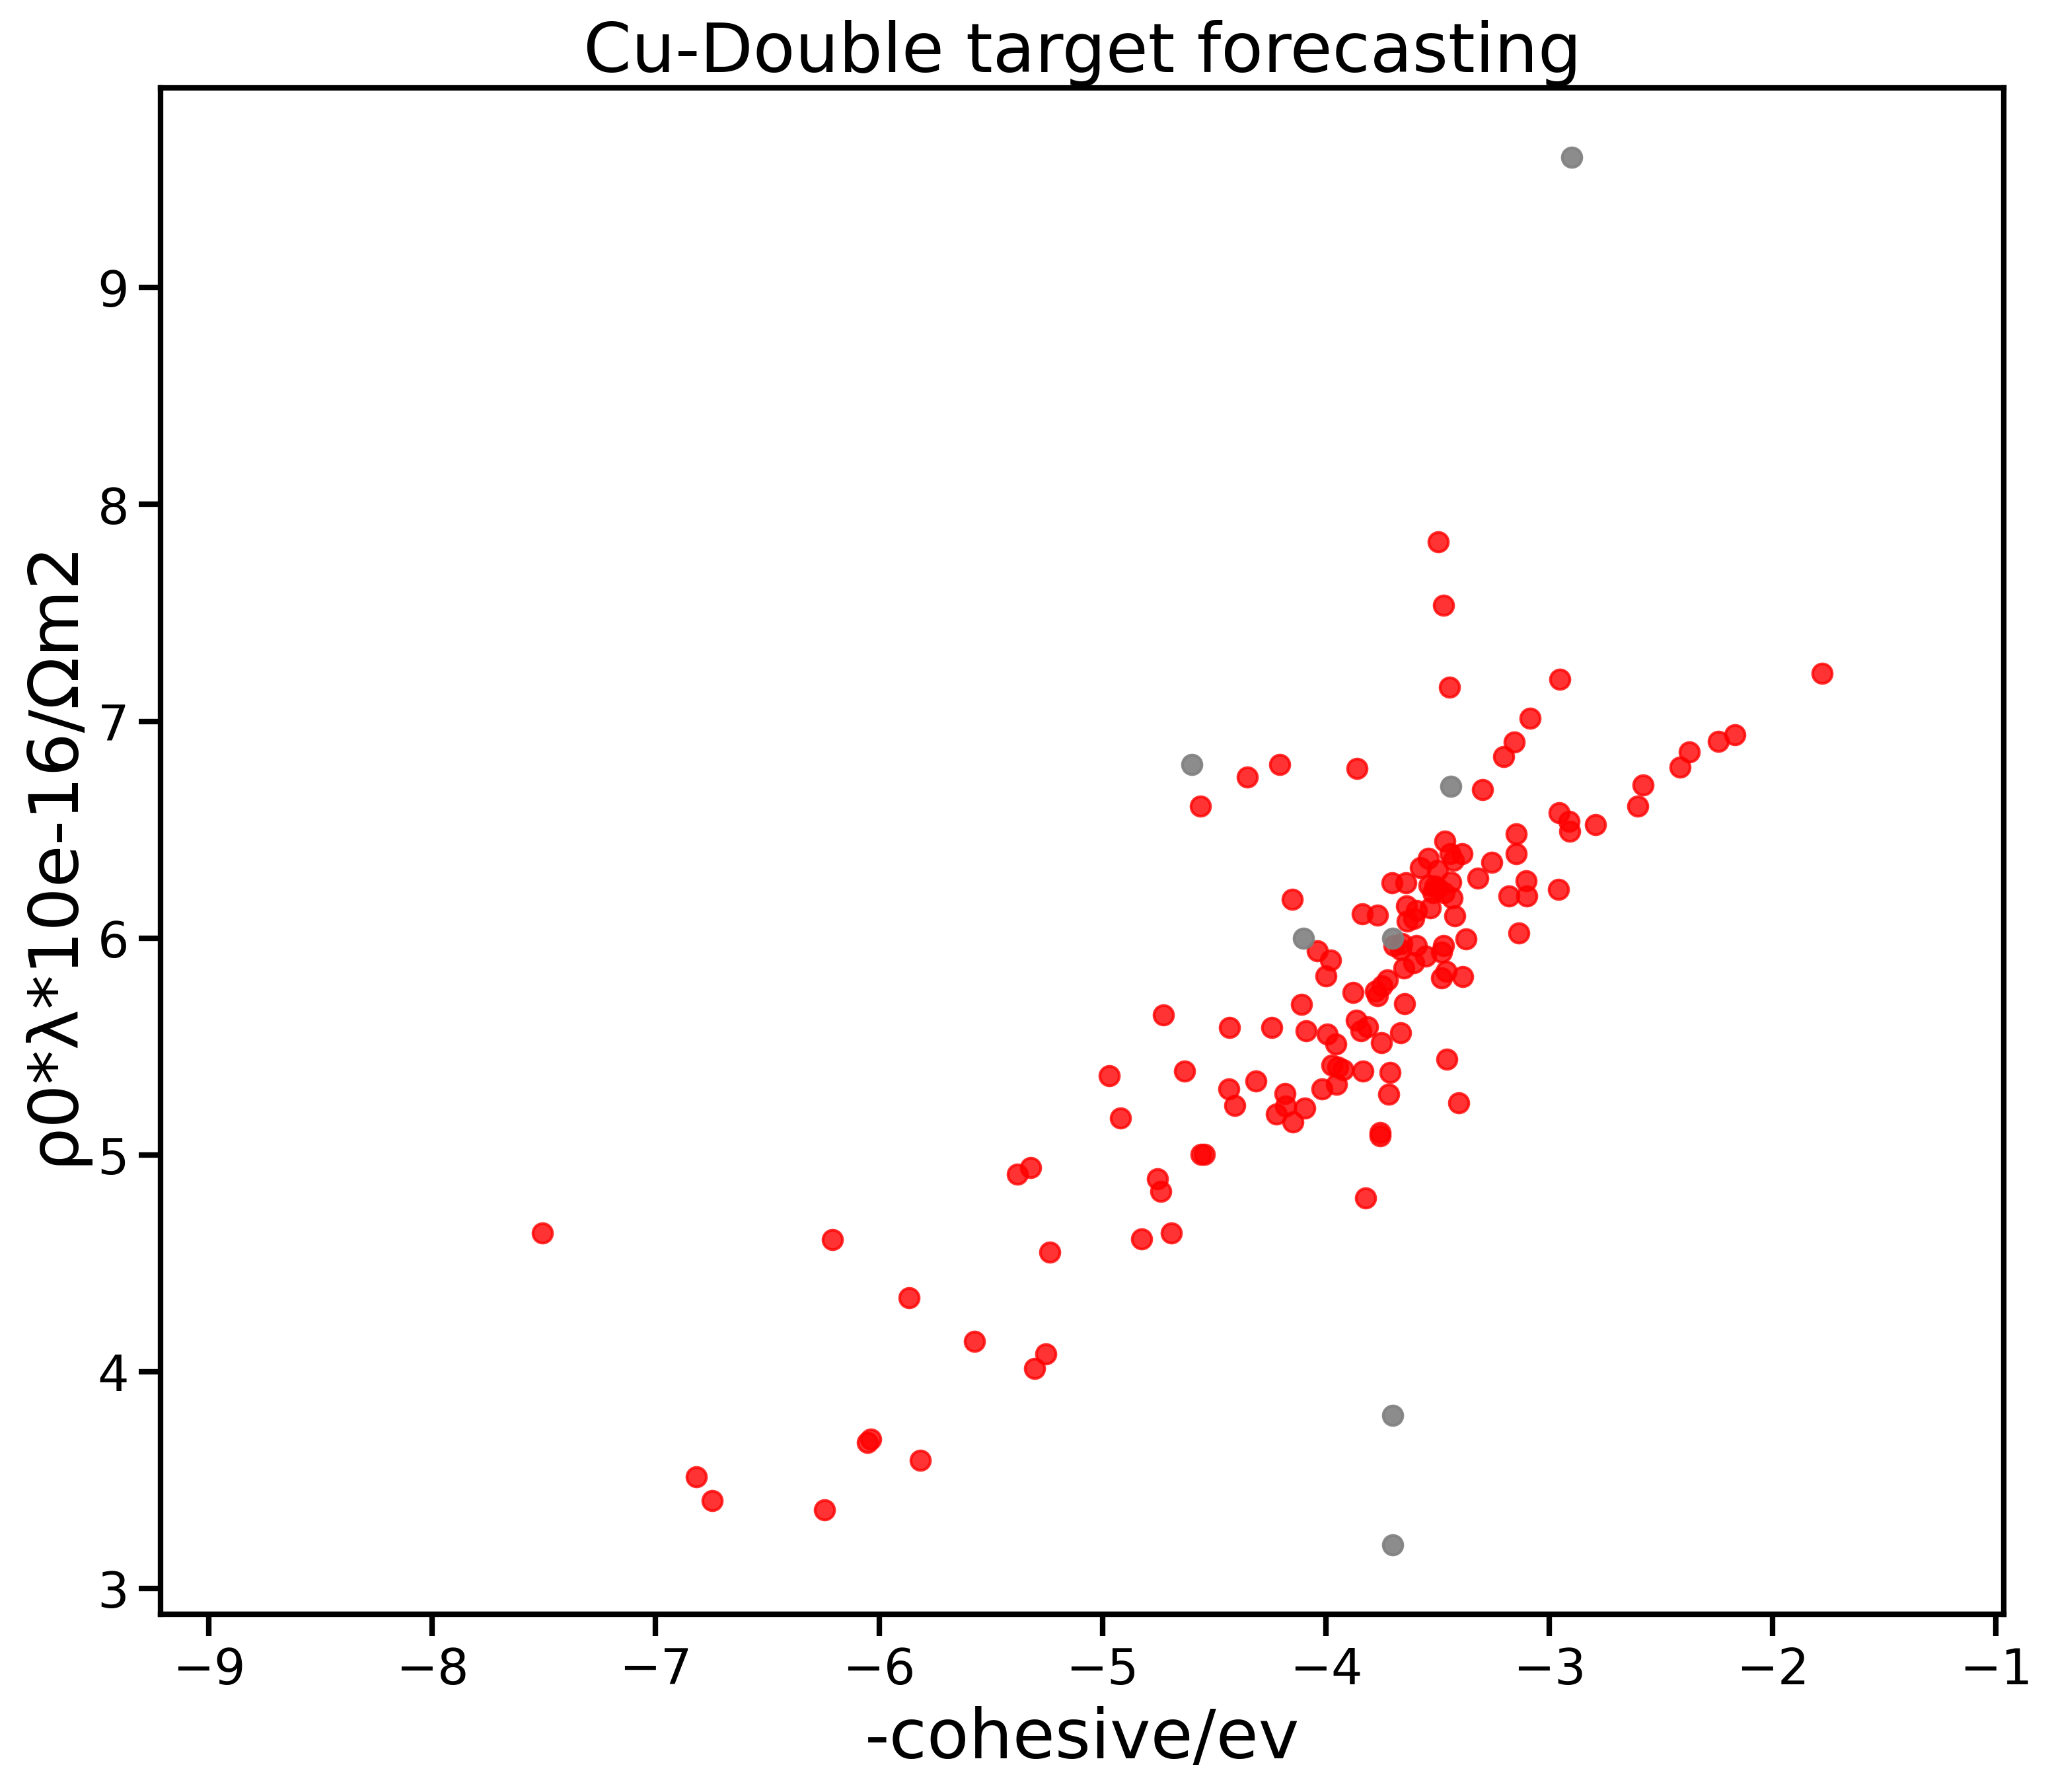

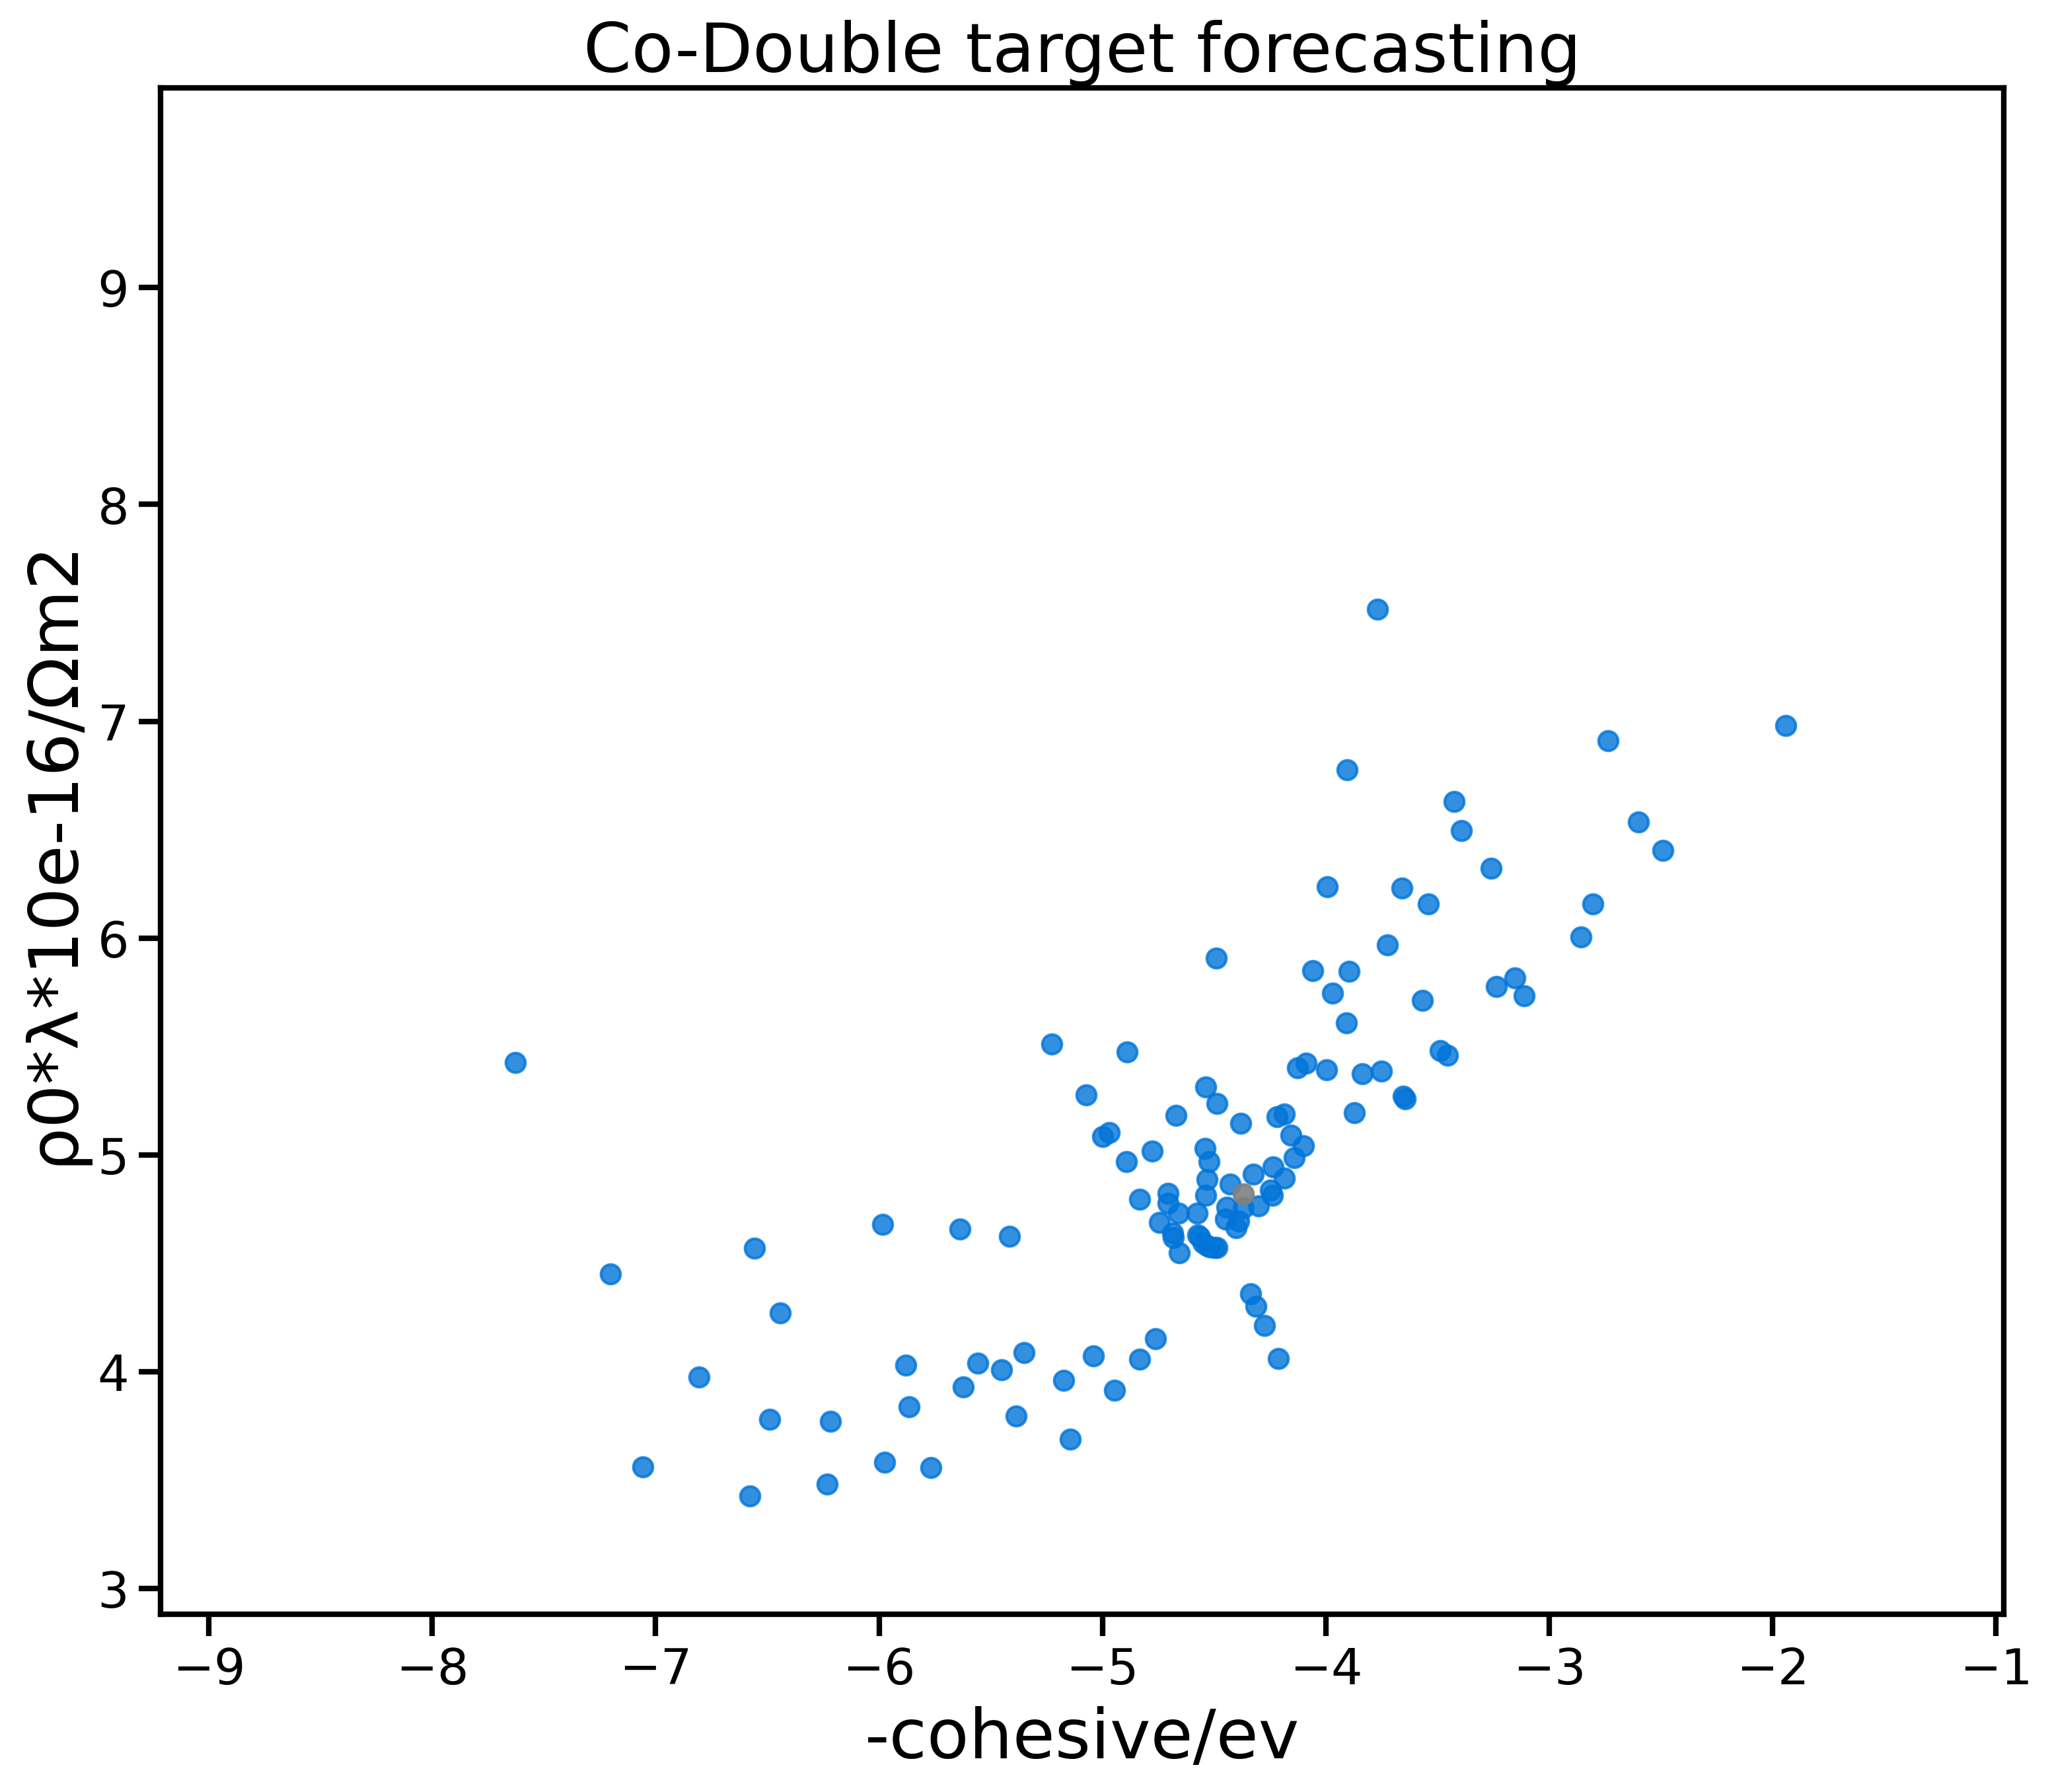

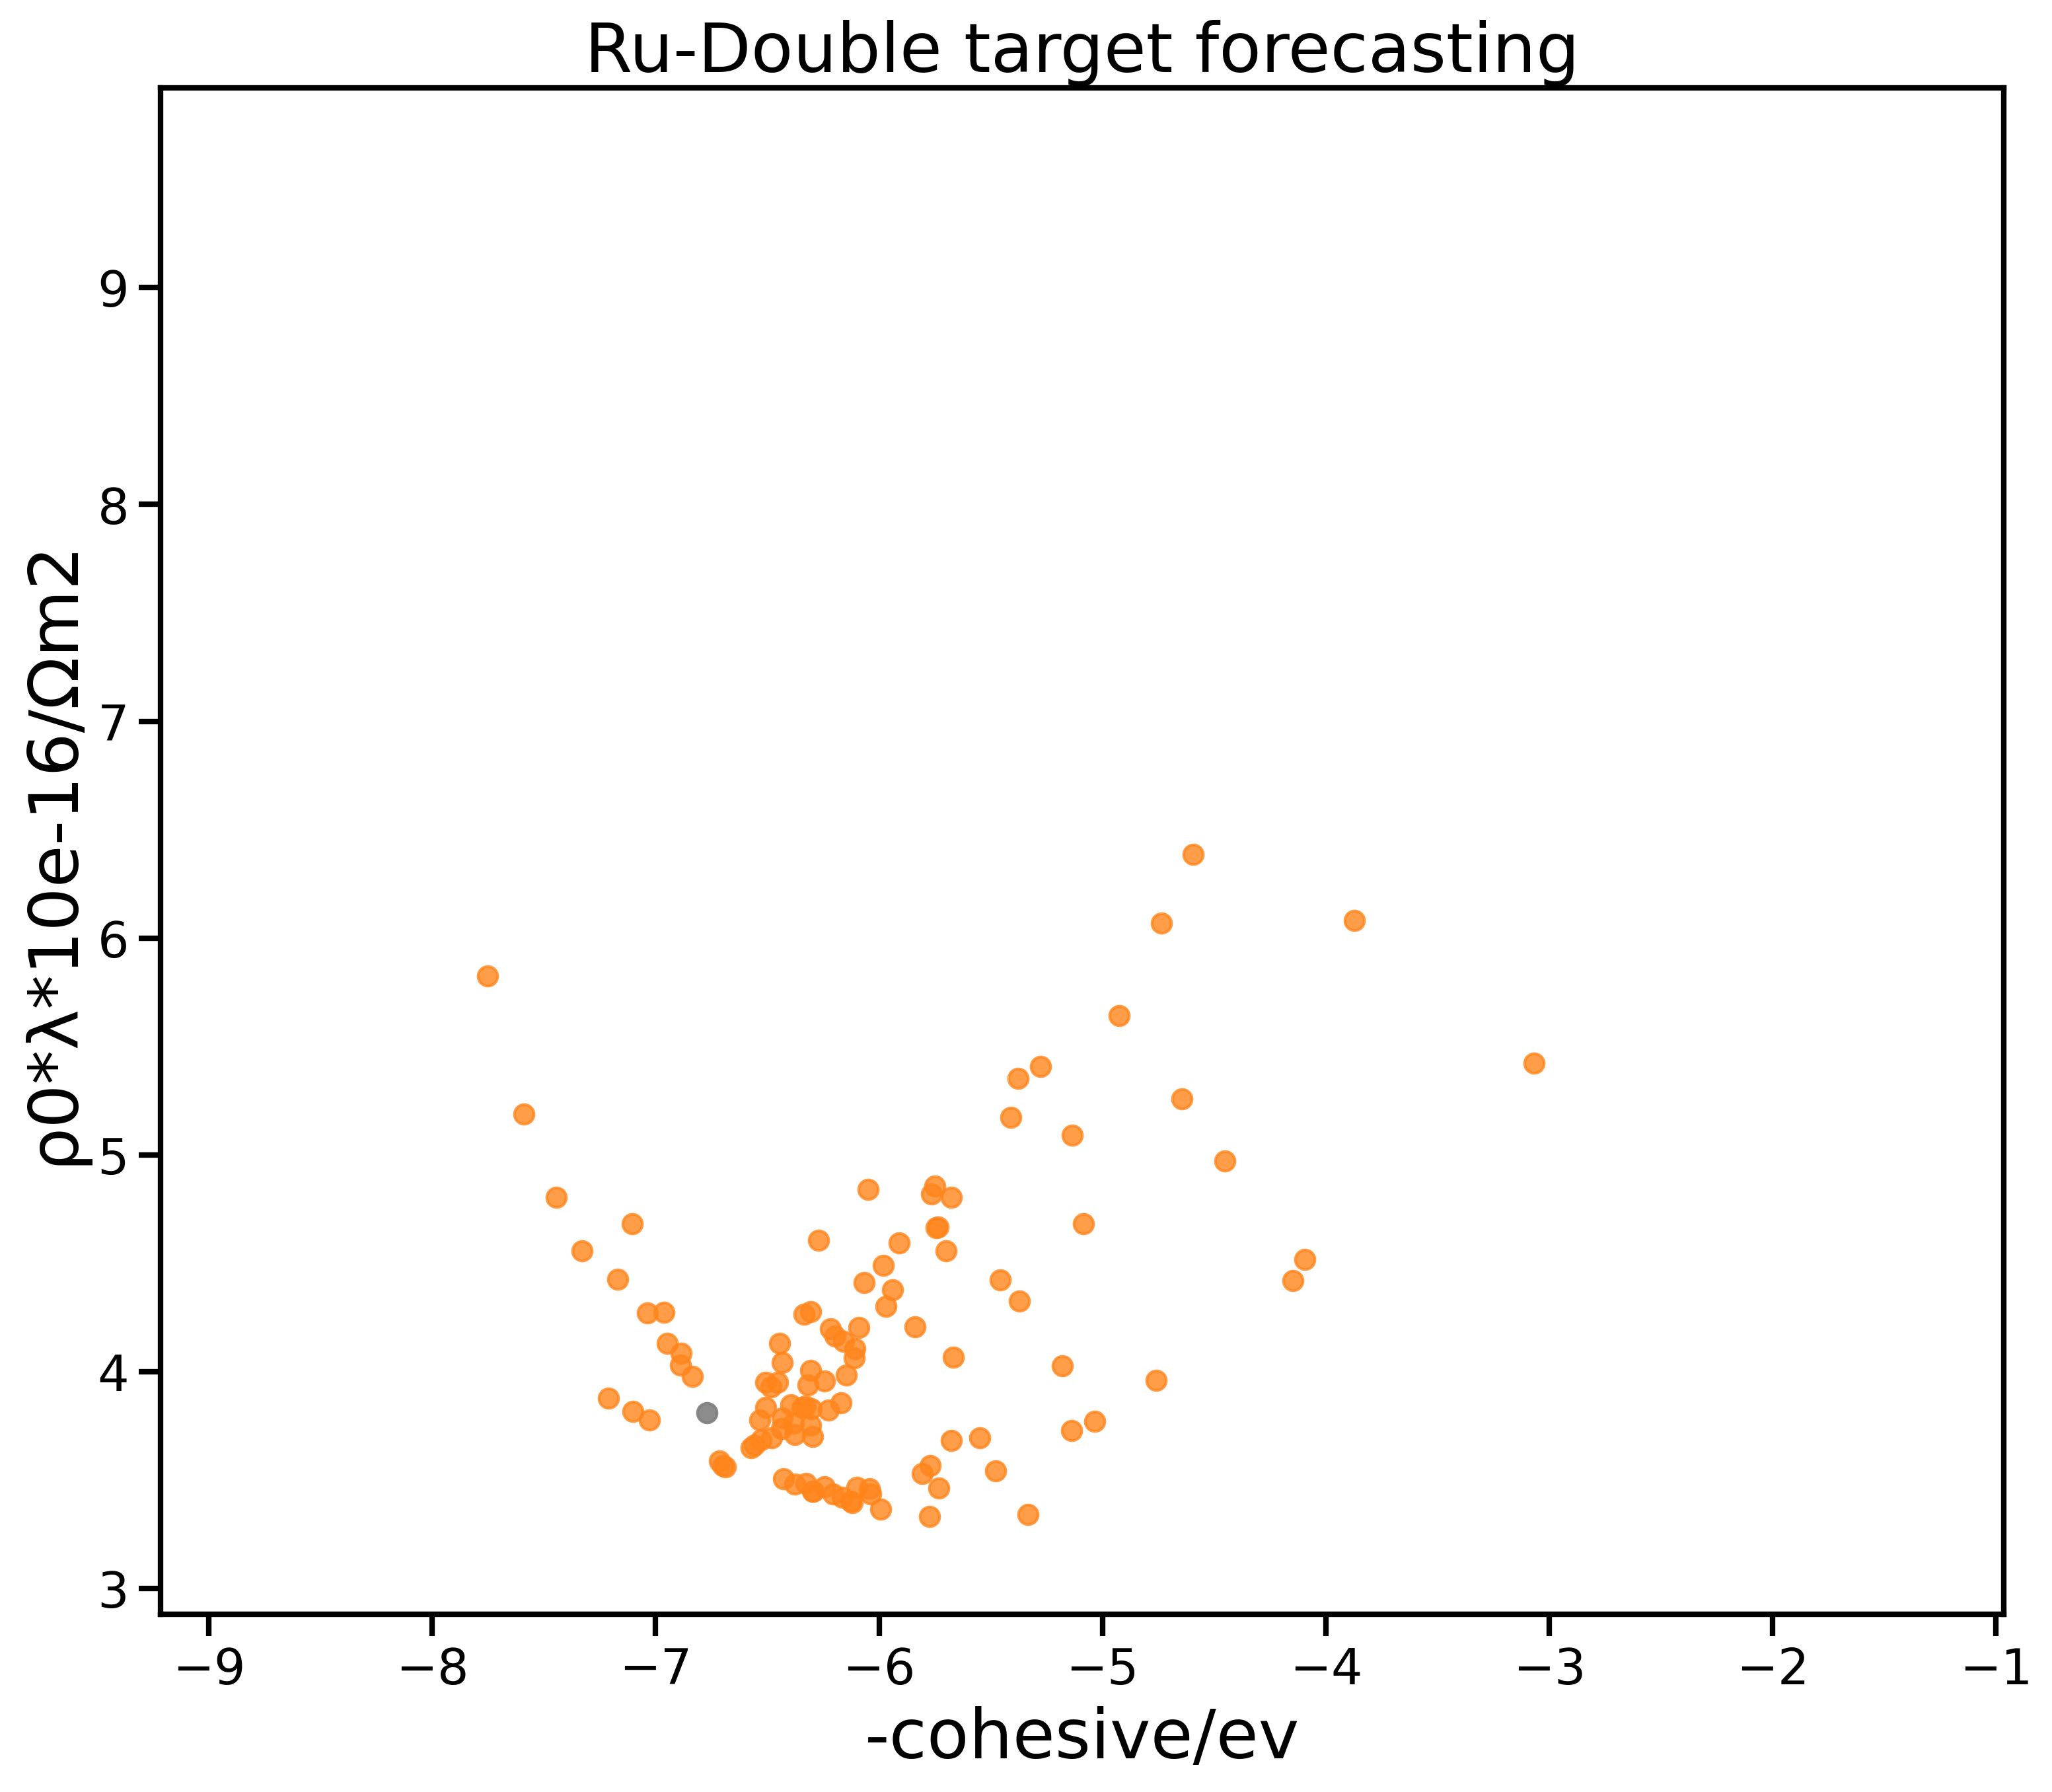

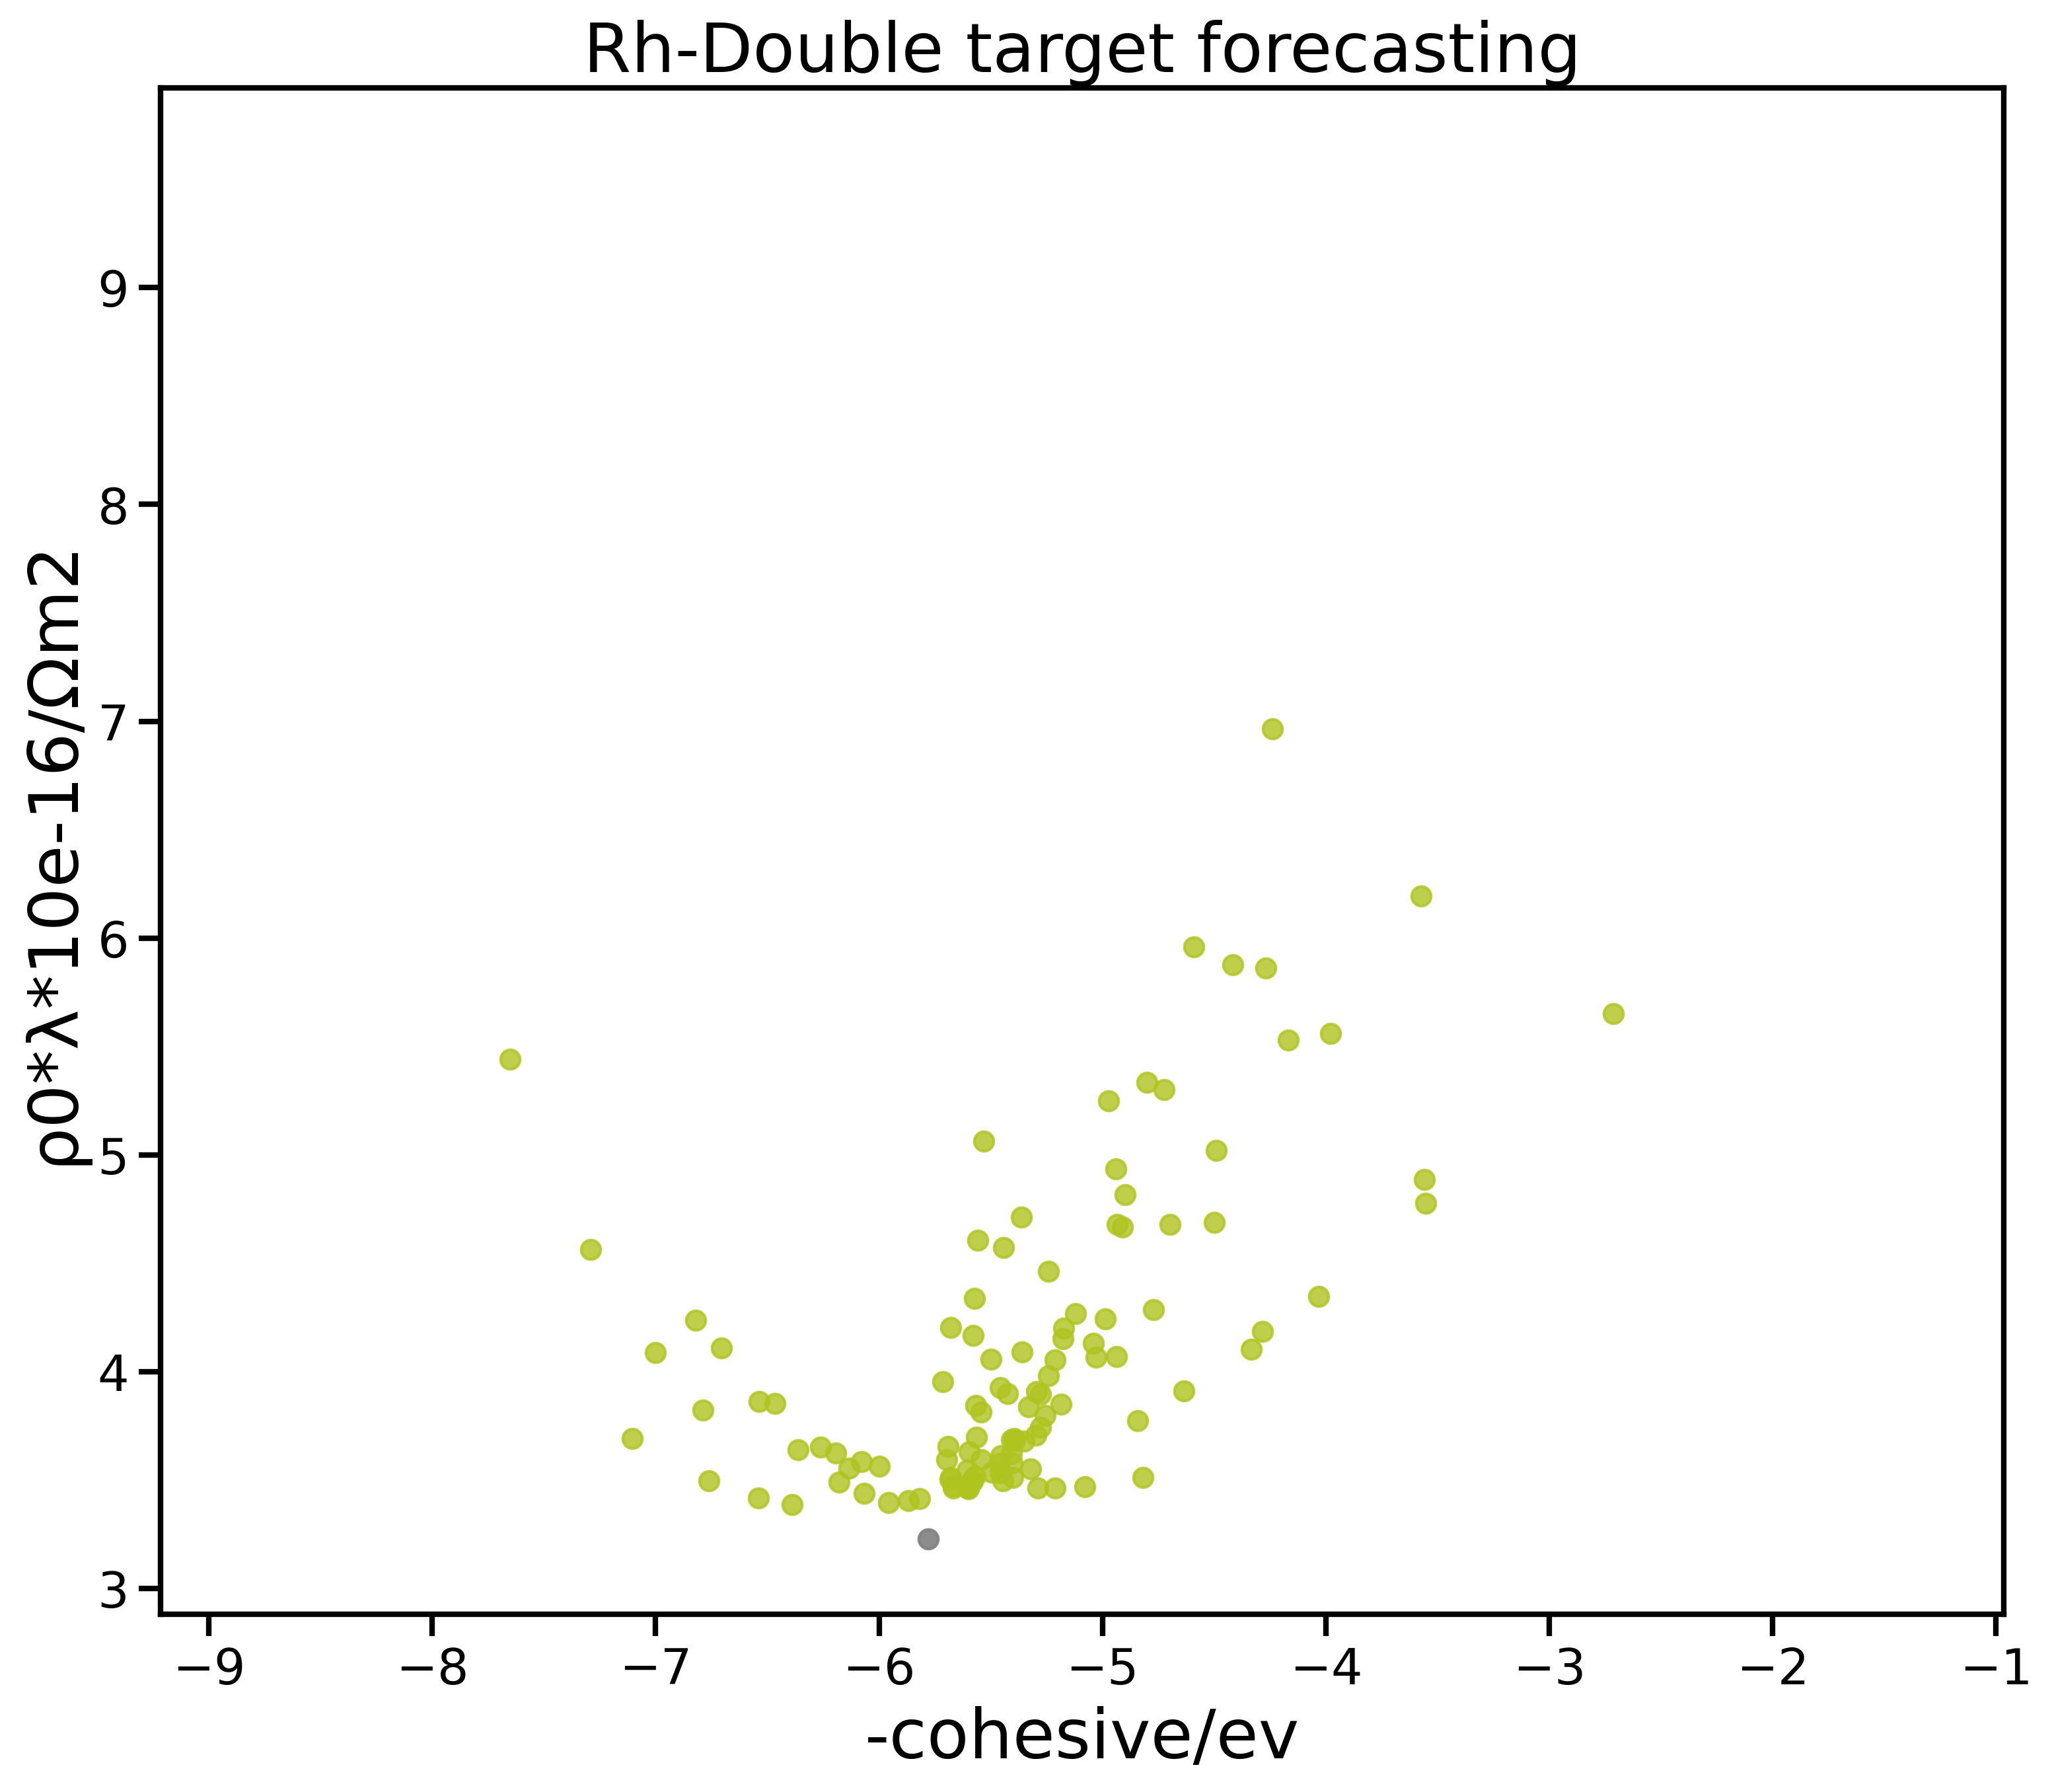

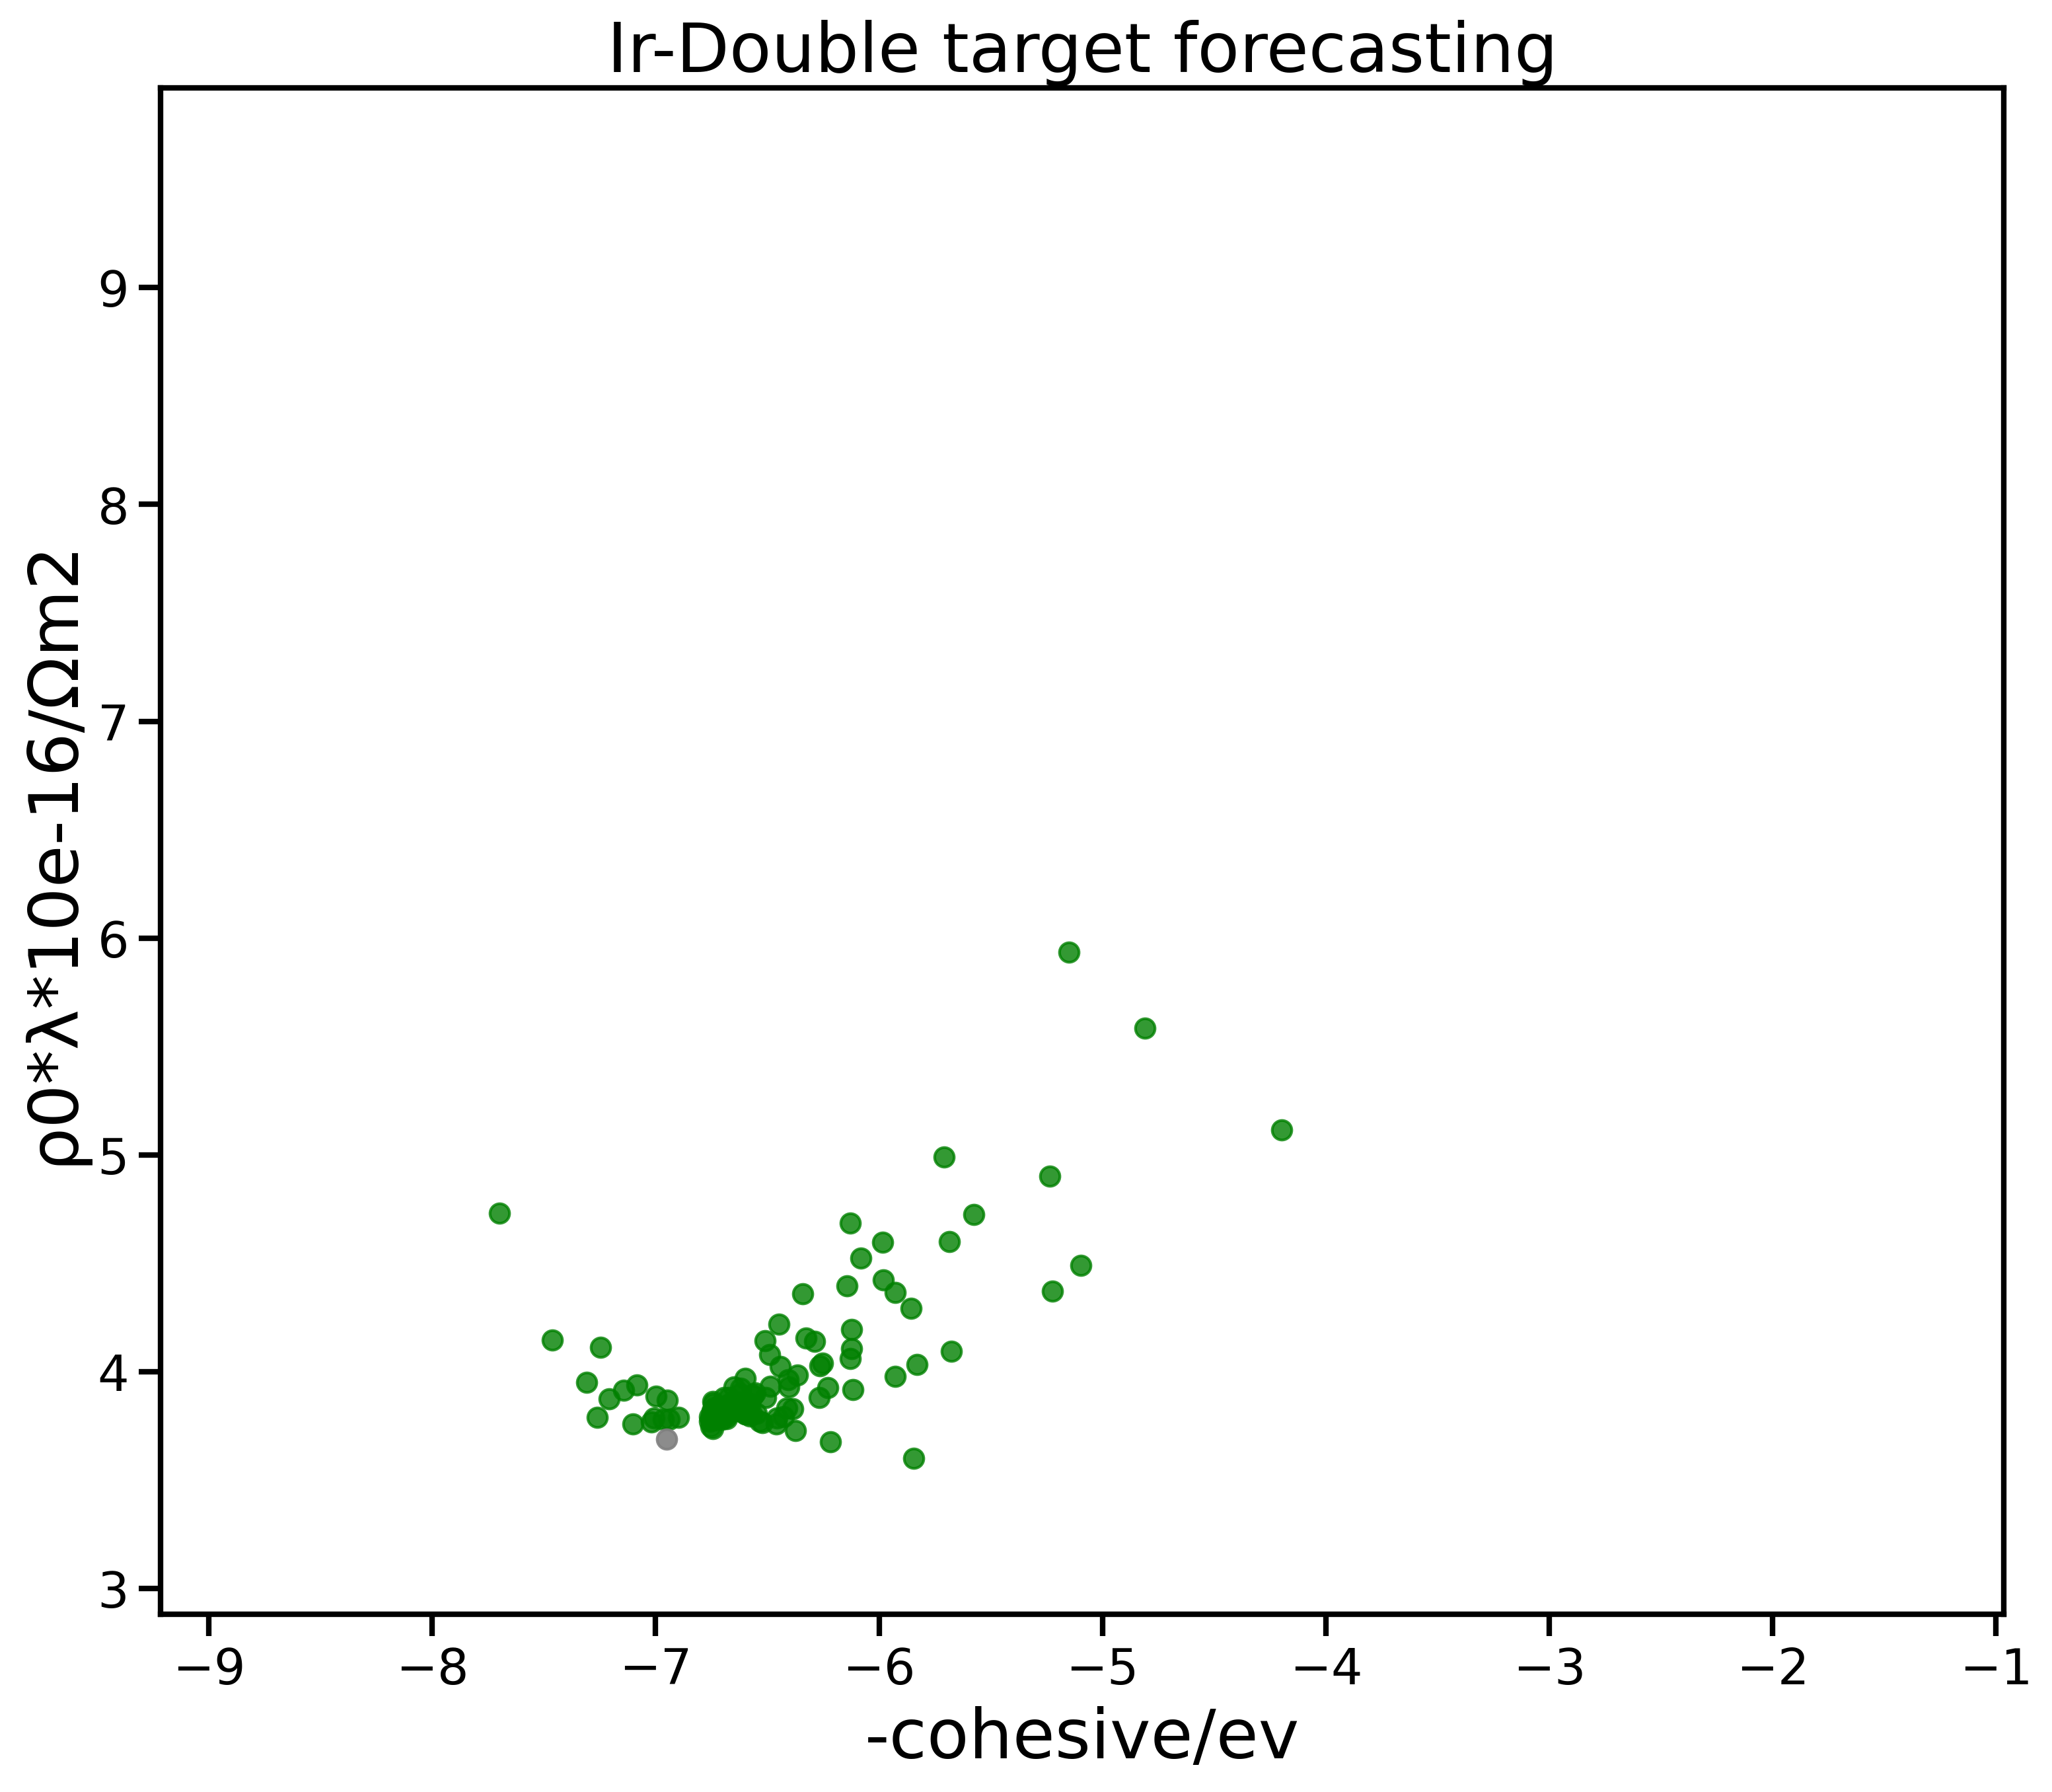

In [18]:
plt.figure(figsize=(12, 10),dpi= 300)
ax = plt.gca()
# 设置小图的坐标范围与大图相同
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tick_params(axis='both', which='major', width=2)
plt.tick_params(axis='both', length=8)
plt.scatter(-X1, y1, s=200, c='r', marker='.', alpha=0.8)
plt.scatter(-3.46, 5.44, s=200, c='r', marker='.', alpha=0.8)  #CuMn
# X7=[3.44,2.9,4.6,4.1,3.7,3.7,3.7]  #Cu  Cu2Mg CuPt AlCu t-Cu2Al3 c-CuAl2 c2-Cu3Al
# y7=[6.7,9.6,6.8,6,6,3.8,3.2]
# plt.scatter(-X7,y7,s=200,c='#808080',marker='.',alpha=0.9) 
plt.scatter(-3.44,6.7,s=200,c='#808080',marker='.',alpha=0.9)   # Cu
plt.scatter(-2.9,9.6,s=200,c='#808080',marker='.',alpha=0.9)  #Cu2Mg
plt.scatter(-4.6,6.8,s=200,c='#808080',marker='.',alpha=0.9)   # CuPt 
plt.scatter(-4.1,6,s=200,c='#808080',marker='.',alpha=0.9)     #AlCu
plt.scatter(-3.7,6,s=200,c='#808080',marker='.',alpha=0.9)     # t-Cu2Al3
plt.scatter(-3.7,3.8,s=200,c='#808080',marker='.',alpha=0.9)     #c-CuAl2
plt.scatter(-3.7,3.2,s=200,c='#808080',marker='.',alpha=0.9)     #c2-Cu3Al
plt.title('Cu-Double target forecasting',fontsize=25)
plt.xlabel('-cohesive/eV',fontsize=25)
plt.ylabel('ρ0*λ*10e-16/Ωm2',fontsize=25)
plt.show()

plt.figure(figsize=(12, 10),dpi= 300)
ax = plt.gca()
# 设置小图的坐标范围与大图相同
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tick_params(axis='both', which='major', width=2)
plt.tick_params(axis='both', length=8)
plt.scatter(-X2, y2, s=200, c='#0074D9', marker='.', alpha=0.8)
plt.scatter(-4.37,4.82,s=200,c='#808080',marker='.',alpha=0.9)
plt.title('Co-Double target forecasting',fontsize=25)
plt.xlabel('-cohesive/eV',fontsize=25)
plt.ylabel('ρ0*λ*10e-16/Ωm2',fontsize=25)
plt.show()

plt.figure(figsize=(12, 10),dpi= 300)
ax = plt.gca()
# 设置小图的坐标范围与大图相同
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tick_params(axis='both', which='major', width=2)
plt.tick_params(axis='both', length=8)
plt.scatter(-X3, y3, s=200, c='#FF851B', marker='.', alpha=0.8)
plt.scatter(-6.77,3.81,s=200,c='#808080',marker='.',alpha=0.9)
plt.title('Ru-Double target forecasting',fontsize=25)
plt.xlabel('-cohesive/eV',fontsize=25)
plt.ylabel('ρ0*λ*10e-16/Ωm2',fontsize=25)
plt.show()

plt.figure(figsize=(12, 10),dpi= 300)
ax = plt.gca()
# 设置小图的坐标范围与大图相同
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tick_params(axis='both', which='major', width=2)
plt.tick_params(axis='both', length=8)
plt.scatter(-X4, y4, s=200, c='#AFC41F', marker='.', alpha=0.8)
plt.scatter(-5.78,3.23,s=200,c='#808080',marker='.',alpha=0.9)
plt.title('Rh-Double target forecasting',fontsize=25)
plt.xlabel('-cohesive/eV',fontsize=25)
plt.ylabel('ρ0*λ*10e-16/Ωm2',fontsize=25)
plt.show()

plt.figure(figsize=(12, 10),dpi= 300)
ax = plt.gca()
# 设置小图的坐标范围与大图相同
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tick_params(axis='both', which='major', width=2)
plt.tick_params(axis='both', length=8)
plt.scatter(-X5, y5, s=200, c='green', marker='.', alpha=0.8)
plt.scatter(-6.95,3.69,s=200,c='#808080',marker='.',alpha=0.9)
plt.title('Ir-Double target forecasting',fontsize=25)
plt.xlabel('-cohesive/eV',fontsize=25)
plt.ylabel('ρ0*λ*10e-16/Ωm2',fontsize=25)
plt.show()

# 配色2.0

(-9.215, -0.9650000000000001)
(2.8800000000000003, 9.92)


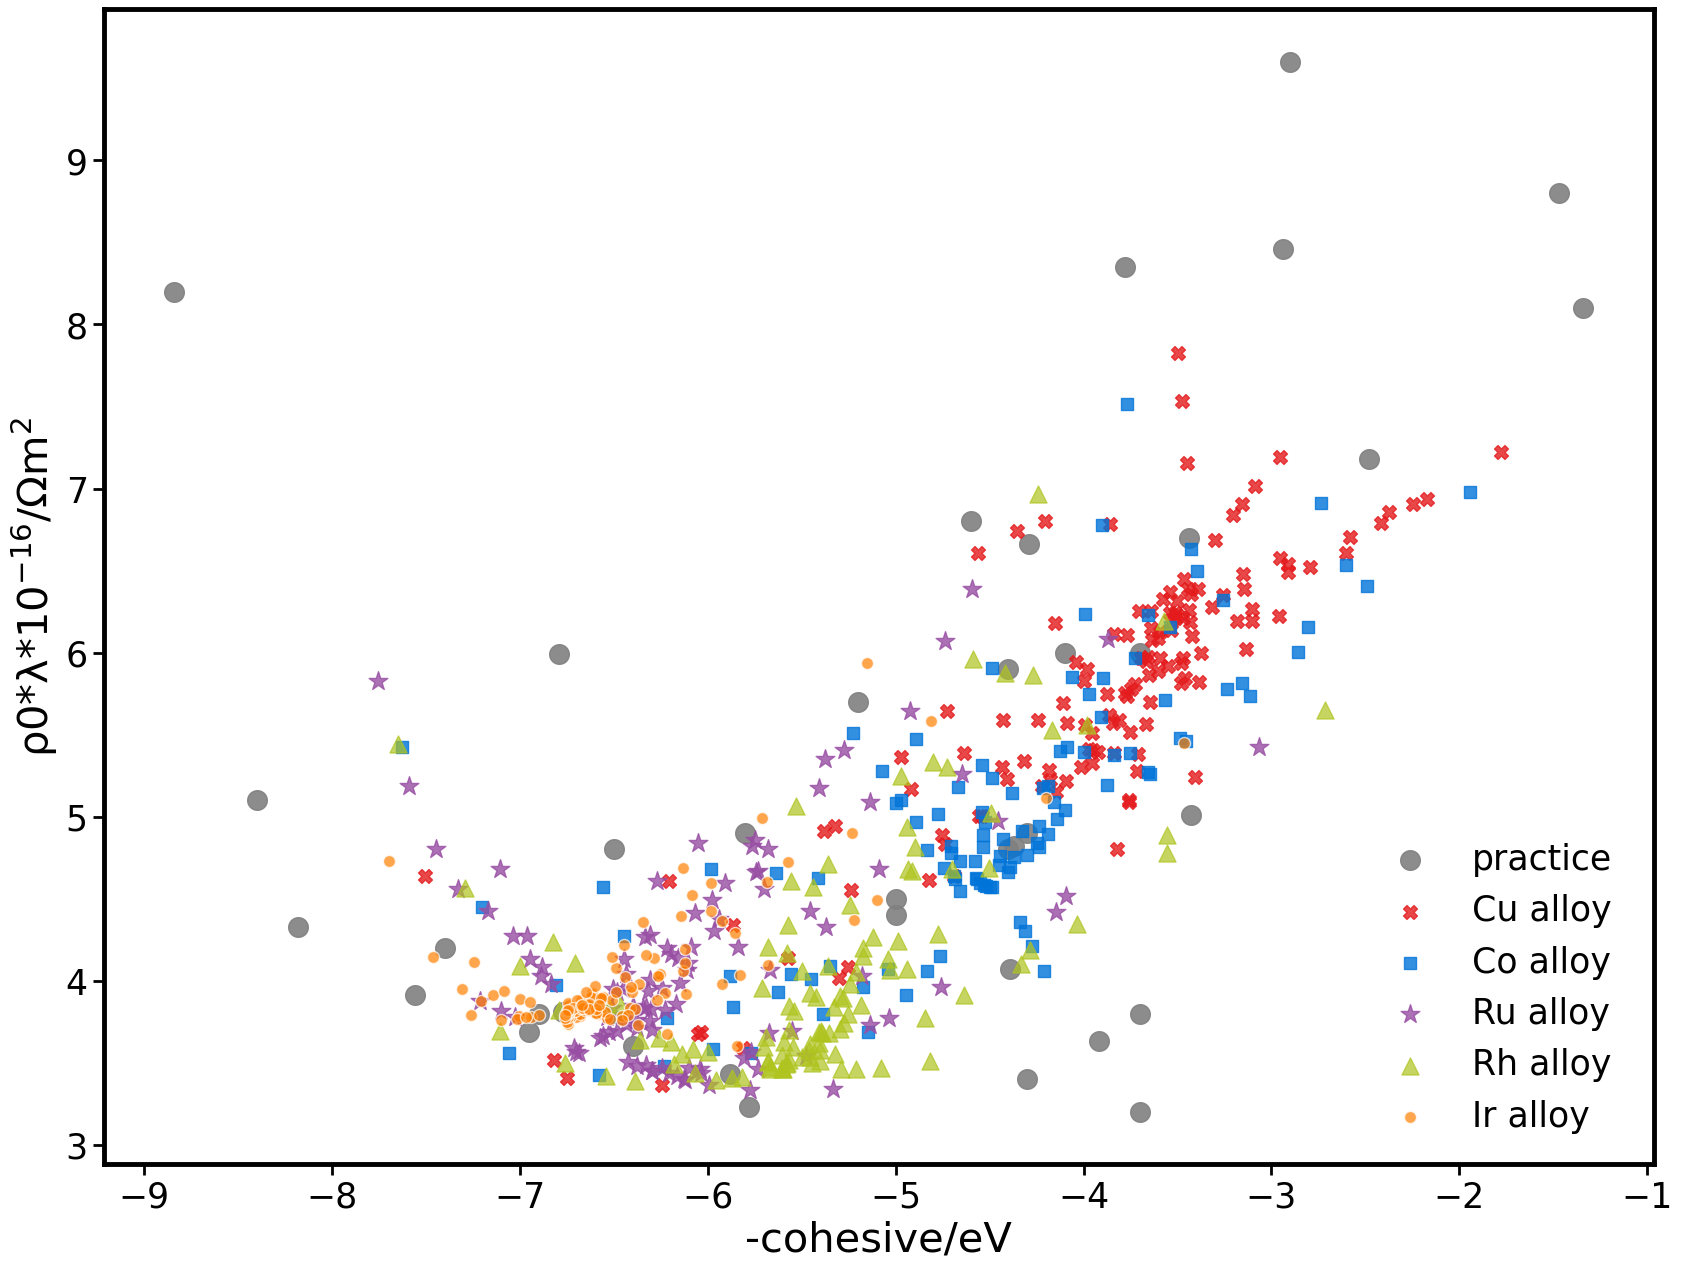

In [21]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RepeatedKFold
from sklearn.feature_selection import SelectKBest
from matplotlib.backend_bases import MouseButton
from scipy.stats import pearsonr
from modules import *
from sklearn.svm import SVR
import pandas as pd
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import modules
from matplotlib.ticker import MultipleLocator

File='../data.4/em-wt-10'
X,y= sub_data(File)
# X=X[:48,:]
# y=y[:48]
X=X[:38,:]
y=y[:38]
y=y.reshape(-1, 1)   # 将 y 的一维数组转换成2维数组
X=np.delete(X,[0,1,2,3,4,5,6],axis= 1)
x_values=X.copy()
y_values=y.copy() 
df3 = pd.read_csv('pKRR-1.csv')
x_values2 = pd.read_csv('pKRR-1.csv').iloc[:, 0] 
df4 = pd.read_csv('pSVR-2.csv')  #krr_fps.3 最远点采样4个特征，4全部特征
y_values2 = pd.read_csv('pSVR-2.csv').iloc[:, 0]

# 每一类图的大致数据划分
X1=x_values2.iloc[:135]  # [:134]
X2=x_values2.iloc[135:249]  #[134:249]
X3=x_values2.iloc[249:359]   #[249:360]
X4=x_values2.iloc[359:472]    #[360:472]
X5=x_values2.iloc[472:584]    #[472:582]
y1=y_values2.iloc[:135]
y2=y_values2.iloc[135:249]
y3=y_values2.iloc[249:359]
y4=y_values2.iloc[359:472]
y5=y_values2.iloc[472:584]


plt.figure(figsize=(20,15))
ax = plt.gca()  # 获取当前轴对象
ax.spines['bottom'].set_linewidth(3.5)
ax.spines['left'].set_linewidth(3.5)
ax.spines['top'].set_linewidth(3.5)
ax.spines['right'].set_linewidth(3.5)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.tick_params(axis='both', which='major', width=2)
plt.tick_params(axis='both', length=8)

# #配色第二版
# plt.scatter(-x_values, y_values,s = 200,c='#808080', alpha=0.9)  # 绘制实验数据点
# plt.scatter(-X1, y1,s = 100,c='#FFCB5B', marker='X', alpha=0.8)  # 绘制 Cu 预测数据点
# plt.scatter(-X2, y2,s = 80,c='#C5B0D4', marker='s', alpha=0.8)  # 绘制 Co 预测数据点
# plt.scatter(-X3, y3,s = 200,c='#F69C9C', marker='*', alpha=0.9)  # 绘制 Ru 预测数据点 
# plt.scatter(-X4, y4,s = 150,c='#96AEDA', marker='^', alpha=0.6)  # 绘制预 Rh测数据点  4DAF4A LVSE
# plt.scatter(-X5, y5,s = 300, marker='.',edgecolors='white', facecolors='#AFC41F', alpha=0.6)    # 绘制预 IR测数据点  0098B2  湖蓝色   8DC2BA  #A9AB35 c草绿色
# # plt.scatter(-3.6, 1.7,s = 200,c='black', alpha=0.9)  # 绘制实验数据点   6a8ec9  蓝紫色
#D72929

#配色第三版
plt.scatter(-x_values, y_values,s = 200,c='#808080', alpha=0.9)  # 绘制实验数据点
plt.scatter(-X1, y1,s = 100,c='#E41A1C', marker='X', alpha=0.8)  # 绘制 Cu 预测数据点
plt.scatter(-X2, y2,s = 80,c='#0074D9', marker='s', alpha=0.8)  # 绘制 Co 预测数据点
plt.scatter(-X3, y3,s = 200,c='#984EA3', marker='*', alpha=0.8)  # 绘制 Ru 预测数据点 
plt.scatter(-X4, y4,s = 150,c='#AFC41F', marker='^', alpha=0.7)  # 绘制预 Rh测数据点  4DAF4A LVSE
# plt.scatter(-X5, y5,s = 250,c='#FF7F00', marker='.',alpha=0.7)
plt.scatter(-X5, y5,s = 300,marker='.',edgecolors='white', facecolors='#FF7F00',alpha=0.7)    # 绘制预 IR测数据点  0098B2  湖蓝色 6a8ec9
# # plt.scatter(-3.6, 1.7,s = 200,c='black', alpha=0.9)  # 绘制实验数据点   6a8ec9  蓝紫色



ax = plt.gca()  # 获取当前轴对象
print(ax.get_xlim())  # 获取x轴范围
print(ax.get_ylim())  # 获取y轴范围

#获取大图的坐标范围
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# 设置图表标题和坐标轴标签
# plt.title('CO-KRR,ρ0*λ-SVR_fps',fontsize=35)
plt.xlabel('-cohesive/eV',fontsize=30)
plt.ylabel('ρ$_0$×λ×10$^{-16}$/Ωm$^2$',fontsize=30)
plt.legend(['practice','Cu alloy','Co alloy','Ru alloy','Rh alloy ','Ir alloy'],loc=0,fontsize=25,frameon=False)
# plt.axvline(x=-6.0, color='black', linestyle='--',linewidth= 2.5)  
# plt.axhline(y=4.0, color='black', linestyle='--',linewidth= 2.5) 
# plt.savefig('CO-KRR,SVR_fps-2.0.png', dpi=300, bbox_inches='tight')
plt.savefig('CO-KRR,SVR_fps-3.0.png', dpi=300, bbox_inches='tight')
plt.show()




# 小图形状改变第一版

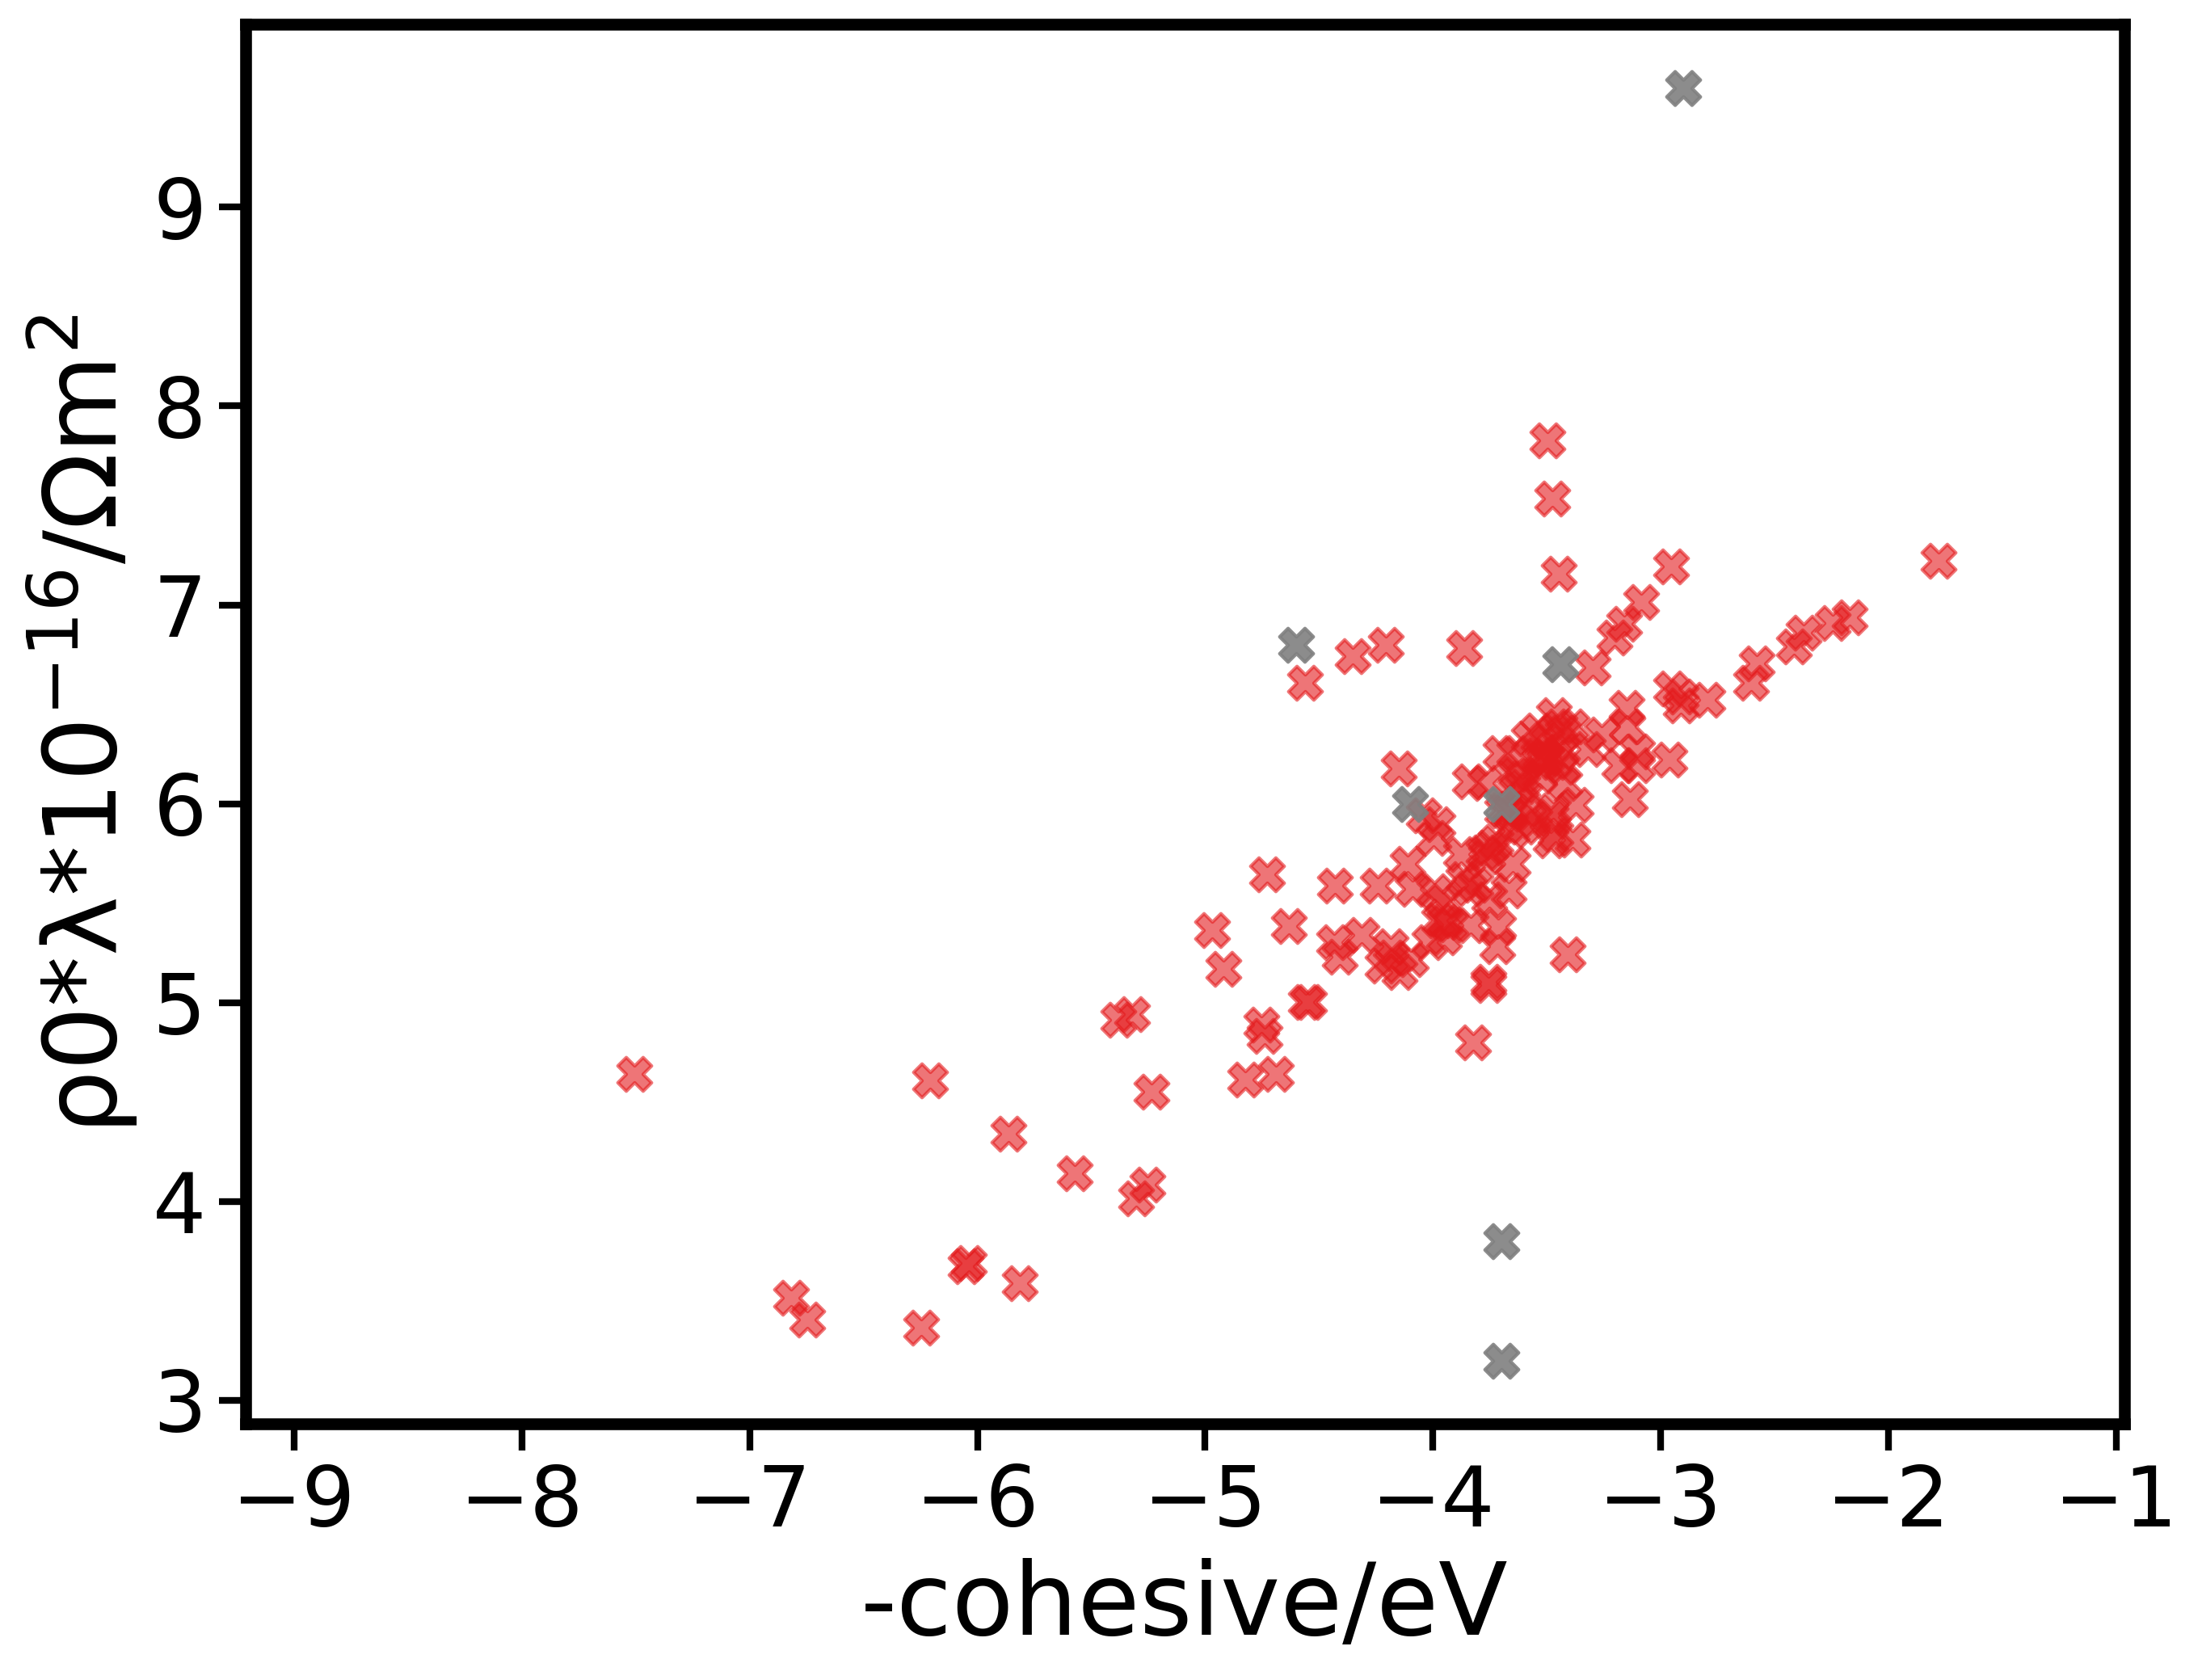

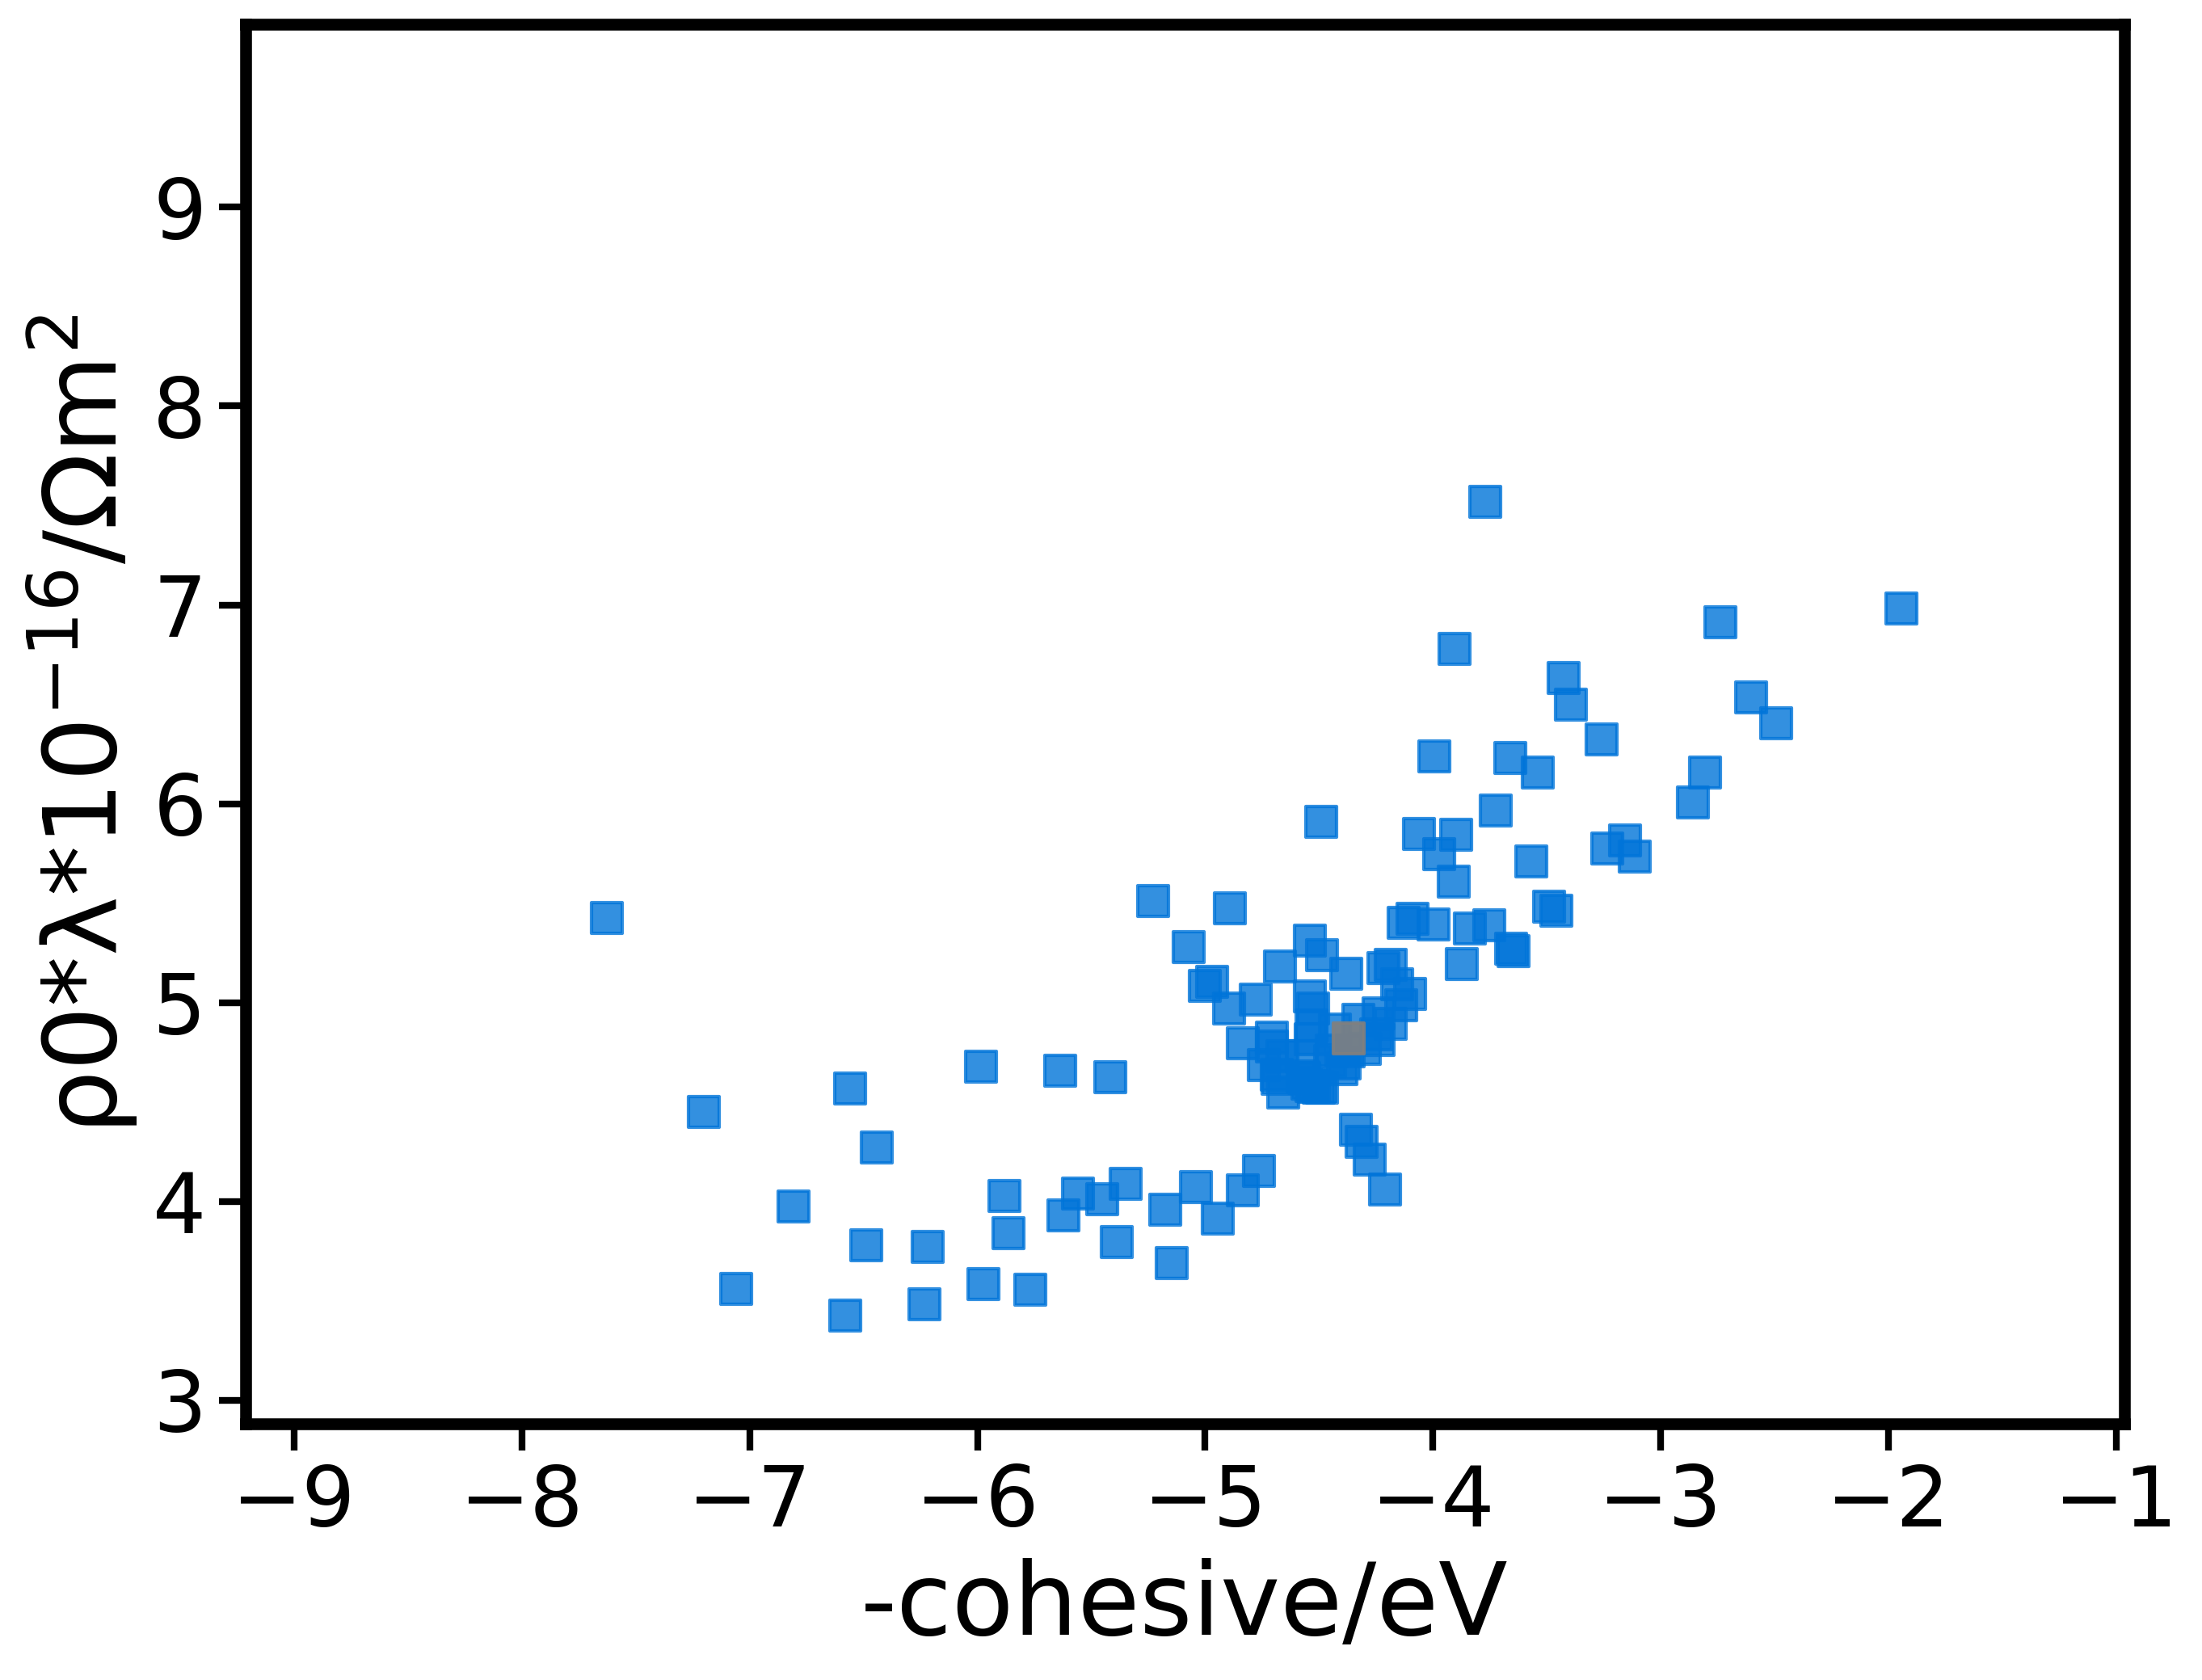

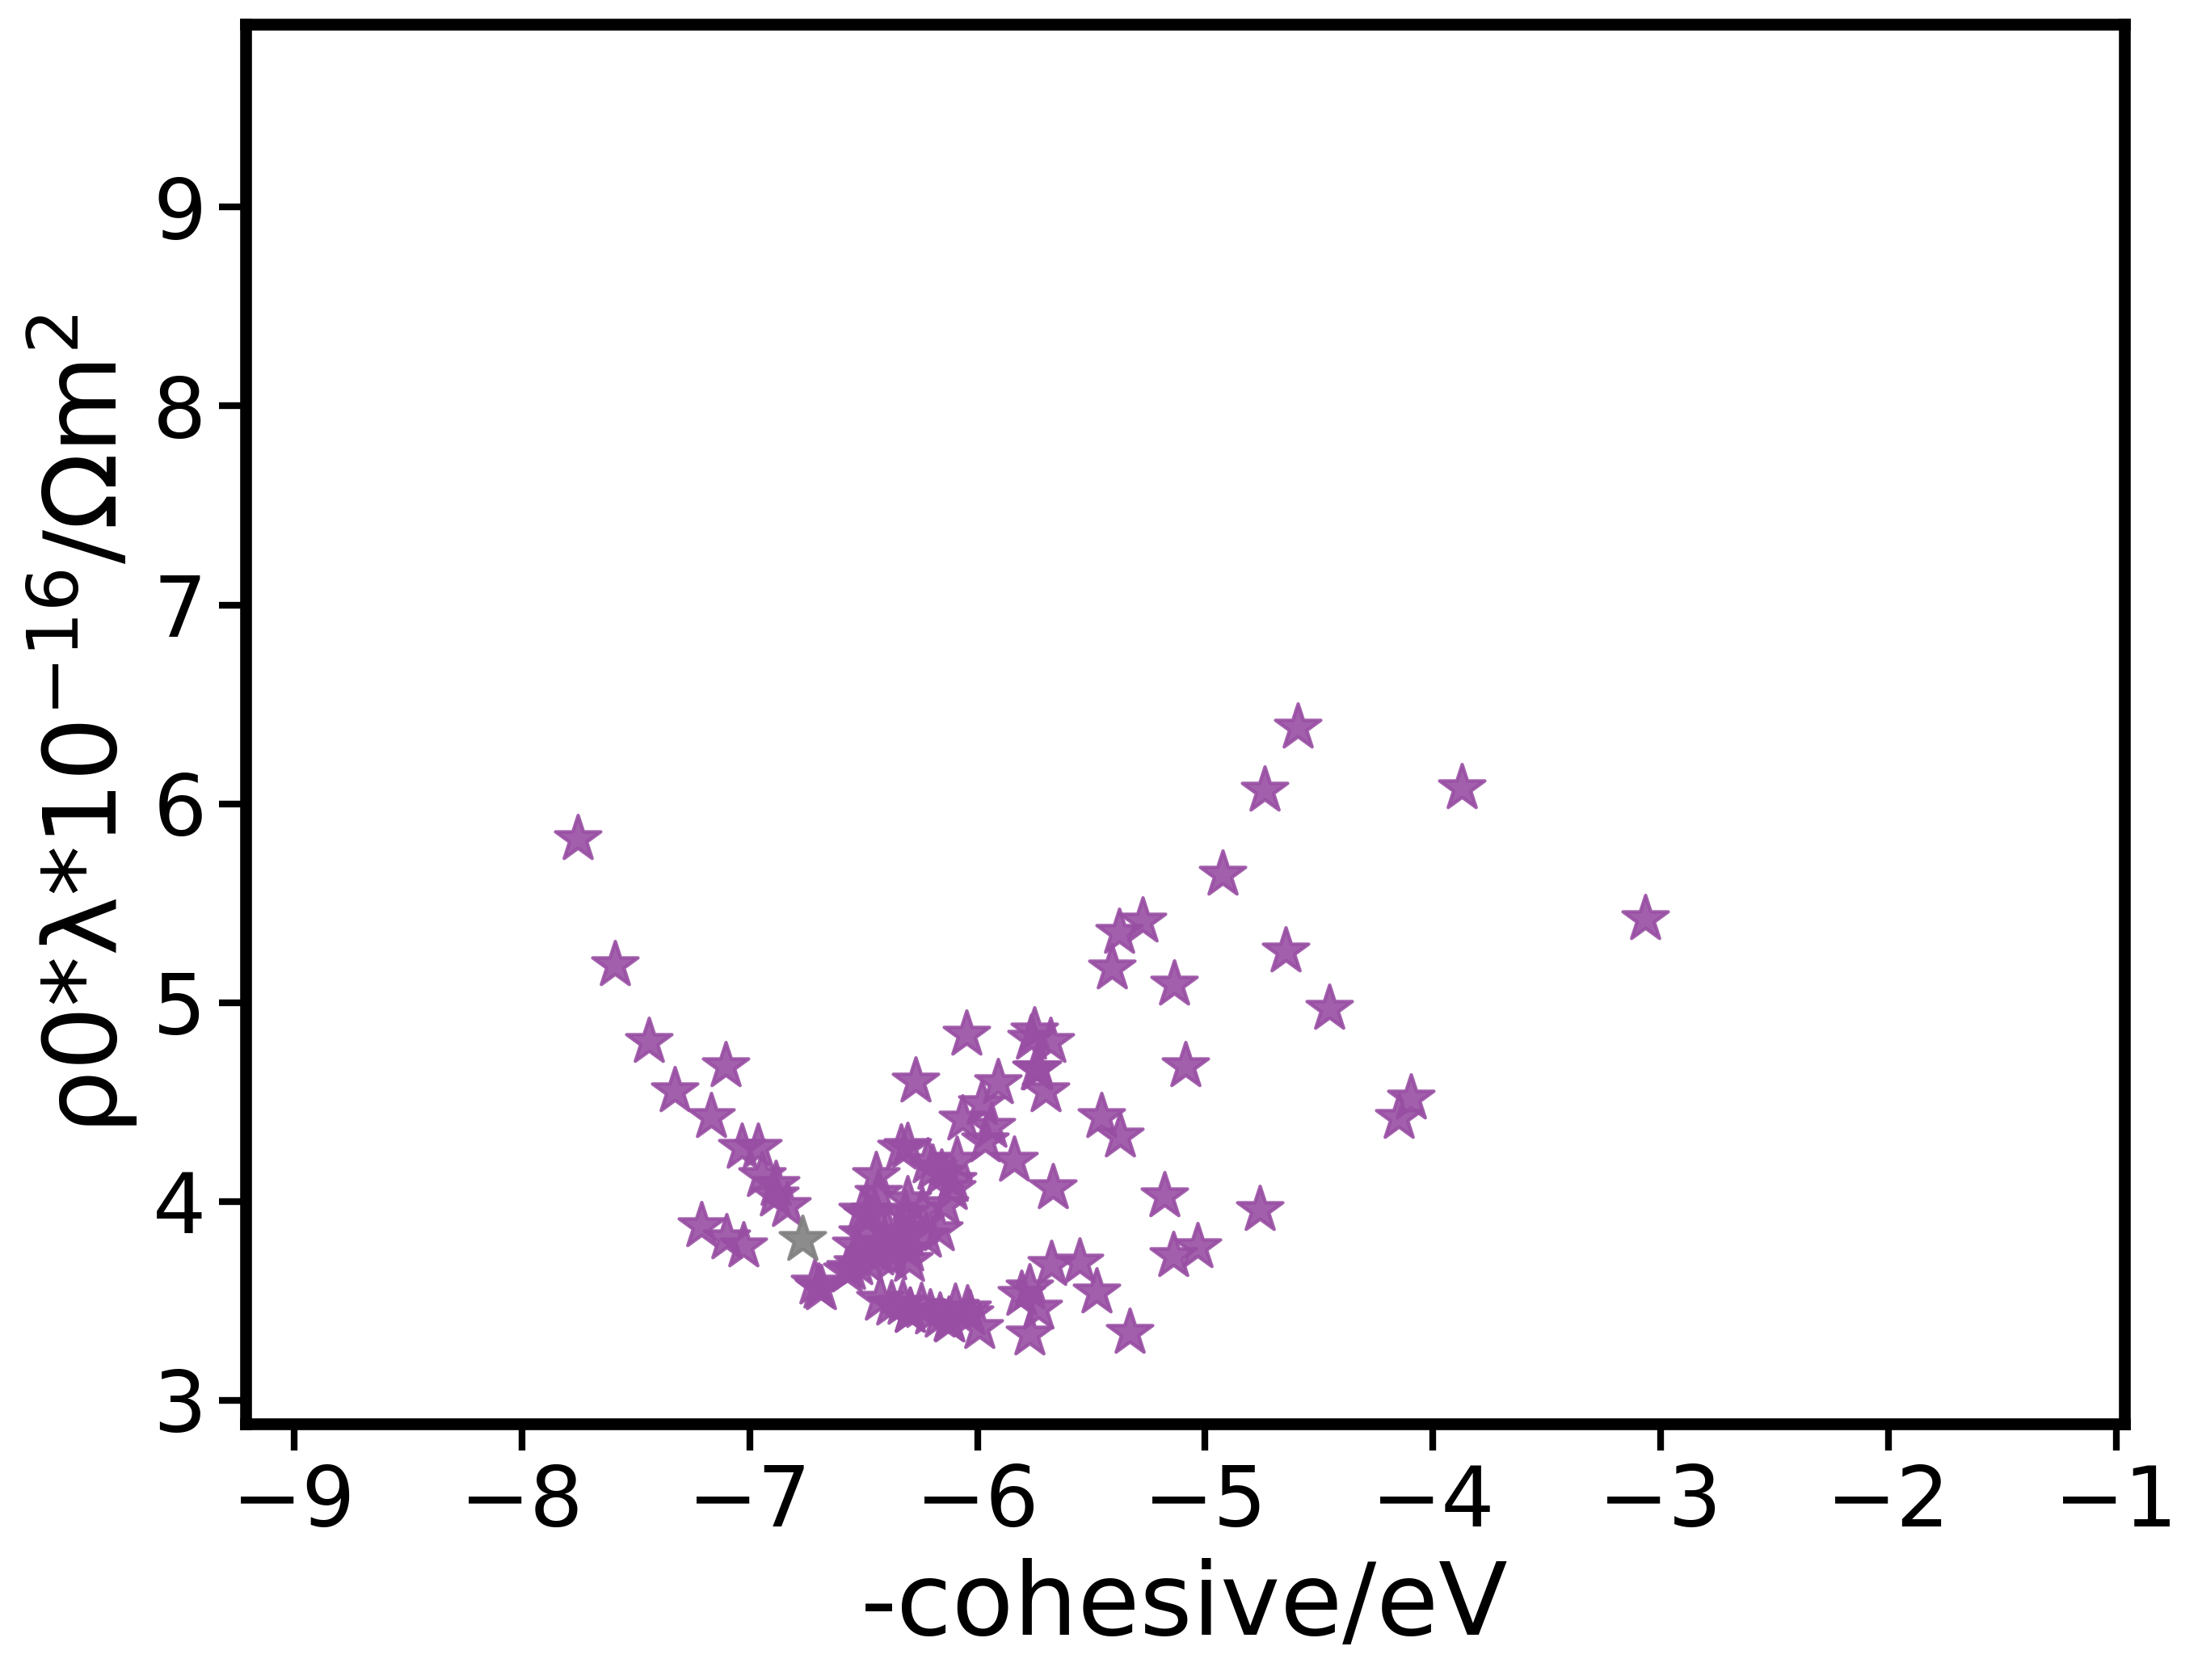

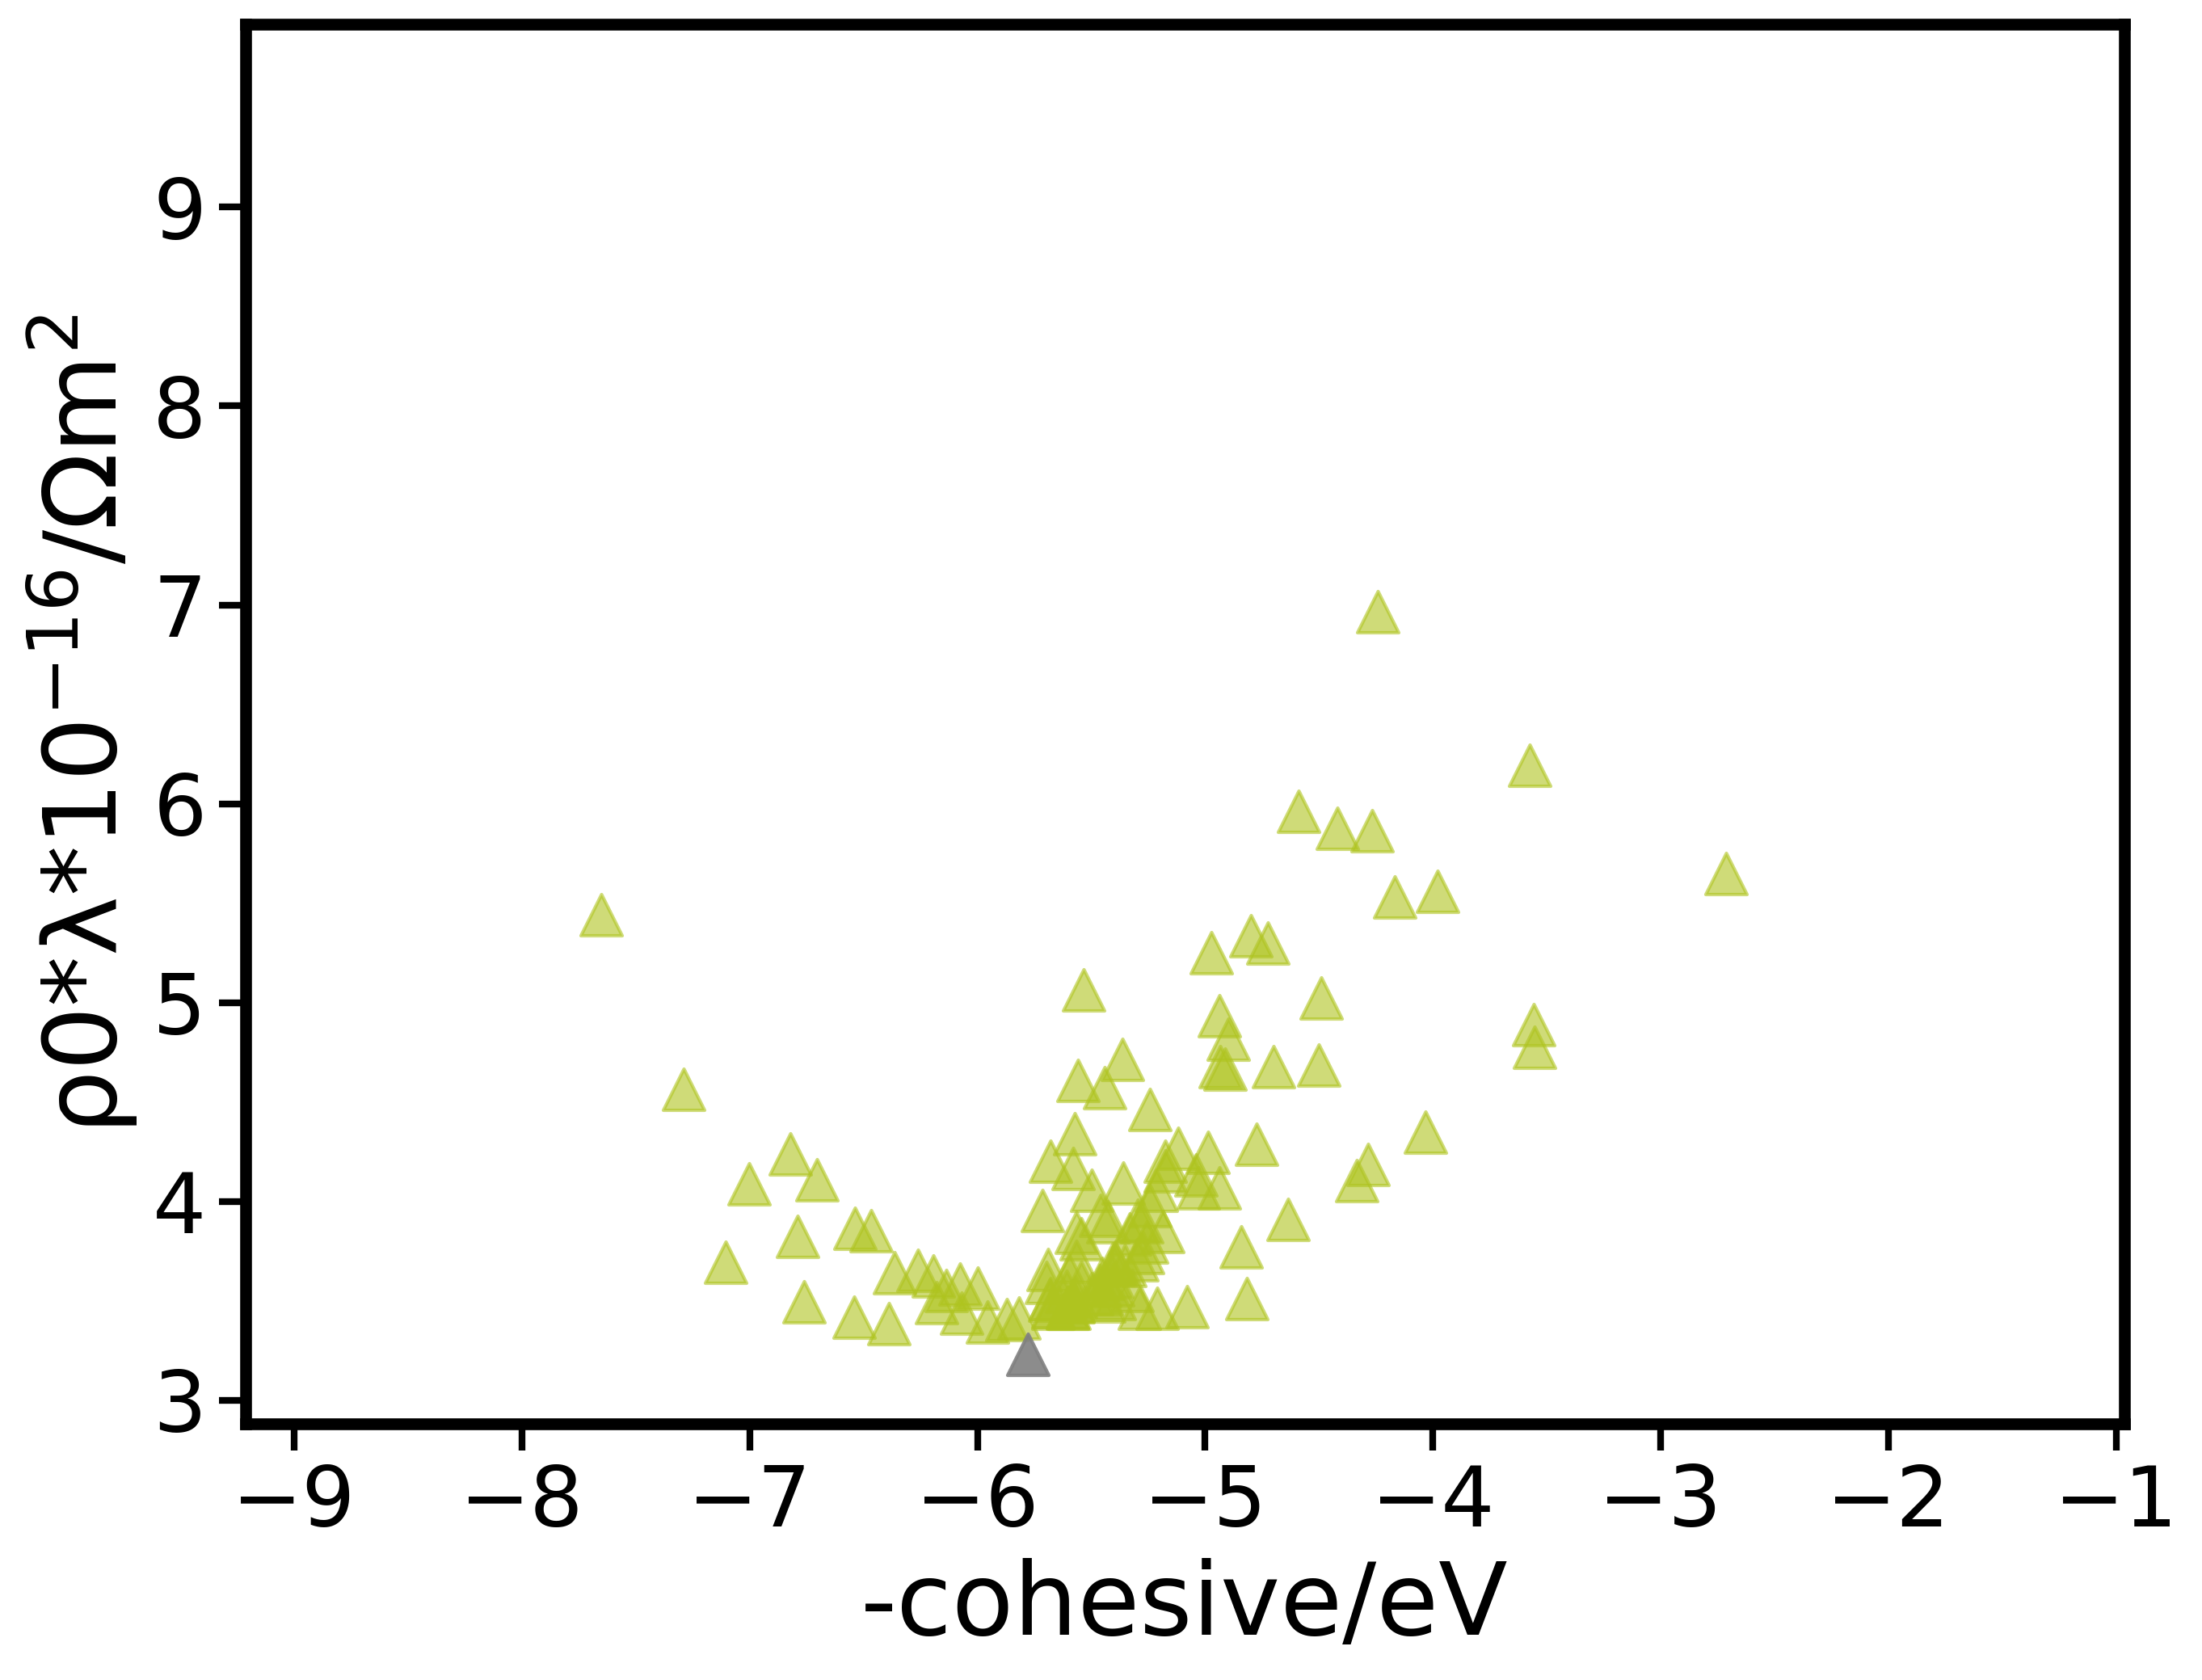

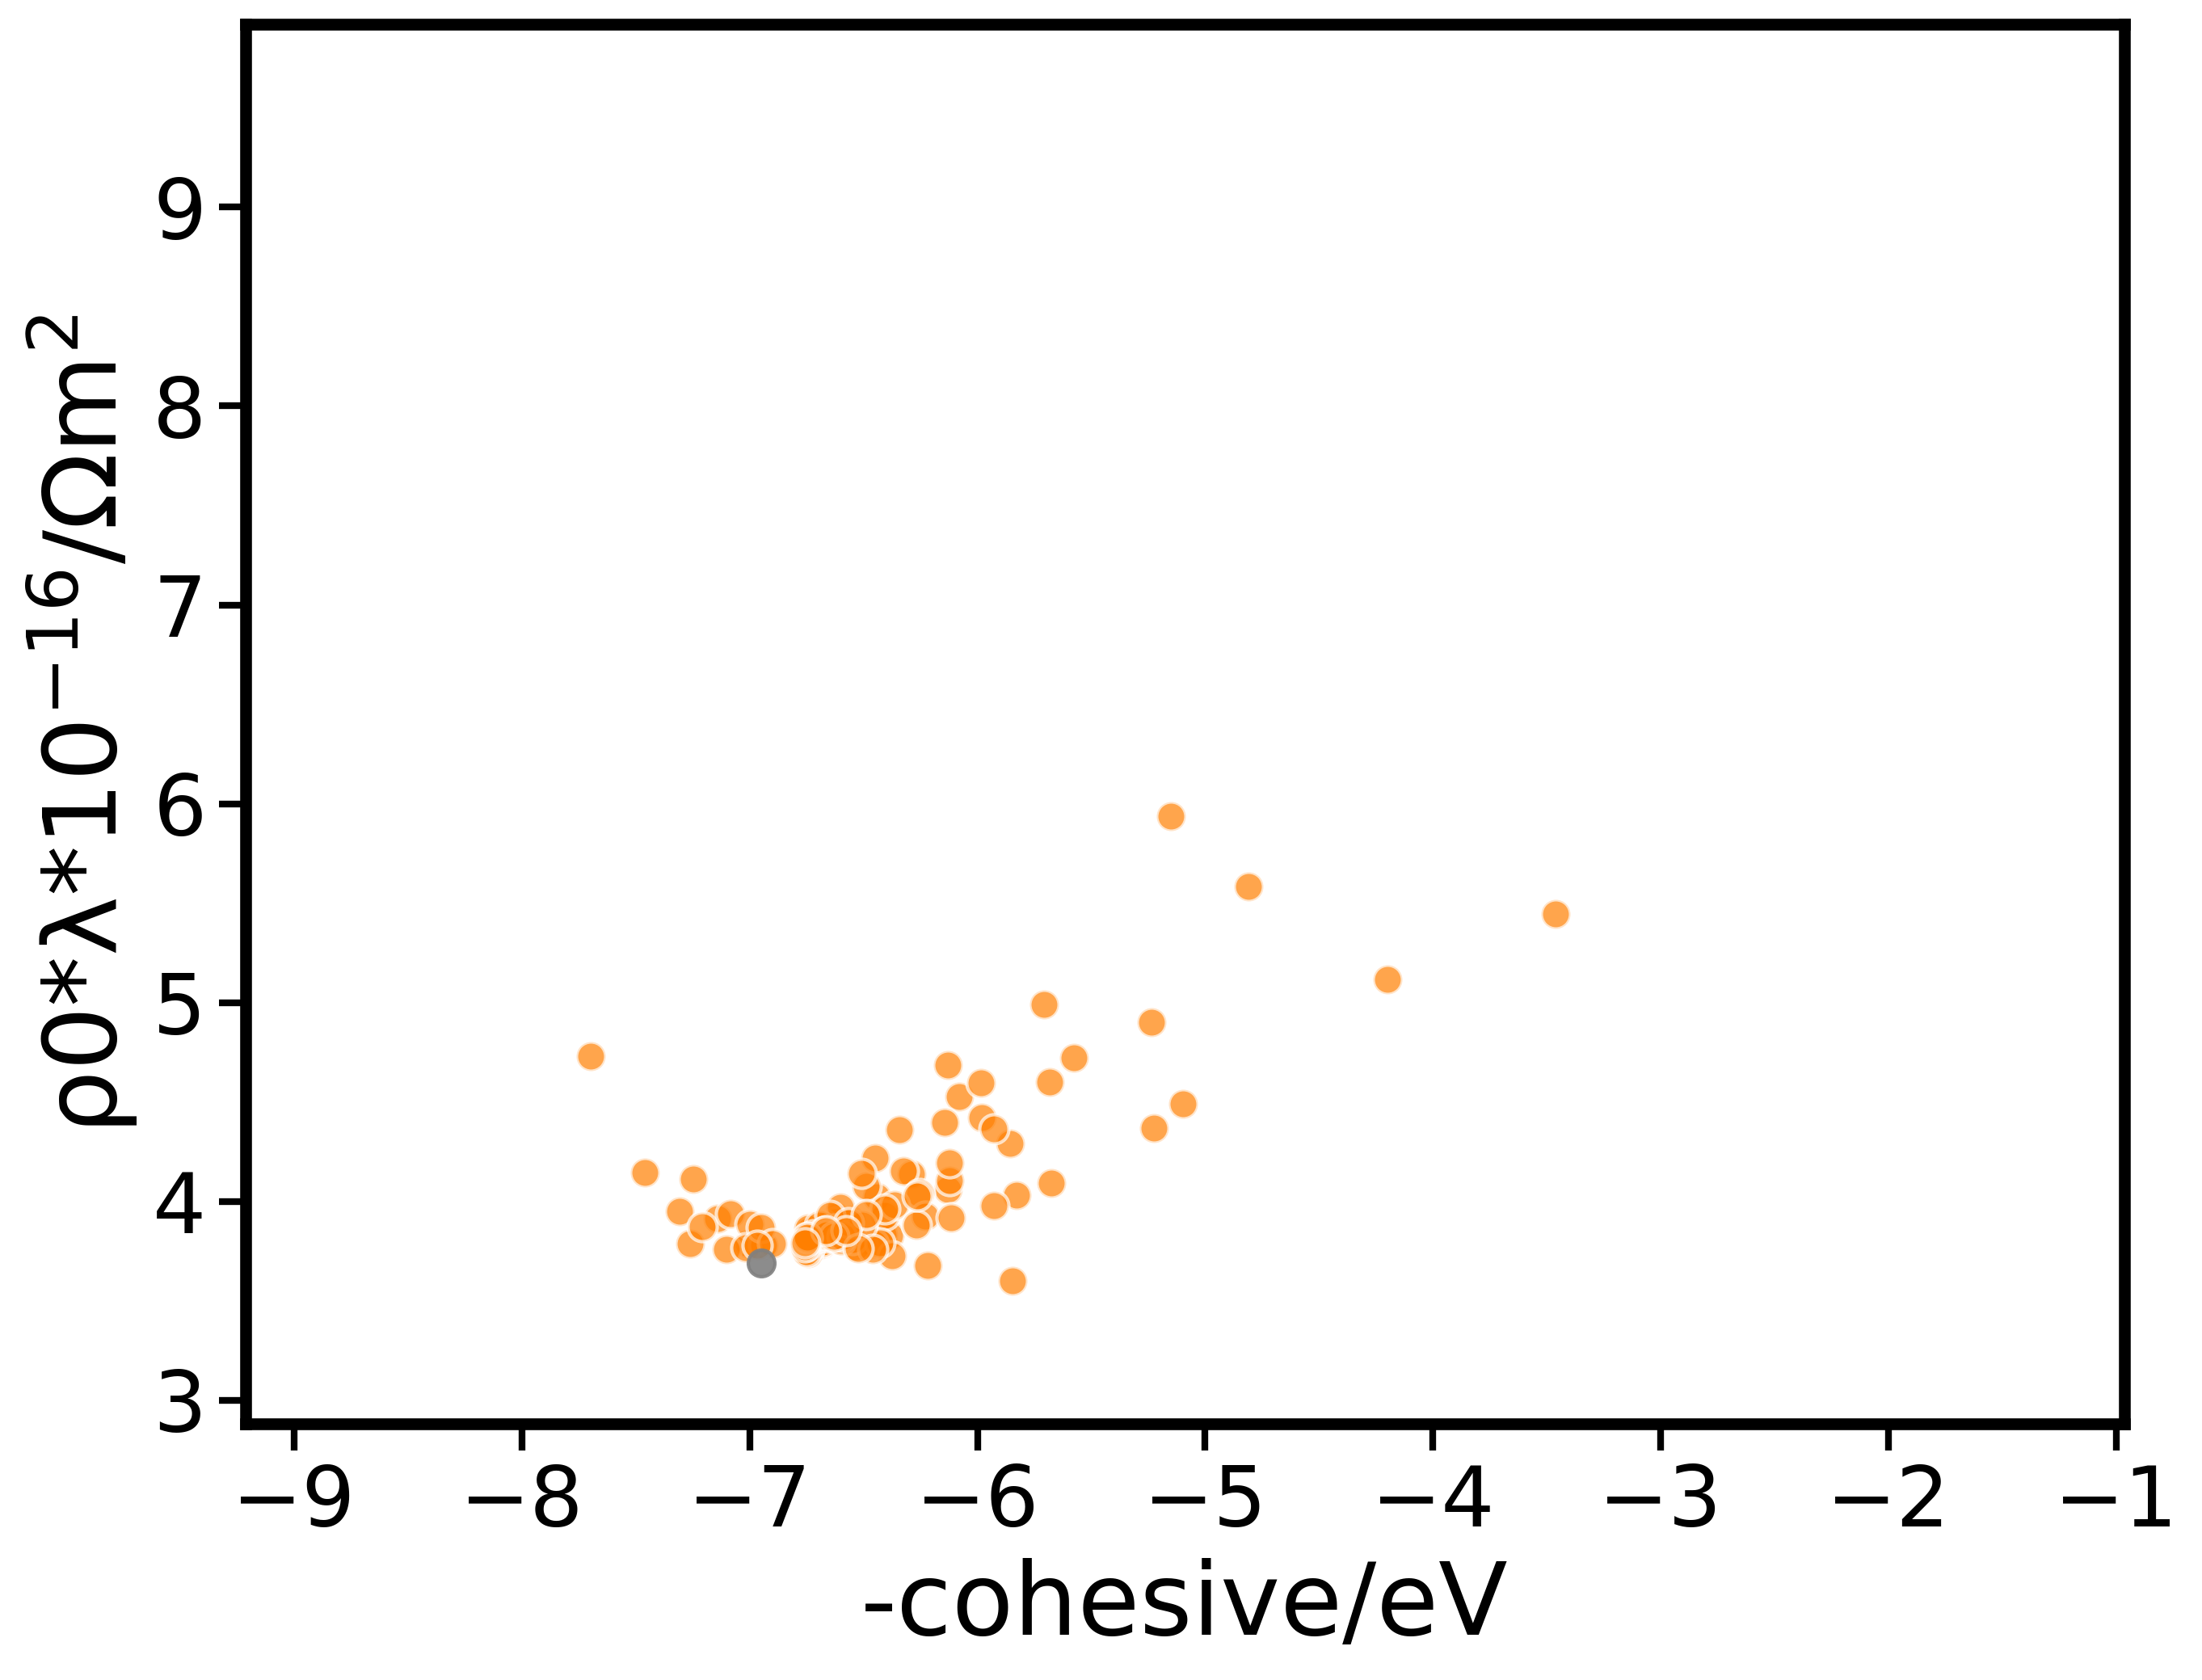

In [4]:
plt.figure(figsize=(10, 7.5),dpi= 300)
ax = plt.gca()
# 设置小图的坐标范围与大图相同

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.spines['bottom'].set_linewidth(3.5)
ax.spines['left'].set_linewidth(3.5)
ax.spines['top'].set_linewidth(3.5)
ax.spines['right'].set_linewidth(3.5)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.tick_params(axis='both', which='major', width=2)
plt.tick_params(axis='both', length=8)
# plt.scatter(-X1, y1, s=200, c='#E87B1E', marker='.', alpha=0.8) 
# plt.scatter(-X1, y1,s = 100,c='#FFCB5B', marker='X', alpha=0.6)  # 绘制 Cu 预测数据点  2.0
plt.scatter(-X1, y1,s = 100,c='#E41A1C', marker='X', alpha=0.6)  # 绘制 Cu 预测数据点  3.0
# plt.scatter(-3.46, 5.44, s=200, c='#E87B1E', marker='.', alpha=0.8)  #CuMn
# X7=[3.44,2.9,4.6,4.1,3.7,3.7,3.7]  #Cu  Cu2Mg CuPt AlCu t-Cu2Al3 c-CuAl2 c2-Cu3Al
# y7=[6.7,9.6,6.8,6,6,3.8,3.2]
# plt.scatter(-X7,y7,s=200,c='#808080',marker='.',alpha=0.9) 
# plt.scatter(-3.44,6.7,s=200,c='#808080',marker='.',alpha=0.9)   # Cu
# plt.scatter(-2.9,9.6,s=200,c='#808080',marker='.',alpha=0.9)  #Cu2Mg
# plt.scatter(-4.6,6.8,s=200,c='#808080',marker='.',alpha=0.9)   # CuPt 
# plt.scatter(-4.1,6,s=200,c='#808080',marker='.',alpha=0.9)     #AlCu
# plt.scatter(-3.7,6,s=200,c='#808080',marker='.',alpha=0.9)     # t-Cu2Al3
# plt.scatter(-3.7,3.8,s=200,c='#808080',marker='.',alpha=0.9)     #c-CuAl2
# plt.scatter(-3.7,3.2,s=200,c='#808080',marker='.',alpha=0.9)     #c2-Cu3Al
plt.scatter(-3.44,6.7,s=100,c='#808080',marker='X',alpha=0.9)   # Cu
plt.scatter(-2.9,9.6,s=100,c='#808080',marker='X',alpha=0.9)  #Cu2Mg
plt.scatter(-4.6,6.8,s=100,c='#808080',marker='X',alpha=0.9)   # CuPt 
plt.scatter(-4.1,6,s=100,c='#808080',marker='X',alpha=0.9)     #AlCu
plt.scatter(-3.7,6,s=100,c='#808080',marker='X',alpha=0.9)     # t-Cu2Al3
plt.scatter(-3.7,3.8,s=100,c='#808080',marker='X',alpha=0.9)     #c-CuAl2
plt.scatter(-3.7,3.2,s=100,c='#808080',marker='X',alpha=0.9)     #c2-Cu3Al
# plt.title('Cu-Double target forecasting',fontsize=35)
plt.xlabel('-cohesive/eV',fontsize=30)
plt.ylabel('ρ0*λ*10$^{-16}$/Ωm$^2$',fontsize=30)
# plt.savefig('Cu-Double target forecasting-2.0.png', dpi=300, bbox_inches='tight')
plt.savefig('Cu-Double target forecasting-3.0.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 7.5),dpi= 300)
ax = plt.gca()
# 设置小图的坐标范围与大图相同
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.spines['bottom'].set_linewidth(3.5)
ax.spines['left'].set_linewidth(3.5)
ax.spines['top'].set_linewidth(3.5)
ax.spines['right'].set_linewidth(3.5)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.tick_params(axis='both', which='major', width=2)
plt.tick_params(axis='both', length=8)
# plt.scatter(-X2, y2, s=80, c='#0076B9', marker='D', alpha=0.8)
# plt.scatter(-X2, y2,s = 80,c='#C5B0D4', marker='s', alpha=0.8)  # 绘制 Co 预测数据点 2.0
plt.scatter(-X2, y2,s = 80,c='#0074D9', marker='s', alpha=0.8)  # 绘制 Co 预测数据点 3.0
plt.scatter(-4.37,4.82,s=80,c='#808080',marker='s',alpha=0.9)
# plt.title('Co-Double target forecasting',fontsize=35)
plt.xlabel('-cohesive/eV',fontsize=30)
plt.ylabel('ρ0*λ*10$^{-16}$/Ωm$^2$',fontsize=30)
# plt.savefig('Co-Double target forecasting-2.0.png', dpi=300, bbox_inches='tight')
plt.savefig('Co-Double target forecasting-3.0.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 7.5),dpi= 300)
ax = plt.gca()
# 设置小图的坐标范围与大图相同
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.spines['bottom'].set_linewidth(3.5)
ax.spines['left'].set_linewidth(3.5)
ax.spines['top'].set_linewidth(3.5)
ax.spines['right'].set_linewidth(3.5)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.tick_params(axis='both', which='major', width=2)
plt.tick_params(axis='both', length=8)
# plt.scatter(-X3, y3, s=200, c='#CC5B45', marker='*', alpha=0.8)
# plt.scatter(-X3, y3,s = 200,c='#F69C9C', marker='*', alpha=0.9)  # 绘制 Ru 预测数据点 2.0
plt.scatter(-X3, y3,s = 200,c='#984EA3', marker='*', alpha=0.9)  # 绘制 Ru 预测数据点 3.0

plt.scatter(-6.77,3.81,s=200,c='#808080',marker='*',alpha=0.9)
# plt.title('Ru-Double target forecasting',fontsize=35)
plt.xlabel('-cohesive/eV',fontsize=30)
plt.ylabel('ρ0*λ*10$^{-16}$/Ωm$^2$',fontsize=30)
# plt.savefig('Ru-Double target forecasting-2.0.png', dpi=300, bbox_inches='tight')
plt.savefig('Ru-Double target forecasting-3.0.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 7.5),dpi= 300)
ax = plt.gca()
# 设置小图的坐标范围与大图相同
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.spines['bottom'].set_linewidth(3.5)
ax.spines['left'].set_linewidth(3.5)
ax.spines['top'].set_linewidth(3.5)
ax.spines['right'].set_linewidth(3.5)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.tick_params(axis='both', which='major', width=2)
plt.tick_params(axis='both', length=8)
# plt.scatter(-X4, y4, s=200, c='#FFCB5B', marker='^', alpha=0.8)
# plt.scatter(-X4, y4,s = 150,c='#96AEDA', marker='^', alpha=0.6)  # 绘制预 Rh测数据点  4DAF4A LVSE 2.0
plt.scatter(-X4, y4,s = 150,c='#AFC41F', marker='^', alpha=0.6)  # 绘制预 Rh测数据点  4DAF4A LVSE  3.0

plt.scatter(-5.78,3.23,s=150,c='#808080',marker='^',alpha=0.9)
# plt.title('Rh-Double target forecasting',fontsize=35)
plt.xlabel('-cohesive/eV',fontsize=30)
plt.ylabel('ρ0*λ*10$^{-16}$/Ωm$^2$',fontsize=30)
# plt.savefig('Rh-Double target forecasting-2.0.png', dpi=300, bbox_inches='tight')
plt.savefig('Rh-Double target forecasting-3.0.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 7.5),dpi= 300)
ax = plt.gca()
# 设置小图的坐标范围与大图相同
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.spines['bottom'].set_linewidth(3.5)
ax.spines['left'].set_linewidth(3.5)
ax.spines['top'].set_linewidth(3.5)
ax.spines['right'].set_linewidth(3.5)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.tick_params(axis='both', which='major', width=2)
plt.tick_params(axis='both', length=8)
# plt.scatter(-X5, y5, s=80, c='#0098B2', marker='s', alpha=0.8)
# plt.scatter(-X5, y5,s = 300, marker='.' ,edgecolors='white', facecolors='#AFC41F',alpha=0.6)    # 绘制预 IR测数据点  0098B2  湖蓝色   8DC2BA  #A9AB35 c草绿色 2.0
plt.scatter(-X5, y5,s = 300, marker='.', edgecolors='white', facecolors='#FF7F00',alpha=0.7)  #3.0
plt.scatter(-6.95,3.69,s=250,c='#808080',marker='.',alpha=0.9)
# plt.title('Ir-Double target forecasting',fontsize=35)
plt.xlabel('-cohesive/eV',fontsize=30)
plt.ylabel('ρ0*λ*10$^{-16}$/Ωm$^2$',fontsize=30)
# plt.savefig('Ir-Double target forecasting-2.0.png', dpi=300, bbox_inches='tight')
plt.savefig('Ir-Double target forecasting-3.0.png', dpi=300, bbox_inches='tight')
plt.show()

# pareto前沿点修改

In [2]:
import pandas as pd
import numpy as np
from joblib import dump, load
import sys
import math
import seaborn as sns
import matplotlib.pyplot as plt
# from pyOptBaye import *
from modules import *

def plot_get_front_shape_2D(y):
    y_front=[]
    m=y.shape[0]
    for i in range(m-1):
       y_front.append(y[i])
       y_front.append([y[i+1][0],y[i][1]])
    y_front.append(y[-1])
    y_front=np.array(y_front)
    return y_front

def plot_pareto_set_front_2D_all(y,yall,yall2,output=False,title='pareto set',fname='pareto_set',loc='.',plt_prop=True):
    ## to contruct pareto front based on pareto set
    y_front=[]
    m=y.shape[0]
    for i in range(m-1):
       y_front.append(y[i])
       y_front.append([y[i+1][0],y[i][1]])
    y_front.append(y[-1])
    y_front=np.array(y_front)
    ## plot figure
    plt.figure(figsize=(12,10))
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    #plt.title(title,fontsize=20)
    plt.xlabel('-Cohesive energy/eV',fontsize=20)
    plt.ylabel('ρ0*λ*10$^{-16}$/Ωm$^2$',fontsize=20)
    ax=plt.gca()
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['top'].set_linewidth(2)
    ax.spines['right'].set_linewidth(2)
    plt.scatter(yall2[:,0 ], yall2[:,1],c='k',alpha=0.25)
    plt.scatter(yall[:,0 ], yall[:,1],c='g')
    plt.scatter(y[:,0 ], y[:,1],c='b')
    plt.plot(y_front[:,0],y_front[:,1],c='b')
    if output:
      plt.savefig(f'{loc}/{fname}.png',dpi=300,bbox_inches='tight')
    if plt_prop:
      plt.show()
        
def init_pareto_set_2D(y1,y2,label_sys):
   init_set,init_set_label=[],[]
   m=len(y1)
   for i in range(m):
      typ=[]
      for j in range(m):
        if i ==j:
           continue
        else:
         if y1[j] < y1[i] and y2[j] < y2[i]:
           typ.append(False)
         else:
           typ.append(True)
      if all(typ):
         init_set.append([y1[i],y2[i]])
         init_set_label.append(label_sys[i])
   
   return np.array(init_set),np.array(init_set_label)

### To rank the pareti set with ascend order of y1 for single and doubel objectives
def rank_goal(y,label):
   n=len(np.array(y).shape)
   if n==2:
      #print(sorted(y,key=lambda x:x[0]))
      y_n=y[np.lexsort(y[:,::-1].T)]
      label_n=label[np.lexsort(y[:,::-1].T)] 
      return y_n,label_n   
   elif n==1:
      y_n=y[np.argsort(y)]
      label_n=label[np.argsort(y)]
      return y_n,label_n
   else:
      raise ValueError("No support for > 2 goals")

# def optimization(ps,y11,std1,y12,std2,label_sys1,n=5):
#    EI=[]
#    for i in range(len(y11)):
#      PI=PI_2D_aug(ps,y11[i],std1[i],y12[i],std2[i])
#      y1_centroid,y2_centroid=Centroid_aug(ps,y11[i],std1[i],y12[i],std2[i],PI)
#      EI.append(EI_2D(ps,y1_centroid,y2_centroid,PI))
#    EI=np.array(EI)
#    EI_potential=EI[np.argsort(-EI)]
#    label_potential=label_sys1[np.argsort(-EI)]
#    return EI_potential[0:n],label_potential[0:n],EI_potential,label_potential,EI,label_sys1


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
(584, 1)
[[-8.84  8.2 ]
 [-8.4   5.1 ]
 [-8.18  4.33]
 [-7.56  3.91]
 [-6.95  3.69]
 [-6.4   3.6 ]
 [-5.88  3.43]
 [-5.78  3.23]
 [-3.7   3.2 ]]
(np.float64(-9.215), np.float64(-0.9650000000000001))
(np.float64(2.8800000000000003), np.float64(9.92))


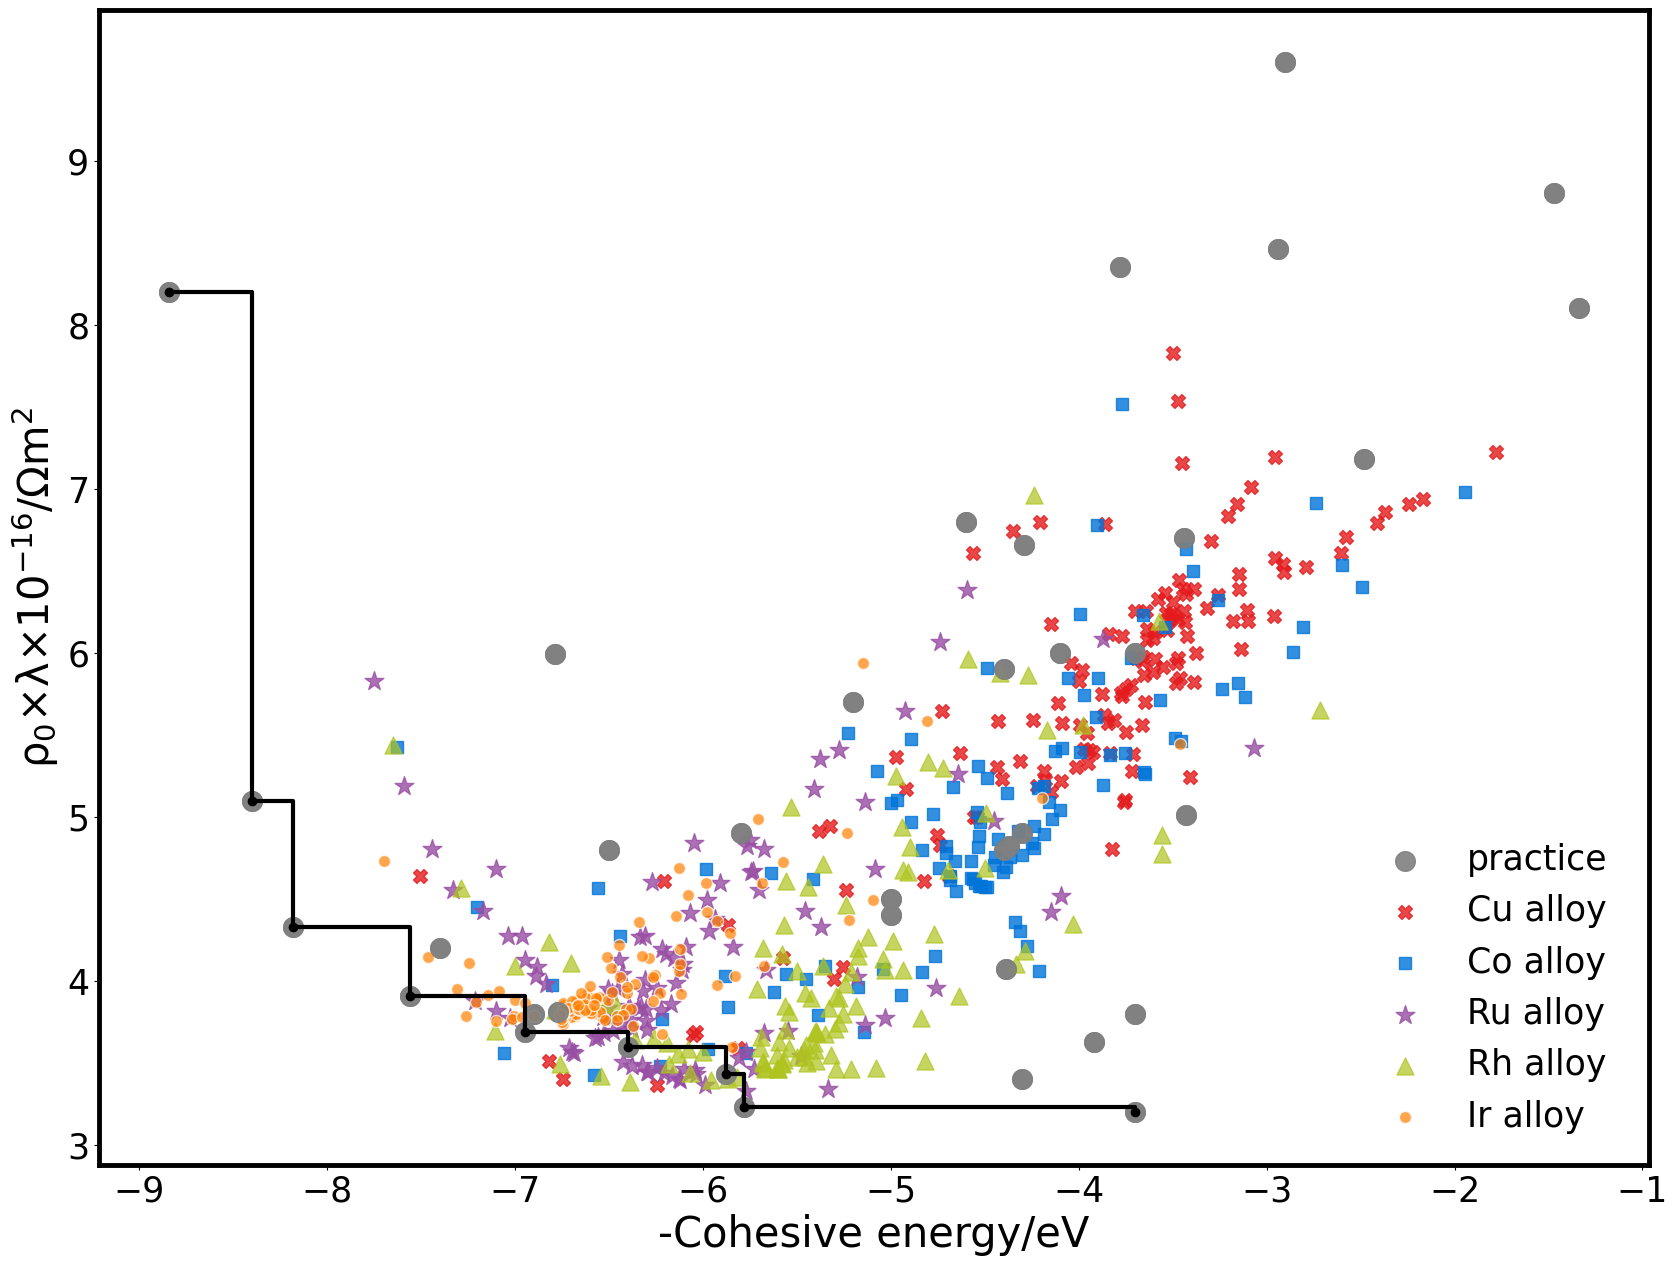

In [3]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RepeatedKFold
from sklearn.feature_selection import SelectKBest
from matplotlib.backend_bases import MouseButton
from scipy.stats import pearsonr
from modules import *
from sklearn.svm import SVR
import pandas as pd
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import modules
from matplotlib.ticker import MultipleLocator

def plot_pareto_set_front_2D_all(y,yall,yall2,output=False,title='pareto set',fname='pareto_set',loc='.',plt_prop=True):
    ## to contruct pareto front based on pareto set
    y_front=[]
    m=y.shape[0]
    for i in range(m-1):
       y_front.append(y[i])
       y_front.append([y[i+1][0],y[i][1]])
    y_front.append(y[-1])
    y_front=np.array(y_front)
    ## plot figure
    plt.figure(figsize=(20,15))
    plt.xticks(fontsize=25)
    plt.yticks(fontsize=25)
    #plt.title(title,fontsize=20)
 
    ax=plt.gca()
    ax.spines['bottom'].set_linewidth(3.5)
    ax.spines['left'].set_linewidth(3.5)
    ax.spines['top'].set_linewidth(3.5)
    ax.spines['right'].set_linewidth(3.5)
    
    plt.scatter(yall[:,0 ], yall[:,1],s = 200,c='#808080', alpha=0.9)
    
    X1=yall2[:135,0]  # [:134]
    X2=yall2[135:249,0]  #[134:249]
    X3=yall2[249:359,0]   #[249:360]
    X4=yall2[359:472,0]    #[360:472]
    X5=yall2[472:584,0]    #[472:582]
    y1=yall2[:135,1]
    y2=yall2[135:249,1]
    y3=yall2[249:359,1]
    y4=yall2[359:472,1]
    y5=yall2[472:584,1]
    plt.scatter(X1, y1,s = 100,c='#E41A1C', marker='X', alpha=0.8)  # 绘制 Cu 预测数据点
    plt.scatter(X2, y2,s = 80,c='#0074D9', marker='s', alpha=0.8)  # 绘制 Co 预测数据点
    plt.scatter(X3, y3,s = 200,c='#984EA3', marker='*', alpha=0.8)  # 绘制 Ru 预测数据点 
    plt.scatter(X4, y4,s = 150,c='#AFC41F', marker='^', alpha=0.7)  # 绘制预 Rh测数据点  4DAF4A LVSE
    plt.scatter(X5, y5,s = 300,marker='.',edgecolors='white', facecolors='#FF7F00',alpha=0.7)    # 绘制预 IR测数据点  0098B2  湖蓝色 6a8ec9
    
    plt.scatter(yall[:,0 ], yall[:,1],s = 200,c='#808080', alpha=0.9)
    plt.scatter(y[:,0 ], y[:,1],c='k')
    plt.plot(y_front[:,0],y_front[:,1],c='k',linewidth=3.0)
    ax = plt.gca()  # 获取当前轴对象
    print(ax.get_xlim())  # 获取x轴范围
    print(ax.get_ylim())  # 获取y轴范围
    
    #获取大图的坐标范围
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    plt.legend(['practice','Cu alloy','Co alloy','Ru alloy','Rh alloy ','Ir alloy'],loc=0,fontsize=25,frameon=False)
    plt.xlabel('-Cohesive energy/eV',fontsize=30)
    plt.ylabel('ρ$_0$×λ×10$^{-16}$/Ωm$^2$',fontsize=30)
    if output:
      plt.savefig('CO-KRR,SVR_fps-4.0.png',dpi=300,bbox_inches='tight')
      # plt.savefig('CO-GPR,SVR_fps-4.0.png',dpi=300,bbox_inches='tight')
    if plt_prop:
      plt.show()

File='../data.4/em-wt-10'
X,y= sub_data(File)
X=X[:38,-1:]
y=y[:38]
y=y.reshape(-1, 1)
data=np.hstack((-np.array(X),np.array(y)))
item = data.shape[0]
label=list(range(item))
print(label)

d=pd.DataFrame(data)

co_pre = pd.read_csv('pKRR-1.csv').iloc[:, 0].values
# co_pre = pd.read_csv('pGPR-1.csv').iloc[:, 0].values
re_pre = pd.read_csv('pSVR-2.csv').iloc[:, 0].values
co_pre=co_pre.reshape(-1, 1)
re_pre=re_pre.reshape(-1, 1)
print(co_pre.shape)
labeln=list(range(d.shape[0]))
#print(labeln)
#print(d.iloc[:,0])

ps_init,ps_init_label=init_pareto_set_2D(np.array(d.iloc[:,0]),np.array(d.iloc[:,1]),labeln)
ps,label=rank_goal(ps_init,ps_init_label)
print(ps)
m=0
#print(EC_pred_data.shape)
#print(TE_pred_data.shape)
#print(len(labels))
tmp=np.array([np.array(d.iloc[:,0]),np.array(d.iloc[:,1])]).T
# print(tmp)
tmp2=np.array([-co_pre[:,0], re_pre[:, 0]]).T
plot_pareto_set_front_2D_all(ps,tmp,tmp2,output=True,title='pareto set',fname=f'0{m}_pareto_set',loc=f'0{m}',plt_prop=True)
# EI_pot,label_pot,EI_sort,label_sort,EI,label=optimization(ps,EC_pred_data[:,0],EC_pred_data[:,1],TE_pred_data[:,0],TE_pred_data[:,1],np.array(labels),n=5)
# print(EI_pot,label_pot)


In [4]:
# 每一类图的大致数据划分
X1=co_pre[:135]  # [:134]
X2=co_pre[135:249]  #[134:249]
X3=co_pre[249:359]   #[249:360]
X4=co_pre[359:472]    #[360:472]
X5=co_pre[472:584]    #[472:582]
y1=re_pre[:135]
y2=re_pre[135:249]
y3=re_pre[249:359]
y4=re_pre[359:472]
y5=re_pre[472:584]

y_front=[]
m=ps.shape[0]
for i in range(m-1):
   y_front.append(ps[i])
   y_front.append([ps[i+1][0],ps[i][1]])
y_front.append(ps[-1])
y_front=np.array(y_front)



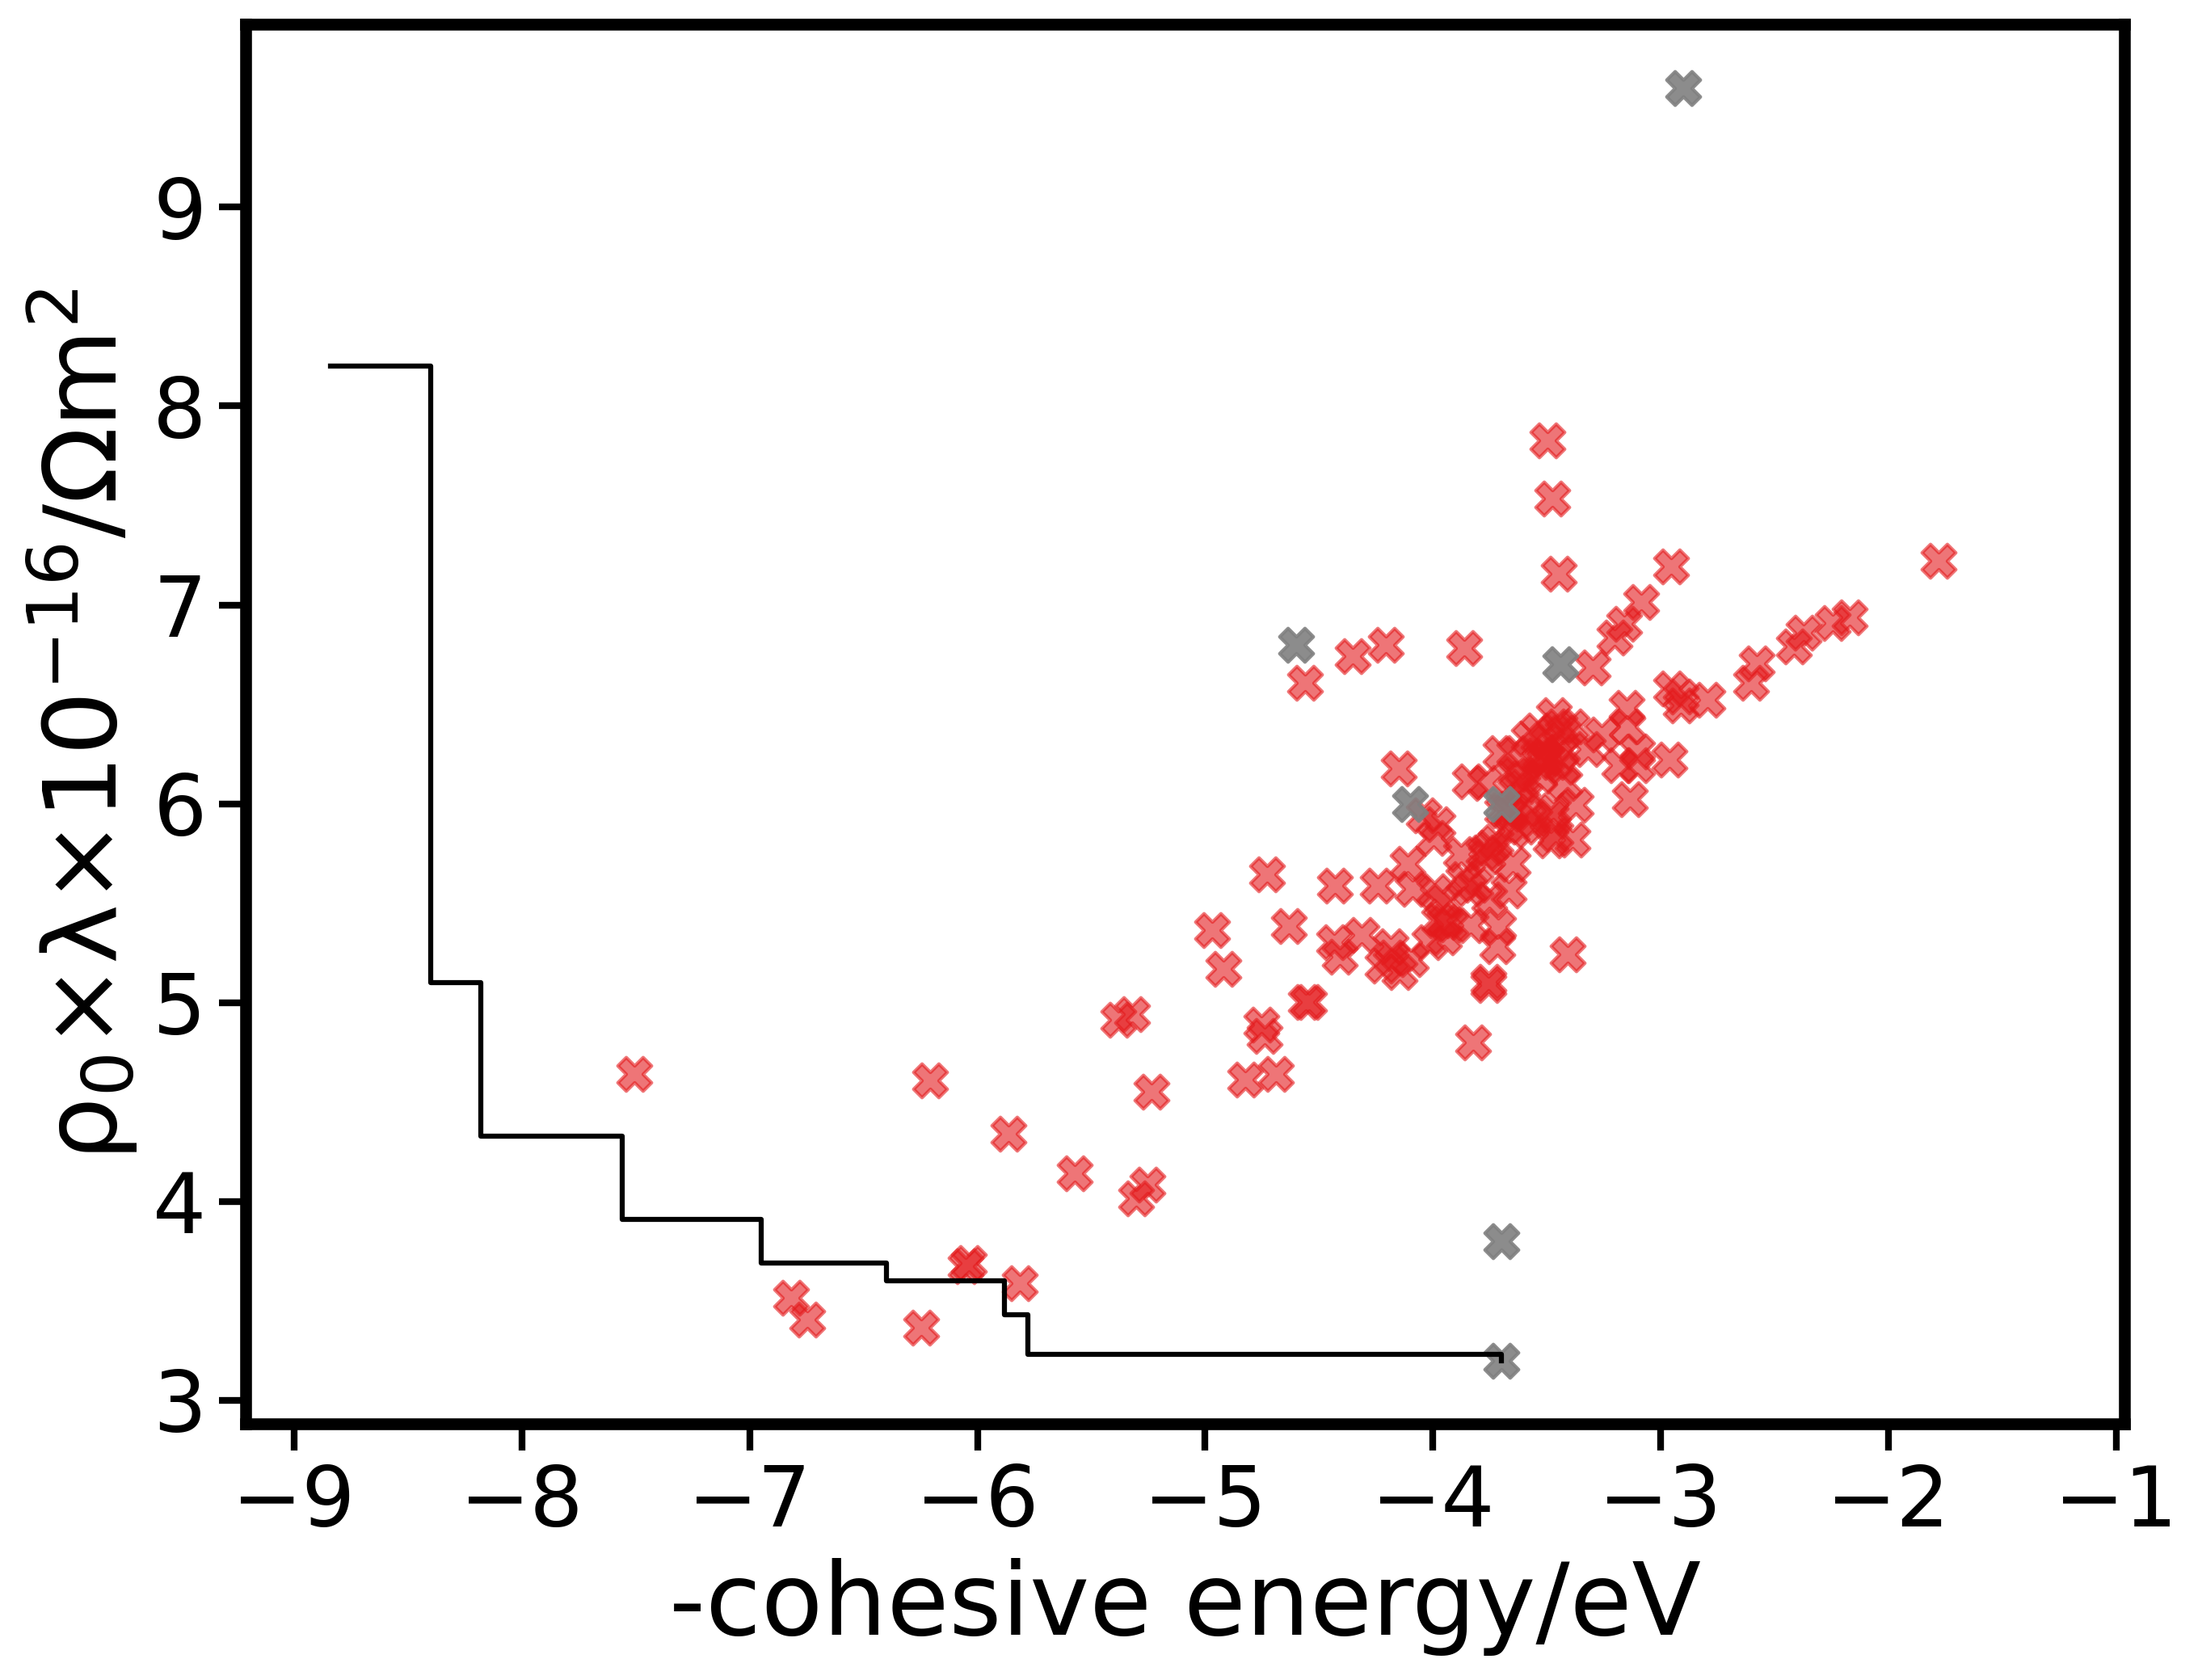

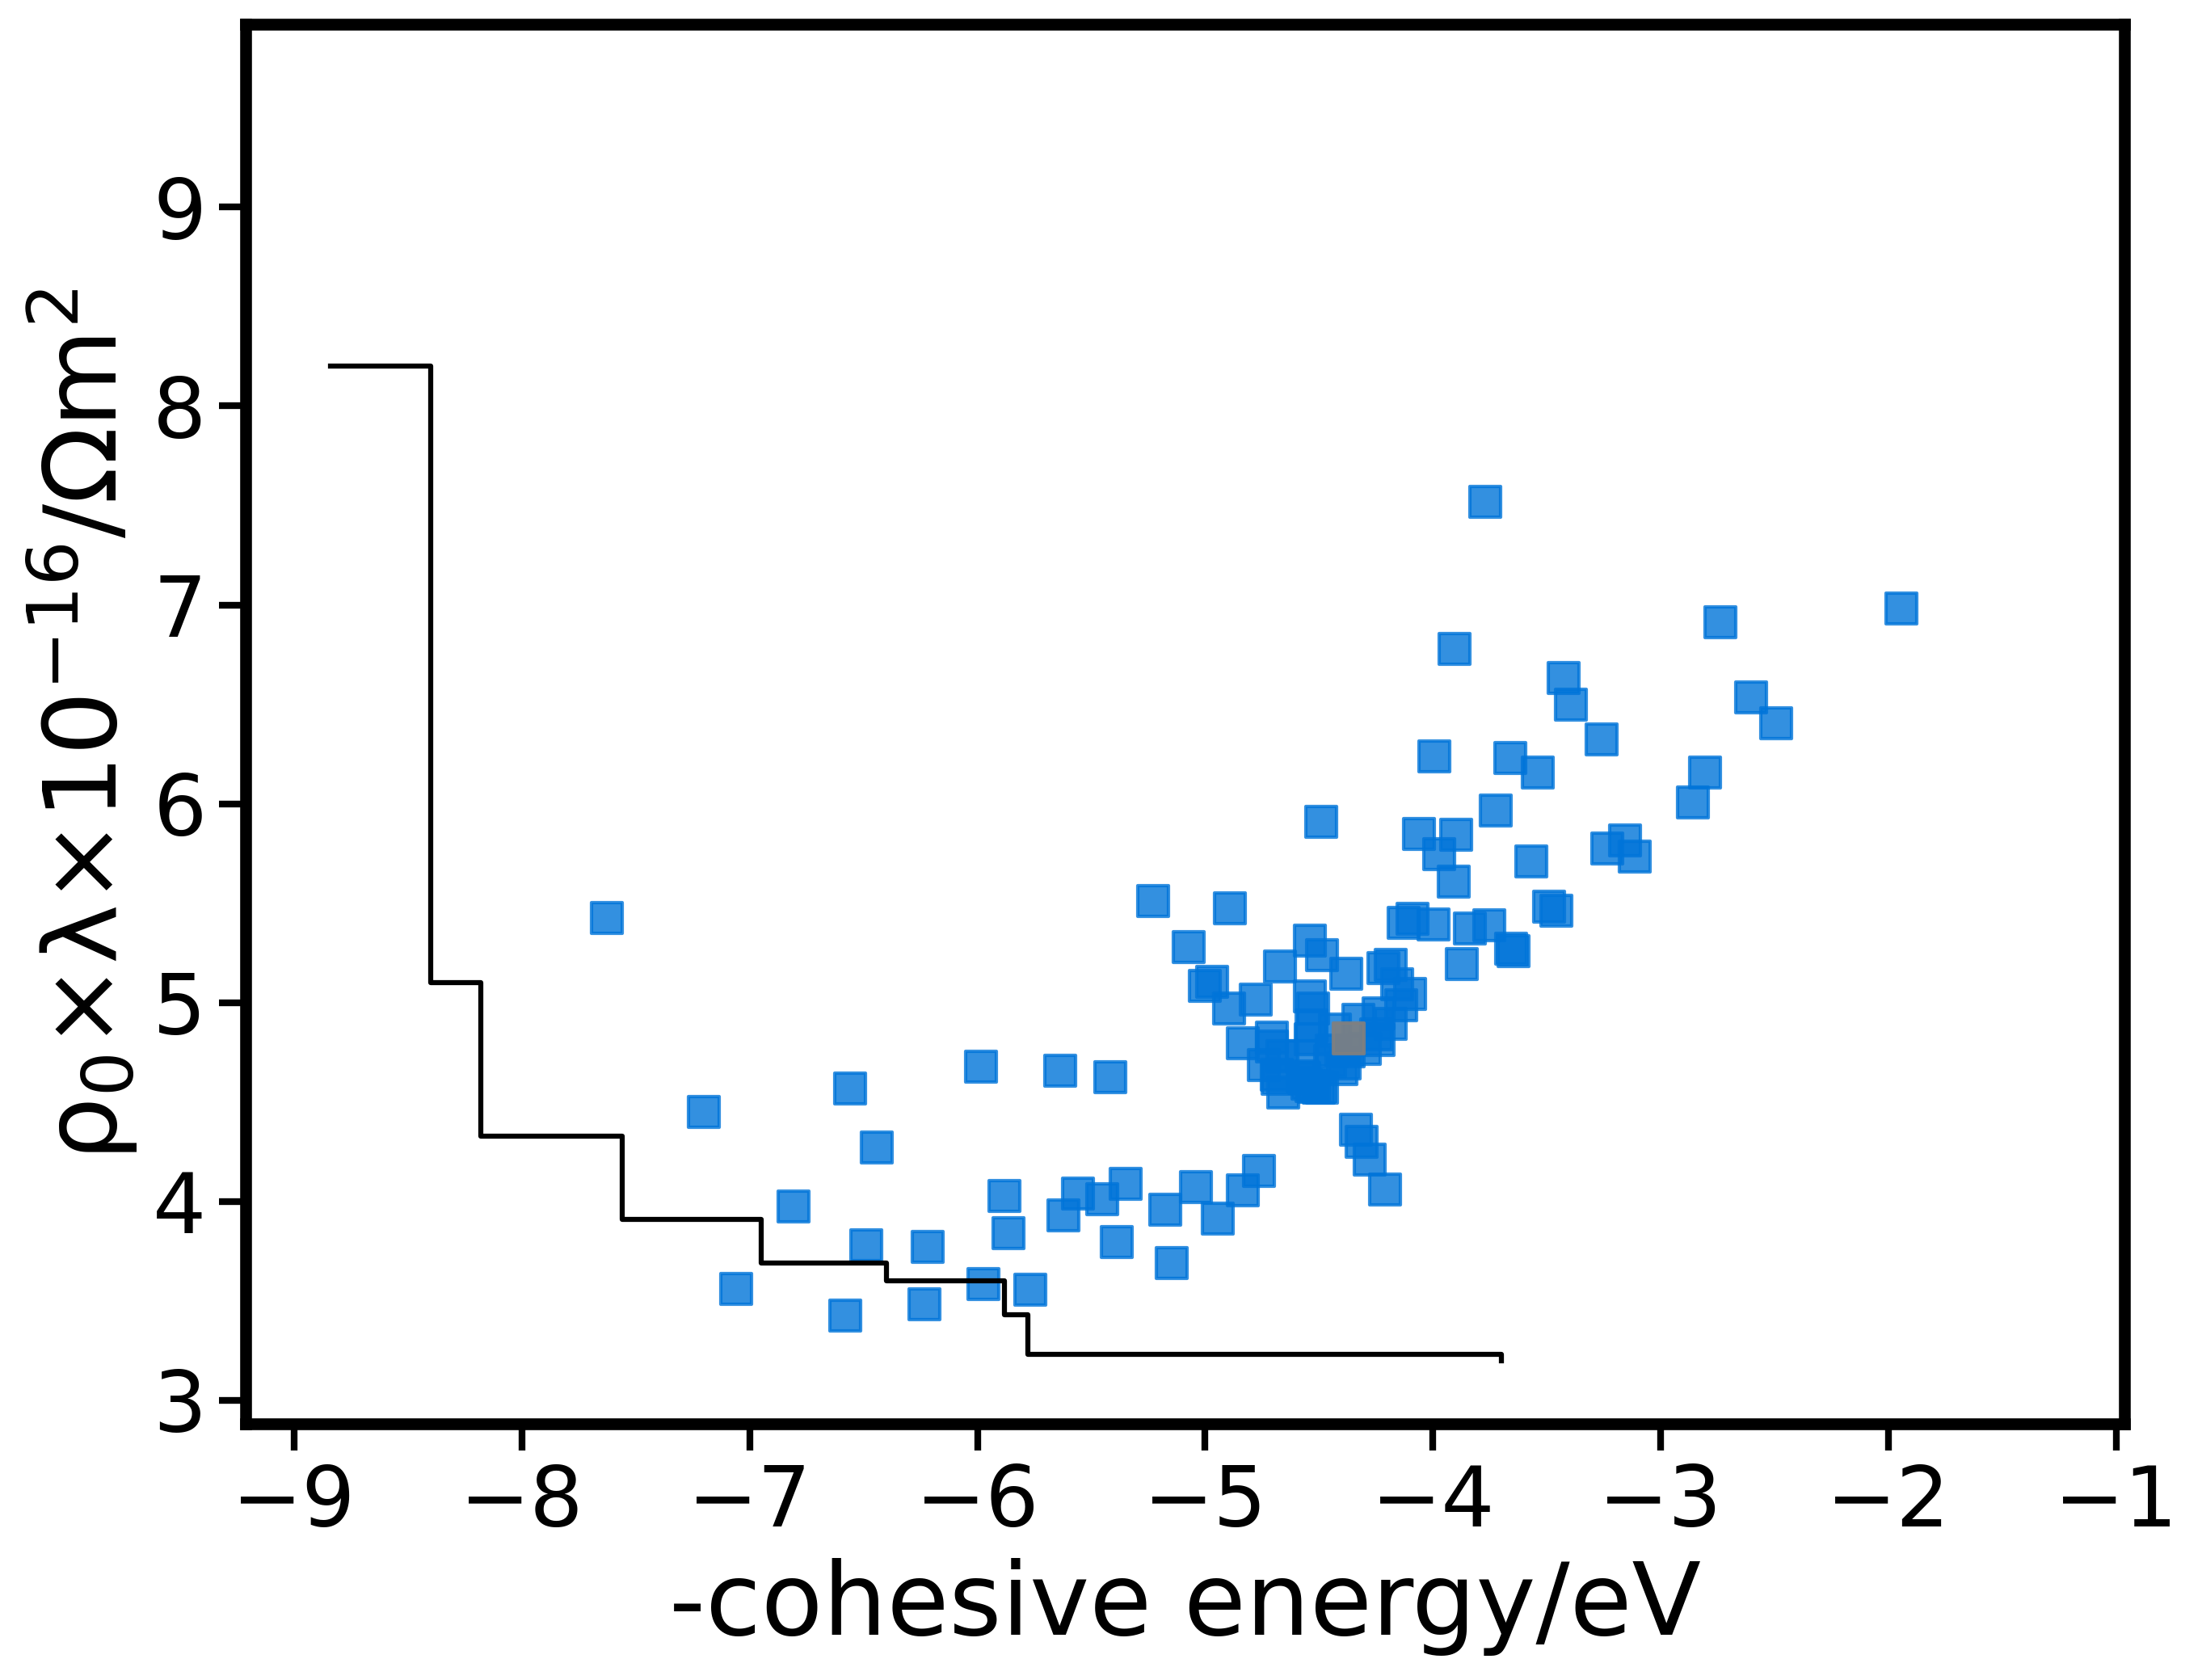

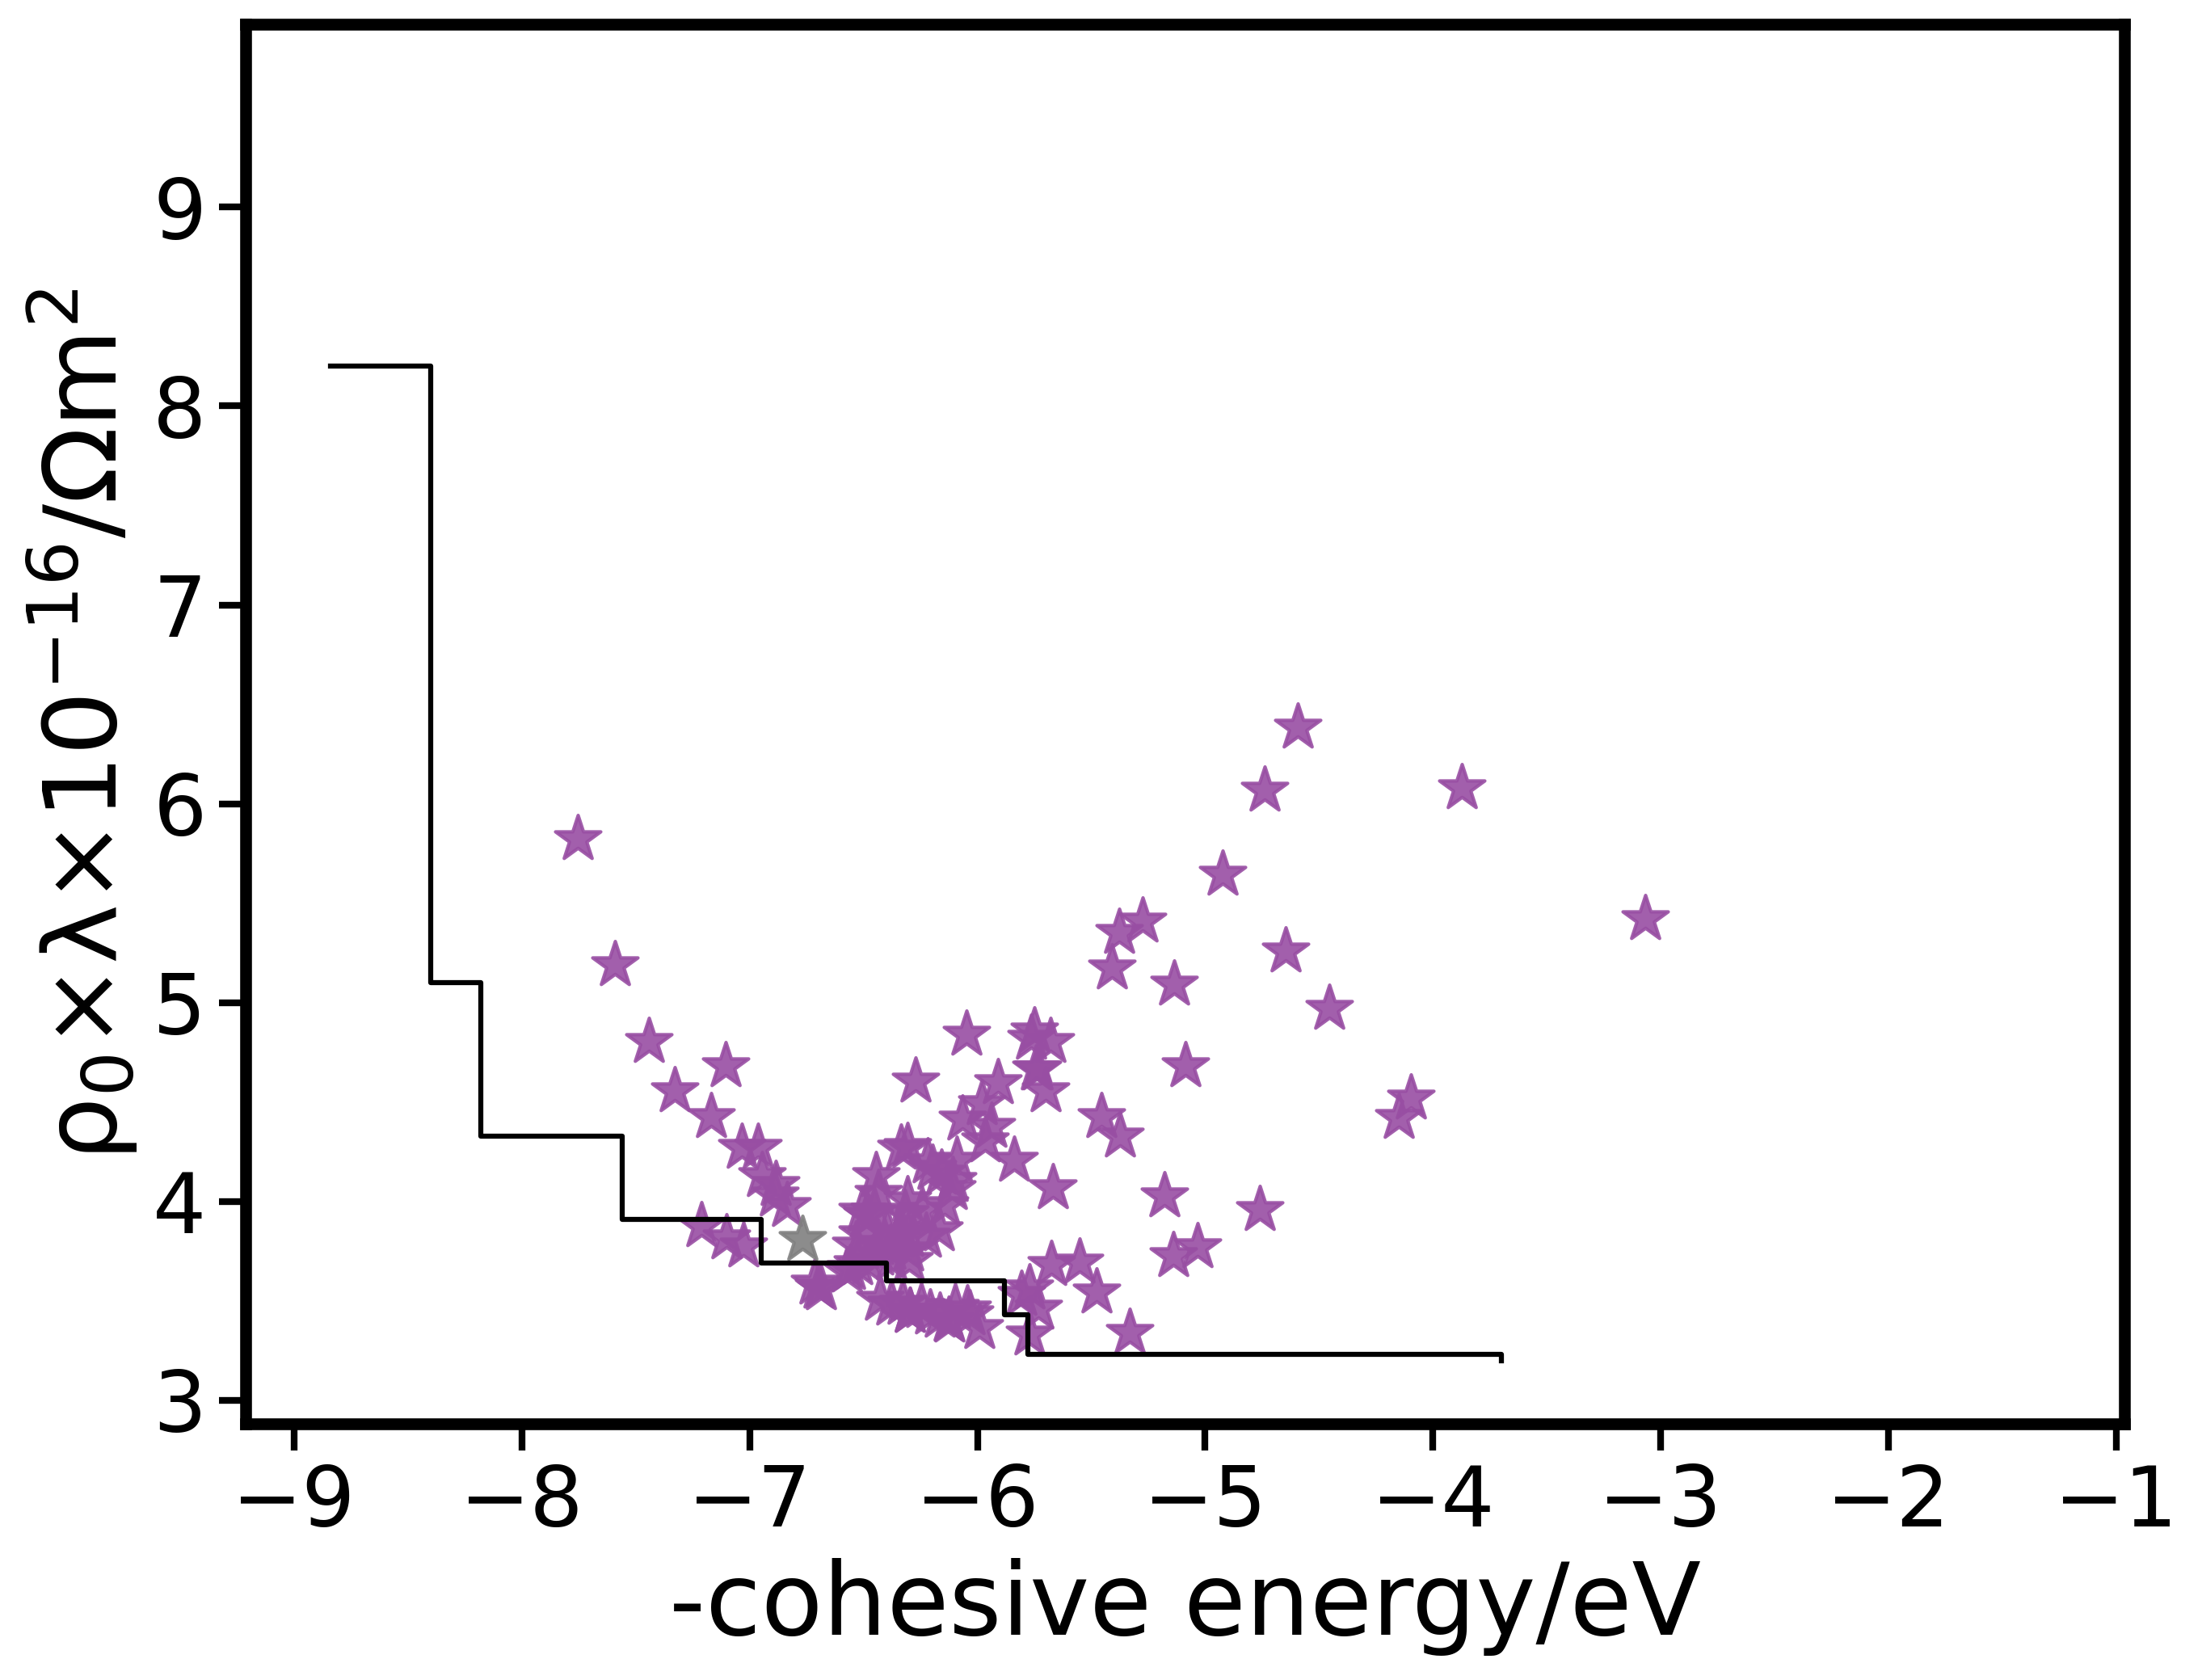

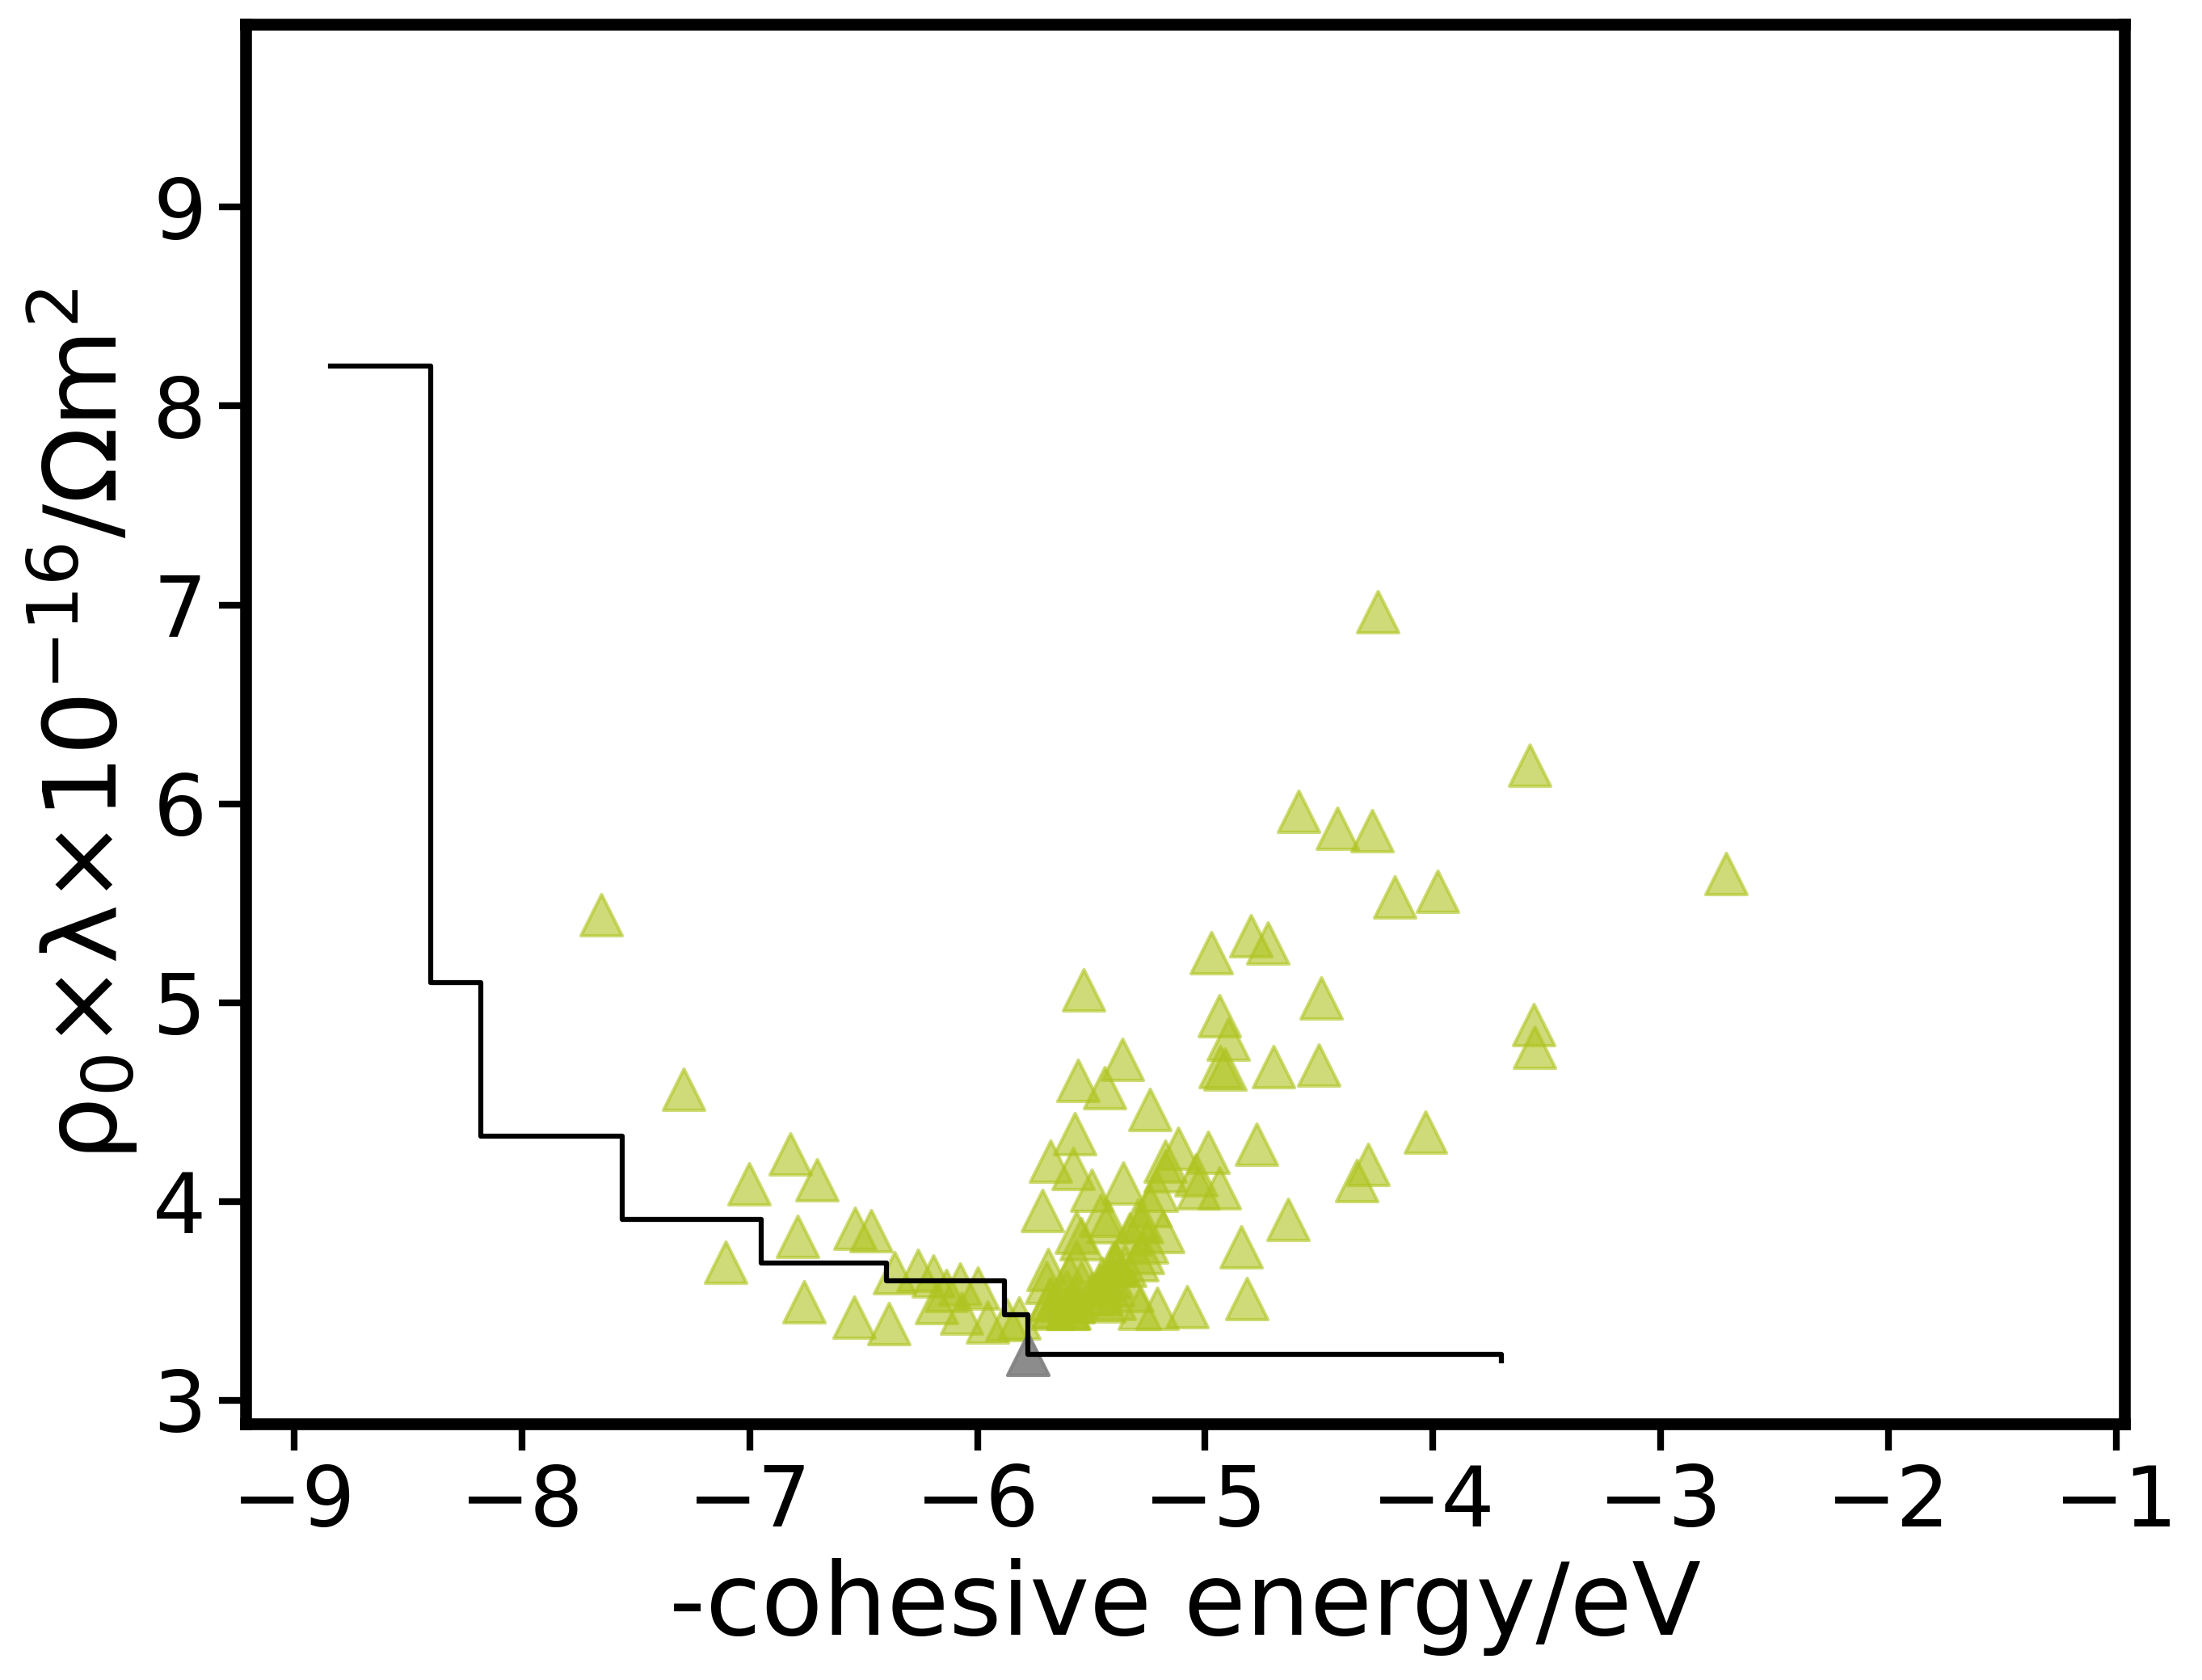

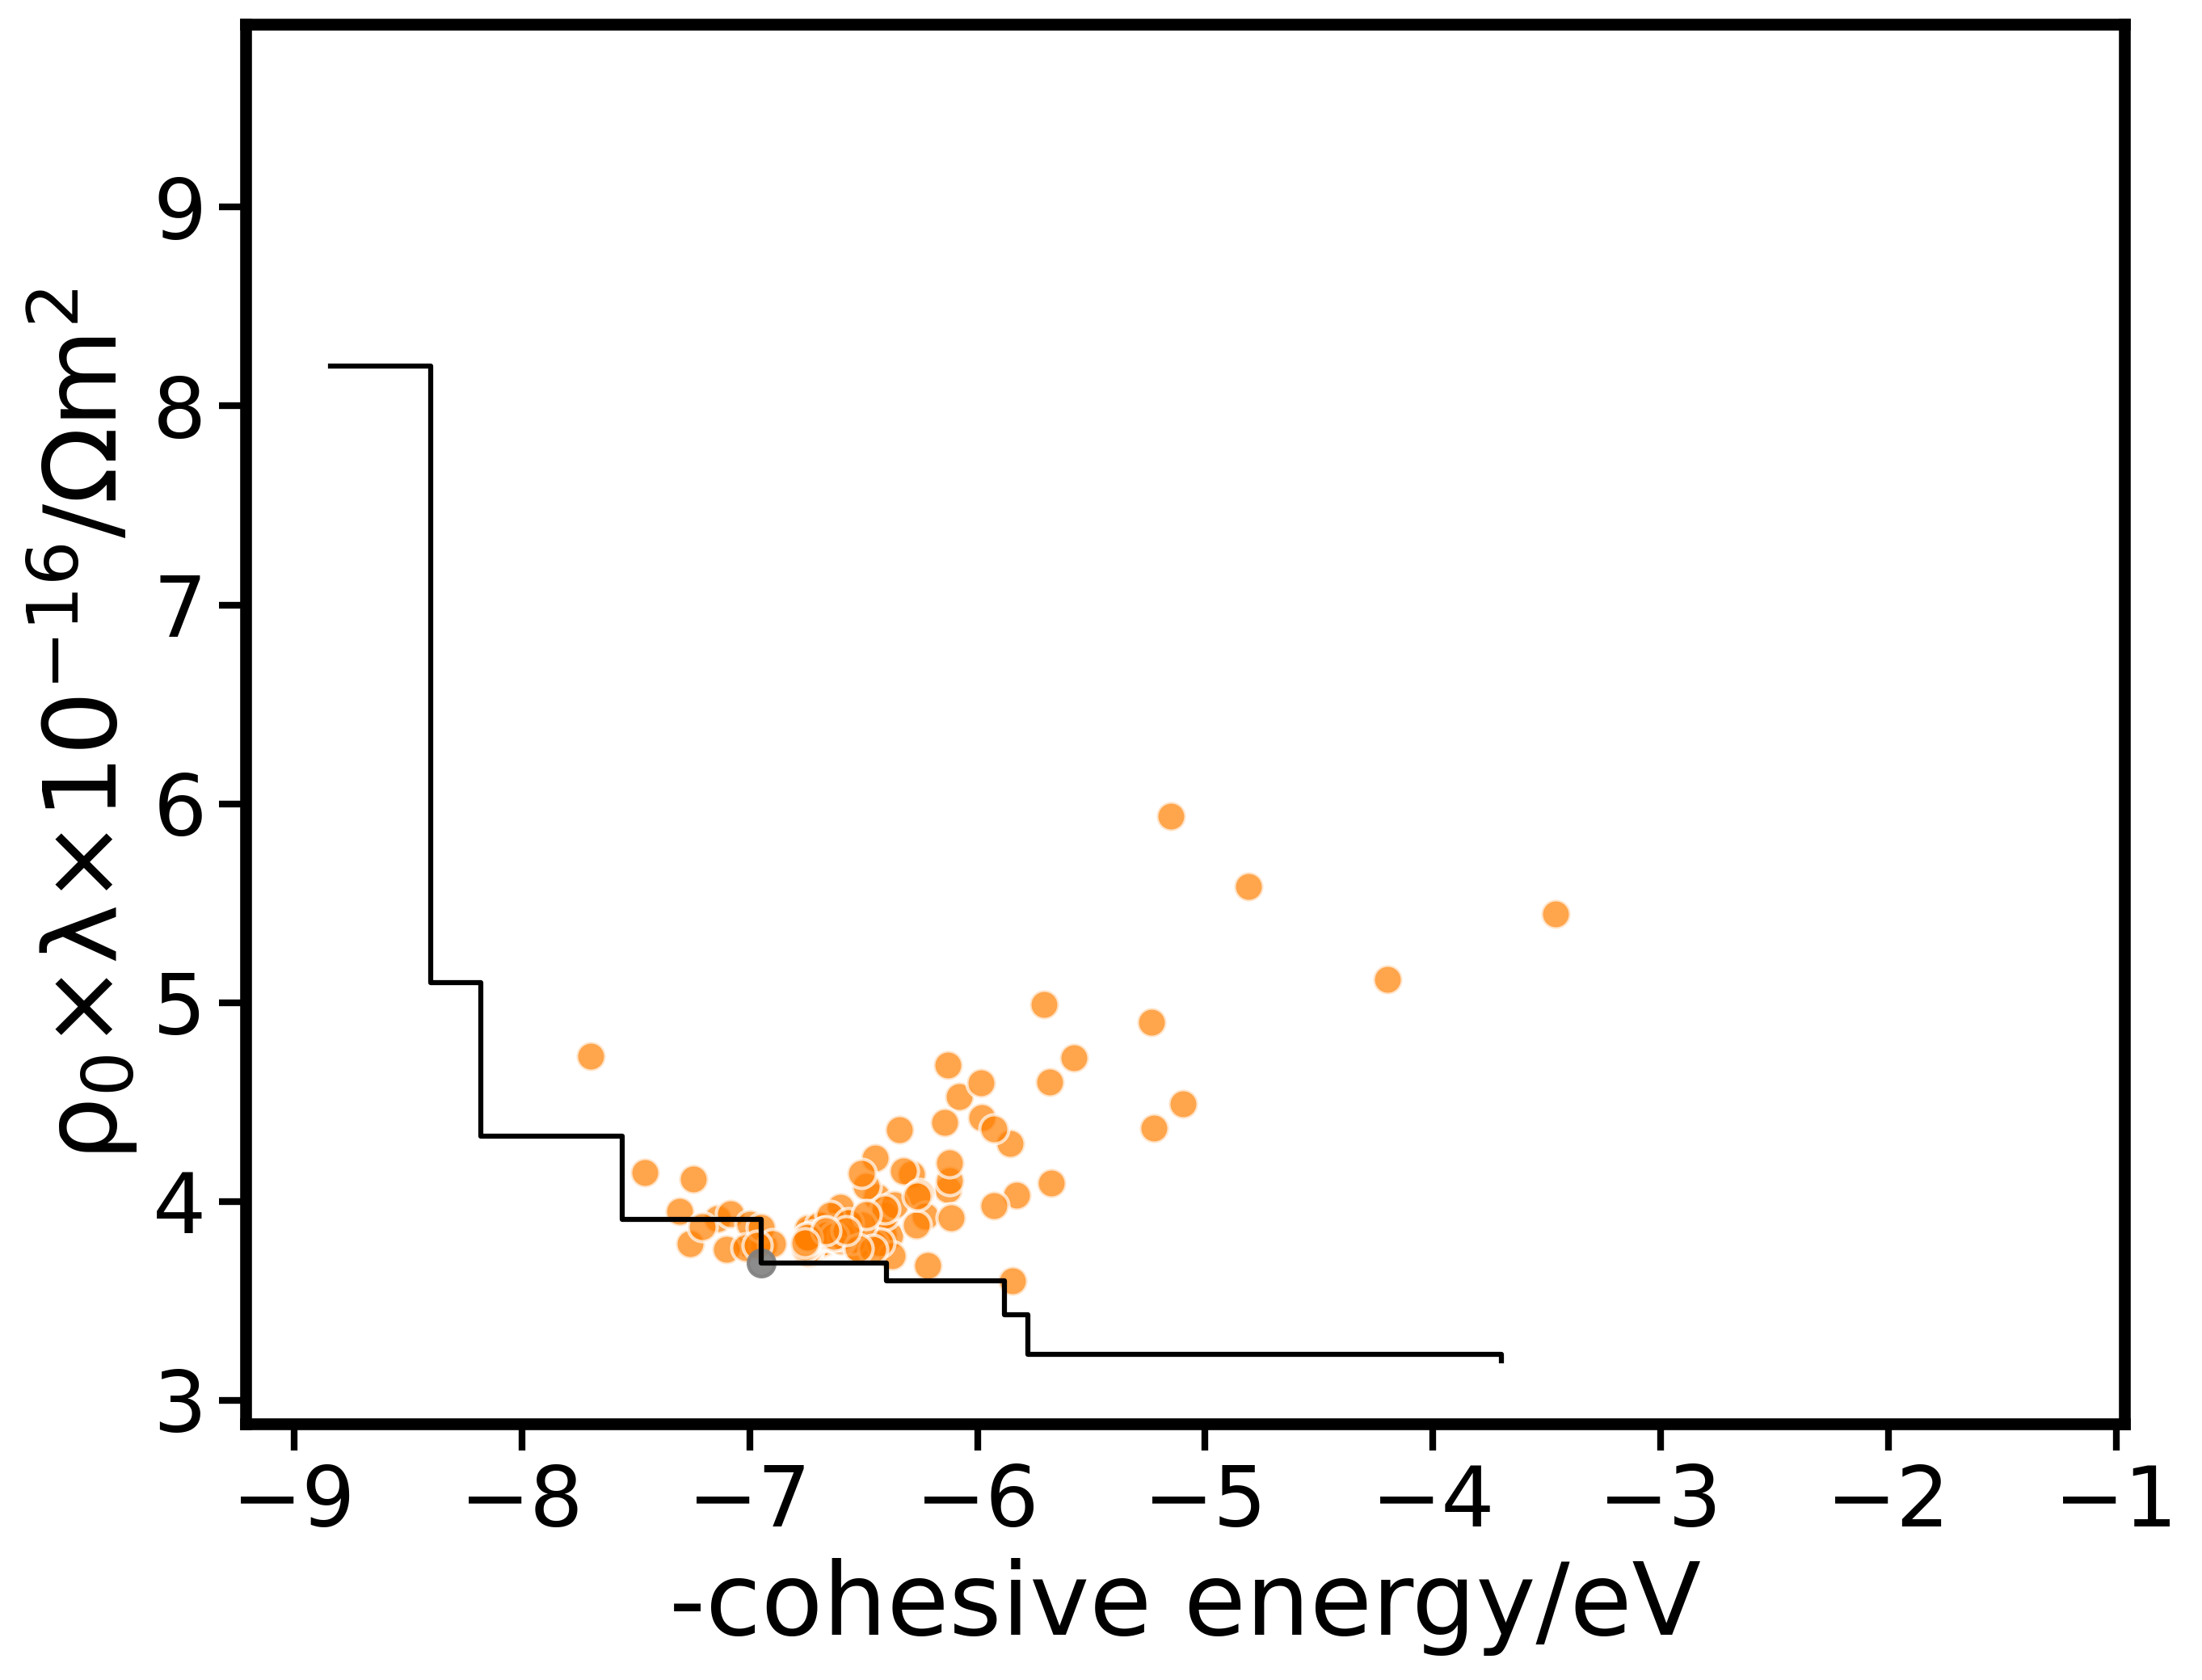

In [5]:
plt.figure(figsize=(10, 7.5),dpi= 300)
ax = plt.gca()

# 设置小图的坐标范围与大图相同
ax.set_xlim(-9.215, -0.9650000000000001)
ax.set_ylim(2.8800000000000003, 9.92)
ax.spines['bottom'].set_linewidth(3.5)
ax.spines['left'].set_linewidth(3.5)
ax.spines['top'].set_linewidth(3.5)
ax.spines['right'].set_linewidth(3.5)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.tick_params(axis='both', which='major', width=2)
plt.tick_params(axis='both', length=8)

plt.scatter(-X1, y1,s = 100,c='#E41A1C', marker='X', alpha=0.6)  # 绘制 Cu 预测数据点  3.0
plt.scatter(-3.44,6.7,s=100,c='#808080',marker='X',alpha=0.9)   # Cu
plt.scatter(-2.9,9.6,s=100,c='#808080',marker='X',alpha=0.9)  #Cu2Mg
plt.scatter(-4.6,6.8,s=100,c='#808080',marker='X',alpha=0.9)   # CuPt 
plt.scatter(-4.1,6,s=100,c='#808080',marker='X',alpha=0.9)     #AlCu
plt.scatter(-3.7,6,s=100,c='#808080',marker='X',alpha=0.9)     # t-Cu2Al3
plt.scatter(-3.7,3.8,s=100,c='#808080',marker='X',alpha=0.9)     #c-CuAl2
plt.scatter(-3.7,3.2,s=100,c='#808080',marker='X',alpha=0.9)     #c2-Cu3Al
plt.plot(y_front[:,0],y_front[:,1],c='k')

plt.xlabel('-cohesive energy/eV',fontsize=30)
plt.ylabel('ρ$_0$×λ×10$^{-16}$/Ωm$^2$',fontsize=30)
# plt.savefig('Cu-Double target forecasting-2.0.png', dpi=300, bbox_inches='tight')
plt.savefig('Cu-Double target forecasting-4.0.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 7.5),dpi= 300)
ax = plt.gca()
# 设置小图的坐标范围与大图相同
ax.set_xlim(-9.215, -0.9650000000000001)
ax.set_ylim(2.8800000000000003, 9.92)
ax.spines['bottom'].set_linewidth(3.5)
ax.spines['left'].set_linewidth(3.5)
ax.spines['top'].set_linewidth(3.5)
ax.spines['right'].set_linewidth(3.5)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.tick_params(axis='both', which='major', width=2)
plt.tick_params(axis='both', length=8)
plt.scatter(-X2, y2,s = 80,c='#0074D9', marker='s', alpha=0.8)  # 绘制 Co 预测数据点 3.0
plt.scatter(-4.37,4.82,s=80,c='#808080',marker='s',alpha=0.9)
plt.plot(y_front[:,0],y_front[:,1],c='k')

plt.xlabel('-cohesive energy/eV',fontsize=30)
plt.ylabel('ρ$_0$×λ×10$^{-16}$/Ωm$^2$',fontsize=30)
plt.savefig('Co-Double target forecasting-4.0.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 7.5),dpi= 300)
ax = plt.gca()
# 设置小图的坐标范围与大图相同
ax.set_xlim(-9.215, -0.9650000000000001)
ax.set_ylim(2.8800000000000003, 9.92)
ax.spines['bottom'].set_linewidth(3.5)
ax.spines['left'].set_linewidth(3.5)
ax.spines['top'].set_linewidth(3.5)
ax.spines['right'].set_linewidth(3.5)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.tick_params(axis='both', which='major', width=2)
plt.tick_params(axis='both', length=8)

plt.scatter(-X3, y3,s = 200,c='#984EA3', marker='*', alpha=0.9)  # 绘制 Ru 预测数据点 3.0

plt.scatter(-6.77,3.81,s=200,c='#808080',marker='*',alpha=0.9)
plt.plot(y_front[:,0],y_front[:,1],c='k')

plt.xlabel('-cohesive energy/eV',fontsize=30)
plt.ylabel('ρ$_0$×λ×10$^{-16}$/Ωm$^2$',fontsize=30)
plt.savefig('Ru-Double target forecasting-4.0.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 7.5),dpi= 300)
ax = plt.gca()
# 设置小图的坐标范围与大图相同
ax.set_xlim(-9.215, -0.9650000000000001)
ax.set_ylim(2.8800000000000003, 9.92)
ax.spines['bottom'].set_linewidth(3.5)
ax.spines['left'].set_linewidth(3.5)
ax.spines['top'].set_linewidth(3.5)
ax.spines['right'].set_linewidth(3.5)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.tick_params(axis='both', which='major', width=2)
plt.tick_params(axis='both', length=8)
plt.scatter(-X4, y4,s = 150,c='#AFC41F', marker='^', alpha=0.6)  # 绘制预 Rh测数据点  4DAF4A LVSE  3.0
plt.scatter(-5.78,3.23,s=150,c='#808080',marker='^',alpha=0.9)
plt.plot(y_front[:,0],y_front[:,1],c='k')
plt.xlabel('-cohesive energy/eV',fontsize=30)
plt.ylabel('ρ$_0$×λ×10$^{-16}$/Ωm$^2$',fontsize=30)
plt.savefig('Rh-Double target forecasting-4.0.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 7.5),dpi= 300)
ax = plt.gca()
# 设置小图的坐标范围与大图相同
ax.set_xlim(-9.215, -0.9650000000000001)
ax.set_ylim(2.8800000000000003, 9.92)
ax.spines['bottom'].set_linewidth(3.5)
ax.spines['left'].set_linewidth(3.5)
ax.spines['top'].set_linewidth(3.5)
ax.spines['right'].set_linewidth(3.5)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.tick_params(axis='both', which='major', width=2)
plt.tick_params(axis='both', length=8)
plt.scatter(-X5, y5,s = 300, marker='.', edgecolors='white', facecolors='#FF7F00',alpha=0.7)  #3.0
plt.scatter(-6.95,3.69,s=250,c='#808080',marker='.',alpha=0.9)
plt.plot(y_front[:,0],y_front[:,1],c='k')
plt.xlabel('-cohesive energy/eV',fontsize=30)
plt.ylabel('ρ$_0$×λ×10$^{-16}$/Ωm$^2$',fontsize=30)
plt.savefig('Ir-Double target forecasting-4.0.png', dpi=300, bbox_inches='tight')
plt.show()

# 缩小范围

In [19]:
# 筛选比较好的点的范围和标记坐标
selected_data_cu = pd.DataFrame({'X': X1, 'Y': y1})
selected_data_cu = selected_data_cu[(selected_data_cu['X']> 5) & (selected_data_cu['Y'] < 5)] #此处可以进行调整
print("selected data Cu:",selected_data_cu)
selected_data_co = pd.DataFrame({'X': X2, 'Y': y2})
selected_data_co = selected_data_co[(selected_data_co['X']> 5) & (selected_data_co['Y'] < 5)] #此处可以进行调整
print("selected data Co:",selected_data_co)
selected_data_ru = pd.DataFrame({'X': X3, 'Y': y3})
selected_data_ru = selected_data_ru[(selected_data_ru['X']> 5) & (selected_data_ru['Y'] < 5)] #此处可以进行调整
print("selected data Ru:",selected_data_ru)
selected_data_rh = pd.DataFrame({'X': X4, 'Y': y4})
selected_data_rh = selected_data_rh[(selected_data_rh['X']> 5) & (selected_data_rh['Y'] < 5)] #此处可以进行调整
print("selected data Rh:",selected_data_rh)
selected_data_ir = pd.DataFrame({'X': X5, 'Y': y5})
selected_data_ir = selected_data_ir[(selected_data_ir['X']> 5) & (selected_data_ir['Y'] < 5)] #此处可以进行调整
print("selected data Ir:",selected_data_rh)

selected data Cu:            X         Y
9   6.208431  4.609820
10  6.038290  3.689574
11  5.303651  4.013984
17  7.507365  4.641164
18  6.747445  3.404357
19  5.865355  4.342161
32  5.380296  4.911783
33  5.254190  4.082862
40  6.819299  3.514814
41  6.052082  3.673078
42  5.322373  4.941866
68  6.245344  3.363821
69  5.574324  4.140851
95  5.814790  3.590215
96  5.237125  4.552273
selected data Co:             X         Y
144  6.558011  4.569141
145  6.443291  4.272196
146  5.769217  3.558007
148  5.145512  3.688783
153  7.057720  3.559871
154  6.217287  3.770249
172  5.985407  4.679530
173  5.881354  4.029583
174  5.386913  3.794186
180  7.202210  4.450328
181  6.579807  3.427903
182  5.864810  3.839492
201  5.638336  4.659003
202  5.556906  4.040000
203  5.175056  3.960505
209  6.806607  3.974913
210  6.231199  3.482965
211  5.624120  3.930662
230  5.415924  4.623753
231  5.350530  4.089348
232  5.041010  4.072400
238  6.488438  3.780311
239  5.974371  3.583342
240  5.451614  4.009

# 配色标记图

# 全部特征

(-9.215, -0.9650000000000001)
(1.305, 9.995)


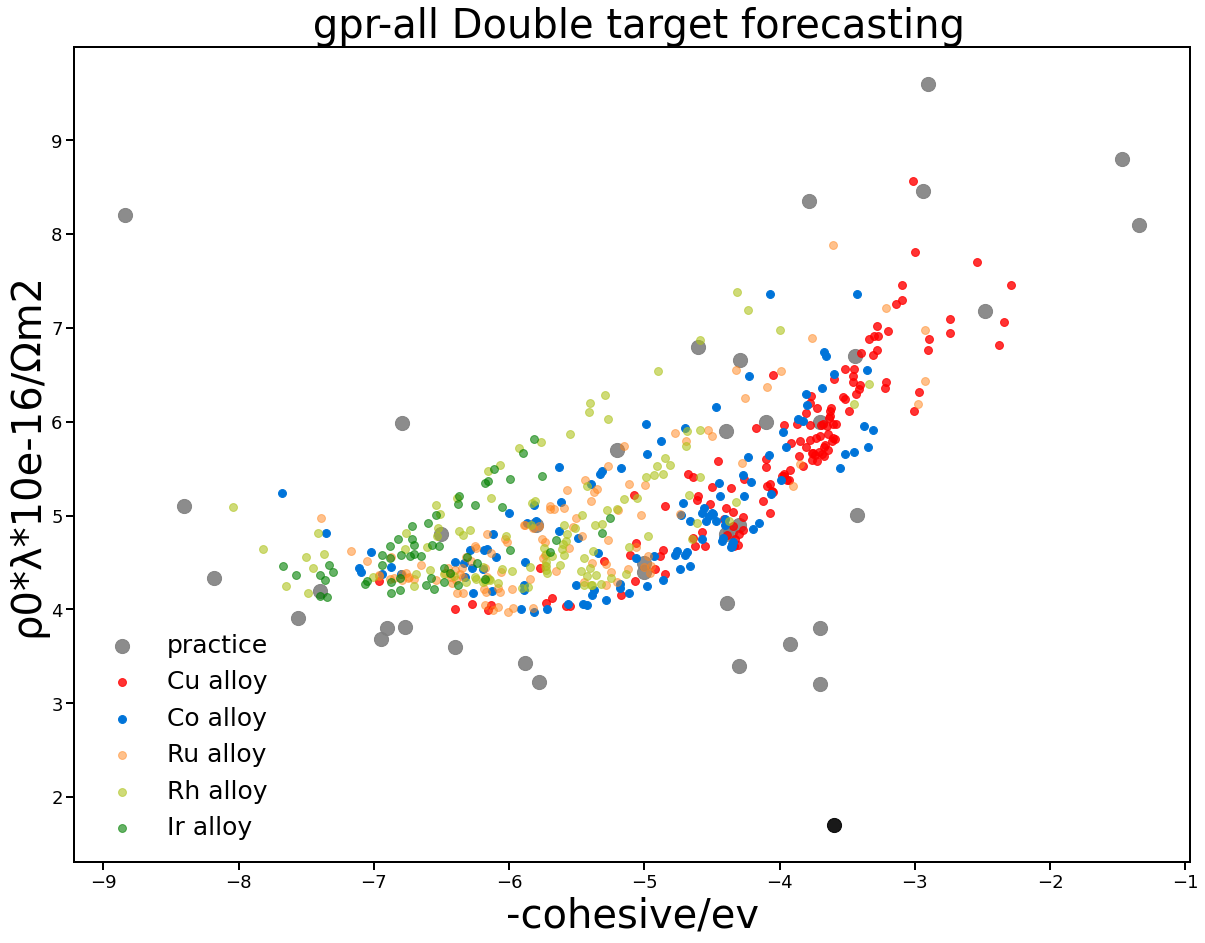

Cu的理想数据：
152    6.959020
153    6.397949
144    6.270644
180    6.154702
145    6.133343
154    5.774283
181    5.724659
172    5.683294
Name: Prediction1.1, dtype: float64
180    3.991945
153    4.007873
173    4.031705
146    4.037967
145    4.047957
144    4.059488
Name: Prediction3, dtype: float64
264    7.679812
291    7.350813
257    7.107812
292    7.097413
258    7.021920
284    6.939655
Name: Prediction1.1, dtype: float64
281    3.969115
209    3.999422
280    4.006462
Name: Prediction3, dtype: float64
375    7.390082
320    7.165234
349    7.048279
Name: Prediction1.1, dtype: float64
310    3.976742
339    3.996661
340    4.010394
Name: Prediction3, dtype: float64
487    8.041766
516    7.816963
488    7.646399
Name: Prediction1.1, dtype: float64
517    4.172827
427    4.227004
456    4.236998
Name: Prediction3, dtype: float64


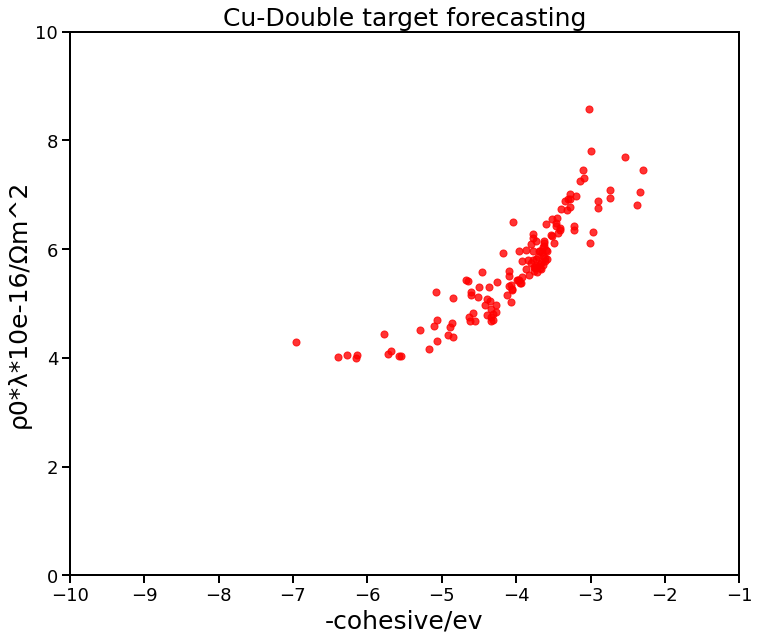

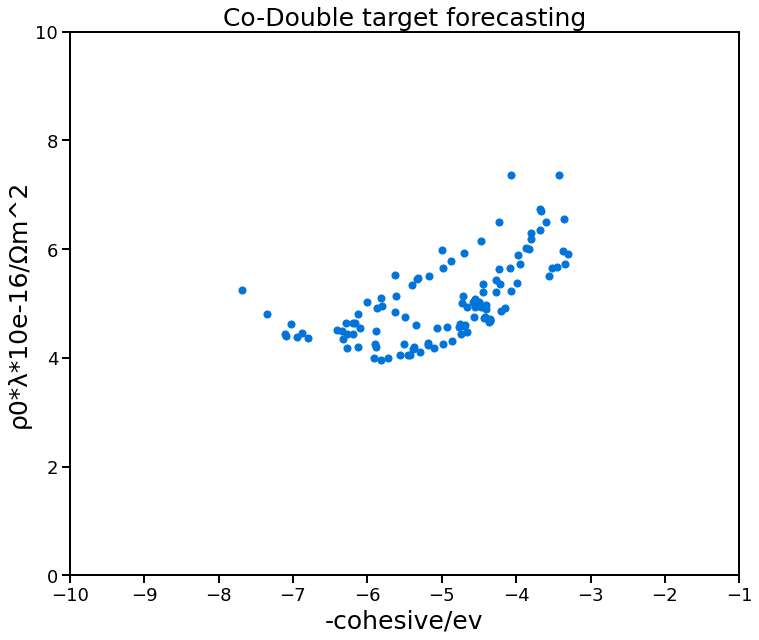

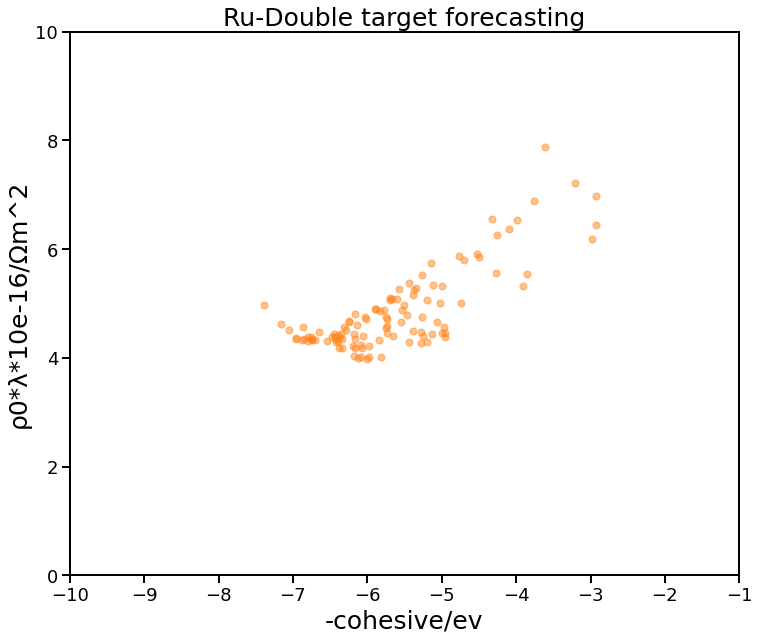

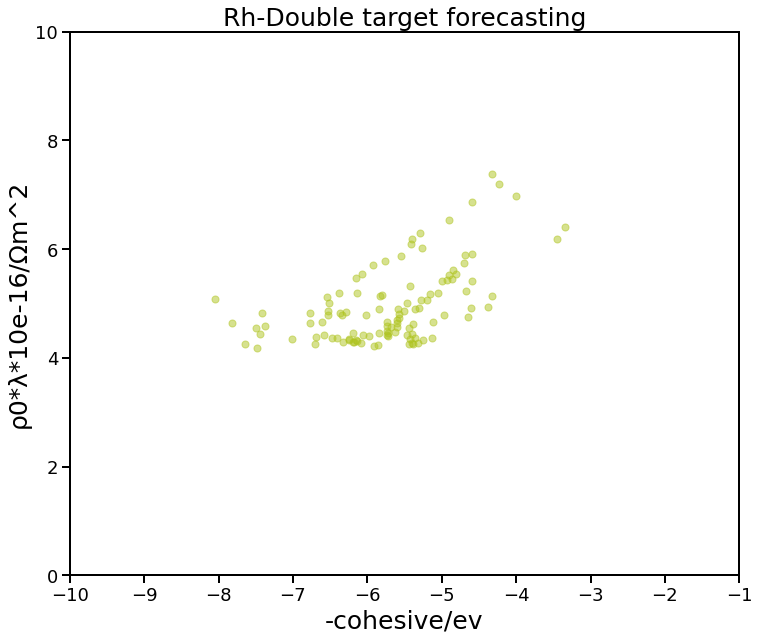

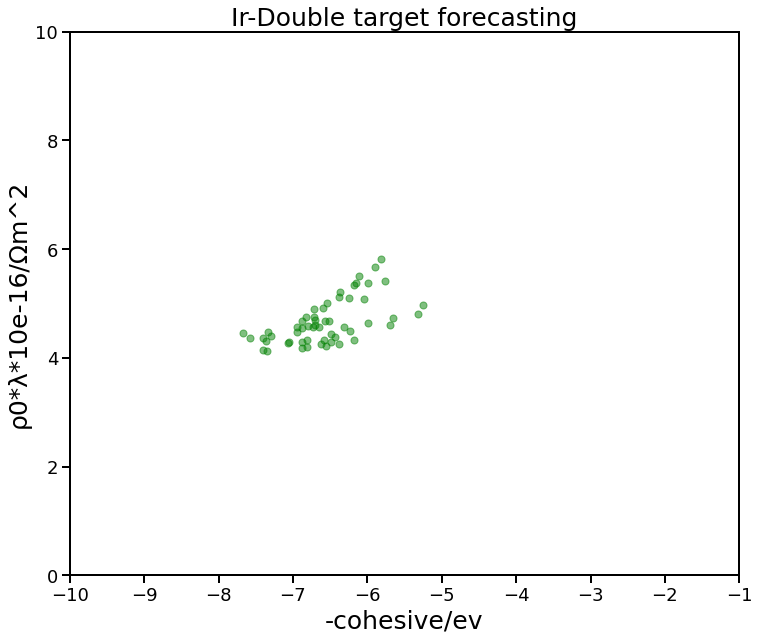

In [13]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RepeatedKFold
from sklearn.feature_selection import SelectKBest
from matplotlib.backend_bases import MouseButton
from scipy.stats import pearsonr
from modules import *
from sklearn.svm import SVR
import pandas as pd
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import modules
from matplotlib.ticker import MultipleLocator

File = '../data.3/em2.0'
X,y= sub_data(File)
# X=X[:48,:]
# y=y[:48]
X=X[:38,:]
y=y[:38]
y=y.reshape(-1, 1)   # 将 y 的一维数组转换成2维数组
X=np.delete(X,[0,1,2,3,4,5,6],axis= 1)
x_values=X.copy()
y_values=y.copy()

df3 = pd.read_csv('pSVR-3.csv')
x_values2 = pd.read_csv('pSVR-3.csv').iloc[:, 0] 

# df4 = pd.read_csv('gpr_fps.csv')  
# y_values2 = pd.read_csv('gpr_fps.csv').iloc[:, 0]
df4 = pd.read_csv('gpr-all.csv')          #  gbr  rfr-all  svr-all   krr-all
y_values2 = pd.read_csv('gpr-all.csv').iloc[:, 0]        #  gbr  rfr-all  svr-all    krr-all




# 这一块是验证集，也就是大于10的数据，和1.7的那个数据集,预测出来的效果不好
# X6=df3.iloc[38:47]
# y6=df4.iloc[38:47]

X1=df3.iloc[54:190]
X2=df3.iloc[190:304]
X3=df3.iloc[304:415]
X4=df3.iloc[415:527]
X5=df3.iloc[527:]
y1=df4.iloc[54:190]
y2=df4.iloc[190:304]
y3=df4.iloc[304:415]
y4=df4.iloc[415:527]
y5=df4.iloc[527:]


# # # 区分每一类中的最优点
# 在每一类中找到内聚能最大的3个点

largest_1 = X1.iloc[:, 0].nlargest(8)
largest_2 = X2.iloc[:, 0].nlargest(6)
largest_3 = X3.iloc[:, 0].nlargest(3)
largest_4 = X4.iloc[:, 0].nlargest(3)
# # 区分每一类中的最优点
# 在每一类中找到电阻最小的3个点
smallest_1 = y1.iloc[:, 0].nsmallest(6)
smallest_2 = y2.iloc[:, 0].nsmallest(3)
smallest_3 = y3.iloc[:, 0].nsmallest(3)
smallest_4 = y4.iloc[:, 0].nsmallest(3)


plt.figure(figsize=(20,15))
ax=plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tick_params(axis='both', which='major', width=2)
plt.tick_params(axis='both', length=8)
plt.scatter(-x_values, y_values,s = 200,c='#808080', alpha=0.9)  # 绘制实验数据点

# plt.scatter(-X6, y6,s = 200,c='blue', alpha=0.8)
plt.scatter(-X1, y1,s = 250,c='r', marker='.', alpha=0.8)  # 绘制 Cu 预测数据点
plt.scatter(-X2, y2,s = 250,c='#0074D9', marker='.', alpha=1.0)  # 绘制 Co 预测数据点
plt.scatter(-X3, y3,s = 250,c='#FF851B', marker='.', alpha=0.5)  # 绘制 Ru 预测数据点
plt.scatter(-X4, y4,s = 250,c='#AFC41F', marker='.', alpha=0.6)  # 绘制预 Rh测数据点
plt.scatter(-X5, y5,s = 250,c='green', marker='.', alpha=0.6)    # 绘制预 IR测数据点
plt.scatter(-3.6, 1.7,s = 200,c='black', alpha=0.9)  # 绘制实验数据点

ax = plt.gca()  # 获取当前轴对象
print(ax.get_xlim())  # 获取x轴范围
print(ax.get_ylim())  # 获取y轴范围



# 设置图表标题和坐标轴标签
plt.title(' gpr-all Double target forecasting',fontsize=40)
plt.xlabel('-cohesive/eV',fontsize=40)
plt.ylabel('ρ0*λ*10e-16/Ωm2',fontsize=40)
plt.legend(['practice','Cu alloy','Co alloy','Ru alloy','Rh alloy ','Ir alloy'],loc=0,fontsize=25,frameon=False)
# 显示图表
plt.show()

# # 打印1/4区域的数据点
# print("理想的数据点:")
# print(selected_data)
print("Cu的理想数据：")
print(largest_1)
print (smallest_1)
print(largest_2)
print(smallest_2)
print(largest_3)
print(smallest_3)
print(largest_4)
print(smallest_4)


import matplotlib.pyplot as plt

def plot_scatter1(x, y, title='Cu-Double target forecasting', color='r', xlabel='-cohesive/eV', ylabel='ρ0*λ*10e-16/Ωm^2', alpha='0.3',xlim=None, ylim=None):
    plt.figure(figsize=(12, 10))
    ax = plt.gca()
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['top'].set_linewidth(2)
    ax.spines['right'].set_linewidth(2)

    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.tick_params(axis='both', which='major', width=2)
    plt.tick_params(axis='both', length=8)

    plt.title(title, fontsize=25)
    plt.xlabel(xlabel, fontsize=25)
    plt.ylabel(ylabel, fontsize=25)

    plt.scatter(x, y, s=200, c=color, marker='.', alpha=alpha)

    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)

    plt.show()


plot_scatter1(-X1, y1,title='Cu-Double target forecasting', color='r',  alpha=0.8,xlim=(-10,-1),ylim=(0,10))  # 绘制 Cu 预测数据点
plt.show()


plot_scatter1(-X2, y2,title='Co-Double target forecasting',color='#0074D9',  alpha=1.0,xlim=(-10,-1),ylim=(0,10))  # 绘制 Co 预测数据点
plt.show()

plot_scatter1(-X3, y3,title= 'Ru-Double target forecasting',color='#FF851B',  alpha=0.5,xlim=(-10,-1),ylim=(0,10))  # 绘制 Ru 预测数据点
plt.show()

plot_scatter1(-X4, y4,title='Rh-Double target forecasting' ,color='#AFC41F',  alpha=0.5,xlim=(-10,-1),ylim=(0,10))  # 绘制预 Ir 测数据点
plt.show()
plot_scatter1(-X5, y5,title='Ir-Double target forecasting' ,color='green',  alpha=0.5,xlim=(-10,-1),ylim=(0,10))  # 绘制预 Ir 测数据点
plt.show()
